In [1]:
#for importing, formatting and data manipulation
import pandas as pd
import numpy as np
import glob
import datetime
#from time import time
#from datetime import datetime
#from datetime import timedelta
import tempfile
from qiime2 import Artifact
import zipfile
import yaml

#for plotting
import matplotlib.pyplot as plt
import seaborn as sns
#sns.set(style="whitegrid")
import plotly.express as px
%matplotlib inline
from IPython.display import display
from upsetplot import plot
#import pyupset as pyu
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
from pandas.plotting import register_matplotlib_converters
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
register_matplotlib_converters()

#for statistical analyses
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from skbio.diversity import alpha_diversity
from skbio.stats.distance import permanova
from skbio import DistanceMatrix
from scipy.spatial.distance import cdist
from skbio.stats.composition import clr
from skbio.stats.composition import alr
from skbio.stats.composition import ilr
from skbio.diversity.alpha import chao1

## Import and format metadata from lab, and BBMP

### Import lab metadata

In [2]:
def load_df():
    
    filenames = glob.glob('/Users/Diana/Documents/escuela/phd/ch2/bb_data/20**/METADATA.txt')
    #load all metadata and concatenate them into one dataframe
    md = []
    for filename in filenames:
        df = pd.read_csv(filename, sep='\t')
        md.append(df)
        print (filename)
    
    md = pd.concat(md)
    
    #drop empty columns and rows
    md.dropna(how='all', axis=1, inplace=True) #empty cols
    md.dropna(how='all', inplace=True) #empty rows
    
    return md

In [3]:
md = load_df()

/Users/Diana/Documents/escuela/phd/ch2/bb_data/2014/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2022/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2015/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2017/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2019/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2021/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2020/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2018/METADATA.txt
/Users/Diana/Documents/escuela/phd/ch2/bb_data/2016/METADATA.txt


In [66]:
#typo in names
md.replace({'BB18. 50AL': 'BB18.50AL',
            'BB18..16CL': 'BB18.16CL',
           'BB18.13.BS': 'BB18.13BS',
           'BB18.13.CL': 'BB18.13CL',
           'BB18.13CDS': 'BB18.13DS'}, inplace=True)

#### Renumber dates

In [4]:
#create a dictionary for months
month_dic = {
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "Jun": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
}
month_season = {
    "Jan": "Winter",
    "Feb": "Winter",
    "Mar": "Spring",
    "Apr": "Spring",
    "May": "Spring",
    "Jun": "Summer",
    "Jul": "Summer",
    "Aug": "Summer",
    "Sep": "Autumn",
    "Oct": "Autumn",
    "Nov": "Autumn",
    "Dec": "Winter"
}

In [5]:
#add month to a new column
md['month_name'] = md['date'].str.split('-').str[1]

#add month number
md['month']= md['month_name'].map(month_dic)

#add day number
md['day'] = md['date'].str.split('-').str[0]
md[["year", "month", "day"]] = md[["year", "month", "day"]].apply(pd.to_numeric)

#remove symbol for better handling of data
#md.rename(columns={"Week#": "Weekn"}, inplace=True)
#md.rename(columns={"Depth": "depth"}, inplace=True) #to match dfo

#change to int to remove decimals from date columns
md.year = md.year.apply(int)
md.depth = md.depth.apply(int)
md.weekn = md.weekn.apply(int)

#change to str to aggregate them into time_string to match dfos formatting of the date
md.year = md.year.apply(str)
md.month = md.month.apply(str)
md.day = md.day.apply(str)
#add leading zero to match date format in dfo metadata
md['month'] = md['month'].str.zfill(2)
md['day'] = md['day'].str.zfill(2)

#add leading zero to match date format in dfo metadata
md['month'] = md['month'].str.zfill(2)
md['day'] = md['day'].str.zfill(2)

md['time_string'] = md[['year', 'month', 'day']].agg('-'.join, axis=1)

In [69]:
md

,sampleid,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elution_volume,nifH,MetaG,new_id,notes,size_code,Tube Label BBYear.WeekDepthSize,filtration_volume,Notes,Unnamed: 15,16S V6V8\nIMR #,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,IMR # - V4V5,IMR # - 18S,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,Freezer Box (1.5mL),sample_code,month_name,month,day,time_string
0,BB14.3A,2014,15-Jan,3,1,A,01.15.1m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.3A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,01,15,2014-01-15
1,BB14.3B,2014,15-Jan,3,5,B,01.15.5m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.3B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,01,15,2014-01-15
2,BB14.3C,2014,15-Jan,3,10,C,01.15.10m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.3C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,01,15,2014-01-15
3,BB14.3D,2014,15-Jan,3,60,D,01.15.60m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.3D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,01,15,2014-01-15
4,BB14.4A,2014,23-Jan,4,1,A,01.23.1m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.4A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,01,23,2014-01-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,BB16.50D,2016,14-Dec,50,60,D,NaN,11.6,1.60,2017-01-23,CW,NaN,NaN,NaN,+,NaN,BB16.50D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB16.50D,Dec,12,14,2016-12-14
200,BB16.51A,2016,21-Dec,51,1,A,NaN,14.3,1.76,2017-01-23,CW,NaN,NaN,NaN,+,NaN,BB16.51A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB16.51A,Dec,12,21,2016-12-21
201,BB16.51B,2016,21-Dec,51,5,B,NaN,11.2,1.70,2017-01-23,CW,NaN,NaN,NaN,+,NaN,BB16.51B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB16.51B,Dec,12,21,2016-12-21
202,BB16.51C,2016,21-Dec,51,10,C,NaN,28.8,1.56,2017-03-06,CW,NaN,NaN,NaN,+,NaN,BB16.51C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB16.51C,Dec,12,21,2016-12-21


### Import and manage BBMP data

#### Metadata __md__ is formatted. It contains 38 columns.
__md__ is the lab's metadata for sampling, extraction and sequencing. \
__dfo_md__ is BBMP remote sensing data (salinity, pH, temperature, density..) \
__bio_niskin__ is nutrient data \
Format __bio_niskin__ data to merge with __md__. __bio_niskin__ is 32 columns, including year, month, day, and depth. __dfo_md__ also has 32 columns, including year_time, month_time, day_time. To merge these data with __md__, we will change the time stamps columns to the same name, and generate a time_string column.

In [6]:
dfo_md = pd.read_csv("/Users/Diana/Documents/escuela/phd/ch2/bb_data/bbmp_aggregated_profiles.csv")

In [7]:
#renaming columns to ensure correct merging
dfo_md.rename(columns={"depth":"bbmpdepth","pressure": "depth", 
                       "year_time": "year", "month_time": "month", 
                       "day_time": "day"}, inplace=True)

In [8]:
#make a new column for time_string without the time
dfo_md['time_string_time'] = dfo_md['time_string']
dfo_md['time_string'] = dfo_md['time_string'].str.split(' ').str[0]

In [9]:
#change to int to remove decimals from date columns
cols = ['year', 'depth', 'month', 'day']
md[cols] = md[cols].apply(pd.to_numeric, errors='ignore', axis=1)
dfo_md[cols] = dfo_md[cols].apply(pd.to_numeric, errors='ignore', axis=1)

In [10]:
#merging party
merged = pd.merge(md, dfo_md, on=["year", "month", "depth", "day"], how="left")

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/2939163124.py:2: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  merged = pd.merge(md, dfo_md, on=["year", "month", "depth", "day"], how="left")


In [11]:
md.loc[md['sampleid'] == "BB14.16A"]

,sampleid,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elution_volume,nifH,MetaG,new_id,notes,size_code,Tube Label BBYear.WeekDepthSize,filtration_volume,Notes,Unnamed: 15,16S V6V8\nIMR #,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,IMR # - V4V5,IMR # - 18S,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,Freezer Box (1.5mL),sample_code,month_name,month,day,time_string
52,BB14.16A,2014,16-Apr,16,1,A,04.16.1m,40.5,1.94,May 22 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.16A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Apr,4,16,2014-04-16


In [87]:
dfo_md.loc[dfo_md['time_string'] == '2014-04-16']

,time_string,year,month,day,julian_day,scan,depth,temperature,conductivity,oxygenVoltage,fluorescence,unknown,pH,PSAR,salinity,theta,sigmaTheta,oxygen,scan2,fluorescence2,turbidity,oxygenCurrent,oxygenTemperature,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,bbmpdepth,fluorometer,par,flagArchaic,time_string_time
113074,2014-04-16,2014.0,4.0,16.0,106,1309.0,1.5,4.0493,0.634493,2.8173,8.3566,3.446697,NaN,74.71400,28.6891,NaN,22.7656,7.65449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22
113075,2014-04-16,2014.0,4.0,16.0,106,2075.0,2.0,4.0072,0.634527,2.8169,8.9445,3.242145,NaN,55.65400,28.7274,NaN,22.7998,7.66011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22
113076,2014-04-16,2014.0,4.0,16.0,106,2064.0,2.5,4.0079,0.634487,2.8166,9.0893,3.986297,NaN,43.02000,28.7245,NaN,22.7974,7.64168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22
113077,2014-04-16,2014.0,4.0,16.0,106,2069.0,3.0,4.0092,0.634505,2.8141,9.1860,3.599746,NaN,34.77700,28.7241,NaN,22.7970,7.61382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22
113078,2014-04-16,2014.0,4.0,16.0,106,2075.0,3.5,4.0080,0.634501,2.8106,9.1024,2.526252,NaN,31.40100,28.7247,NaN,22.7976,7.59232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113182,2014-04-16,2014.0,4.0,16.0,106,2861.0,55.5,1.5820,0.635818,2.2552,1.6559,1.837203,NaN,0.00211,31.0238,NaN,24.8149,6.11171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22
113183,2014-04-16,2014.0,4.0,16.0,106,2868.0,56.0,1.5833,0.635863,2.2539,1.6562,2.180786,NaN,0.00210,31.0247,NaN,24.8155,6.09767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22
113184,2014-04-16,2014.0,4.0,16.0,106,2874.0,56.5,1.5867,0.635982,2.2510,1.6463,2.568114,NaN,0.00210,31.0274,NaN,24.8175,6.07987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22
113185,2014-04-16,2014.0,4.0,16.0,106,2883.0,57.0,1.5879,0.636050,2.2481,1.6408,2.277075,NaN,0.00207,31.0296,NaN,24.8192,6.08233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-04-16 11:54:22


In [12]:
listindex = merged[merged['temperature'].isnull()].index.tolist()
new = merged["sampleid"].iloc[listindex].to_list()
new

['BB14.16A',
 'BB14.16D',
 'BB14.51A',
 'BB22.5A',
 'BB22.11A',
 'BB22.11B',
 'BB22.11C',
 'BB22.11E',
 'BB22.11D',
 'BB22.23A',
 'BB22.23B',
 'BB22.23C',
 'BB22.23E',
 'BB22.23D',
 'BB22.38A',
 'BB22.38B',
 'BB22.38C',
 'BB22.38E',
 'BB22.38D',
 'BB22.39A',
 'BB22.39B',
 'BB22.39C',
 'BB22.39E',
 'BB22.39D',
 'BB22.43A',
 'BB22.43B',
 'BB22.43C',
 'BB22.43E',
 'BB22.43D',
 'BB22.44A',
 'BB22.49A',
 'BB22.49B',
 'BB22.49C',
 'BB22.49E',
 'BB22.49D',
 'BB15.8A',
 'BB15.8B',
 'BB15.8C',
 'BB15.8D',
 'BB15.12A',
 'BB15.12B',
 'BB15.12C',
 'BB15.12D',
 'BB15.13A',
 'BB15.14A',
 'BB15.15A',
 'BB15.17A',
 'BB15.17B',
 'BB15.17C',
 'BB15.17D',
 'BB15.24A',
 'BB15.38A',
 'BB15.38B',
 'BB15.38C',
 'BB15.38D',
 'BB15.42A',
 'BB15.42B',
 'BB15.42C',
 'BB15.42D',
 'BB15.44A',
 'BB15.44B',
 'BB15.44C',
 'BB15.44D',
 'BB17_14A',
 'BB17_14B',
 'BB17_14C',
 'BB17_14D',
 'BB19.8DL',
 'BB19.8DS',
 'BB19.21AL',
 'BB19.21AS',
 'BB19.21BL',
 'BB19.21BS',
 'BB19.21CL',
 'BB19.21CS',
 'BB19.21DL',
 'BB19.21D

In [13]:
dfo_md = pd.read_csv("/Users/Diana/Documents/escuela/phd/ch2/bb_data/bbmp_aggregated_profiles.csv")
bio_niskin = pd.read_csv("/Users/Diana/Documents/escuela/phd/ch2/bb_data/BBMP_Data_2022.csv")#
#dfo_metadata_y14 = pd.read_csv("/Users/Diana/Documents/escuela/phd/bb_data/2019/data_export/trim-analysis/dfo_metadata_y14.tsv", sep='\t')

#change to str to aggregate them into time_string
bio_niskin.year = bio_niskin.year.apply(str)
bio_niskin.month = bio_niskin.month.apply(str)
bio_niskin.day = bio_niskin.day.apply(str)

#add leading zero to match date format in dfo metadata
bio_niskin['month'] = bio_niskin['month'].str.zfill(2)
bio_niskin['day'] = bio_niskin['day'].str.zfill(2)

bio_niskin['time_string'] = bio_niskin[['year', 'month', 'day']].agg('-'.join, axis=1)

#make a new column for time_string without the time
dfo_md['time_string_time'] = dfo_md['time_string']
dfo_md['time_string'] = dfo_md['time_string'].str.split(' ').str[0]

#renaming columns to ensure correct merging
dfo_md.rename(columns={"depth":"bbmpdepth","pressure": "depth", "year_time": "year", "month_time": "month", "day_time": "day"}, inplace=True)

#change to int to remove decimals from date columns
cols = ['year', 'depth', 'month', 'day']
md[cols] = md[cols].apply(pd.to_numeric, errors='ignore', axis=1)
dfo_md[cols] = dfo_md[cols].apply(pd.to_numeric, errors='ignore', axis=1)
bio_niskin[cols] = bio_niskin[cols].apply(pd.to_numeric, errors='ignore', axis=1)

#make a season column
md['season'] = ''

for month, season in month_season.items():
    md.loc[md['month_name'] == month, 'season'] = season

#merging party
merged = pd.merge(md, dfo_md, on=["year", "month", "depth", "day"], how="left")
allyears = pd.merge(md, dfo_md, on=["year", "month", "depth", "day"], how="outer")

#add nutrient data
preall_md= pd.merge(allyears, bio_niskin, on=["day", "month", "year", 'depth'], how="outer")
all_md = pd.merge(merged, bio_niskin, on=["day", "month", "year", 'depth'], how="left")

#split dfs by depth
shallow_depths = [1, 5, 10]
shallow = all_md[all_md["depth"] < 30]
#shallow = shallow.groupby(['year', 'month', "day"]).mean().reset_index()
deep = all_md[all_md.depth == 60]

#split dfs by season
year_season = preall_md.groupby(by = ['year','season']).mean().reset_index()

Winter = year_season.loc[year_season['season'] == 'Winter',:]
Spring = year_season.loc[year_season['season'] == 'Spring',:]
Summer = year_season.loc[year_season['season'] == 'Summer',:]
Autumn = year_season.loc[year_season['season'] == 'Autumn',:]

#save output as csv
all_md.to_csv('allmetadata.csv')

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/1275109402.py:36: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  merged = pd.merge(md, dfo_md, on=["year", "month", "depth", "day"], how="left")
/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/1275109402.py:37: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  allyears = pd.merge(md, dfo_md, on=["year", "month", "depth", "day"], how="outer")
/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/1275109402.py:41: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  all_md = pd.merge(merged, bio_niskin, on=["day", "month", "year", 'depth'], how="left")
/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/1275109402.py:50: FutureWarning: The default value of numeric_only in

In [14]:
dfo_md_missing = dfo_md[dfo_md["year"] > 2013]

In [15]:
dfo_md_missing.dropna(how='all', axis=1, inplace=True)

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/74336240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfo_md_missing.dropna(how='all', axis=1, inplace=True)


In [48]:
a = [1,5,10,30,60]

In [49]:
dfo_md_missing = dfo_md_missing[dfo_md_missing['depth'].isin(a)]

In [22]:
missing_data = dfo_md_missing.isnull()
for column in missing_data.columns.values.tolist():
    print(column)
    print(missing_data[column].value_counts())
    print("")

time_string
False    2172
Name: time_string, dtype: int64

year
False    2172
Name: year, dtype: int64

month
False    2172
Name: month, dtype: int64

day
False    2172
Name: day, dtype: int64

julian_day
False    2172
Name: julian_day, dtype: int64

scan
False    2172
Name: scan, dtype: int64

depth
False    2172
Name: depth, dtype: int64

temperature
False    2166
True        6
Name: temperature, dtype: int64

conductivity
False    2164
True        8
Name: conductivity, dtype: int64

oxygenVoltage
False    2147
True       25
Name: oxygenVoltage, dtype: int64

fluorescence
False    2155
True       17
Name: fluorescence, dtype: int64

unknown
True     1978
False     194
Name: unknown, dtype: int64

pH
False    1285
True      887
Name: pH, dtype: int64

PSAR
False    2161
True       11
Name: PSAR, dtype: int64

salinity
False    2165
True        7
Name: salinity, dtype: int64

theta
True     1228
False     944
Name: theta, dtype: int64

sigmaTheta
False    2164
True        8
Name: sigma

In [26]:
bio_niskin_missing

,mission_descriptor,event_id,sample_id,latitude,longitude,year,month,day,time,depth,Chlorophyll A,Nitrate,Nitrite,Phosphate,Silicate,Ammonia,Salinity,Temperature,HPLC_ALLOX,HPLC_BUT19,HPLC_CHLA,HPLC_CHLB,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON,time_string
4245,18VA14667,1,387960,44.6917,-63.6417,2014.0,1.0,8.0,1230,1.00,0.71000,7.390,0.2600,0.9400,9.500,4.0700,28.99000,1.7700,0.000,0.0,0.583,0.000,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.0,NaN,NaN,2014-01-08
4246,18VA14667,1,387959,44.6917,-63.6417,2014.0,1.0,8.0,1230,5.00,0.61000,7.480,0.2500,0.9500,9.520,4.1100,29.22000,2.2400,0.000,0.0,0.667,0.000,0.052,0.0,0.000,0.0,0.000,0.0,0.000,0.0,154.60000,21.80,2014-01-08
4247,18VA14667,1,387958,44.6917,-63.6417,2014.0,1.0,8.0,1230,10.00,0.60000,7.320,0.2500,0.9500,9.230,4.0900,29.34000,2.5300,0.000,0.0,0.501,0.000,0.057,0.0,0.000,0.0,0.000,0.0,0.000,0.0,NaN,NaN,2014-01-08
4248,18VA14667,1,387957,44.6917,-63.6417,2014.0,1.0,8.0,1230,60.00,0.05000,17.490,0.2300,3.6000,37.500,0.4300,31.28000,5.1900,0.000,0.0,0.058,0.000,0.014,0.0,0.000,0.0,0.000,0.0,0.000,0.0,181.50000,21.80,2014-01-08
4249,18VA14667,2,387964,44.6917,-63.6417,2014.0,1.0,15.0,1230,1.00,0.61000,9.000,0.3700,0.8200,15.920,5.4600,27.02000,3.6000,0.000,0.0,0.666,0.057,0.000,0.0,0.000,0.0,0.129,0.0,0.000,0.0,NaN,NaN,2014-01-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5899,18VA22667,47,490137,44.6937,-63.6403,2022.0,12.0,14.0,1306,60.72,0.07238,13.425,0.2585,5.2535,23.780,2.1560,31.70025,7.9985,0.000,0.0,0.077,0.000,0.000,0.0,0.000,0.0,0.038,0.0,0.000,0.0,140.40000,14.25,2022-12-14
5900,18VA22667,48,490144,44.6937,-63.6403,2022.0,12.0,21.0,1300,1.63,0.63844,11.960,0.3580,1.6825,14.520,4.4975,29.08830,5.4643,0.070,0.0,0.764,0.000,0.073,0.0,0.024,0.0,0.147,0.0,0.048,0.0,NaN,NaN,2022-12-21
5901,18VA22667,48,490143,44.6937,-63.6403,2022.0,12.0,21.0,1300,5.31,0.65038,11.620,0.3460,1.6465,14.065,4.4425,29.05300,5.4640,0.077,0.0,0.838,0.051,0.072,0.0,0.032,0.0,0.144,0.0,0.057,0.0,158.33333,23.00,2022-12-21
5902,18VA22667,48,490142,44.6937,-63.6403,2022.0,12.0,21.0,1300,10.28,0.33414,10.960,0.3570,1.5615,13.570,4.1740,29.67640,5.7969,0.033,0.0,0.427,0.000,0.039,0.0,0.000,0.0,0.107,0.0,0.000,0.0,NaN,NaN,2022-12-21


In [30]:
bio_niskin_missing = bio_niskin[bio_niskin["year"] > 2013]

In [31]:
dfo_md_missing = dfo_md_missing[dfo_md_missing['depth'].isin(a)]

In [32]:
missing_data = bio_niskin_missing.isnull()
for column in missing_data.columns.values.tolist():
    print(column)
    print(missing_data[column].value_counts())
    print("")

mission_descriptor
False    1659
Name: mission_descriptor, dtype: int64

event_id
False    1659
Name: event_id, dtype: int64

sample_id
False    1659
Name: sample_id, dtype: int64

latitude
False    1659
Name: latitude, dtype: int64

longitude
False    1659
Name: longitude, dtype: int64

year
False    1659
Name: year, dtype: int64

month
False    1659
Name: month, dtype: int64

day
False    1659
Name: day, dtype: int64

time
False    1659
Name: time, dtype: int64

depth
False    1659
Name: depth, dtype: int64

Chlorophyll A
False    1659
Name: Chlorophyll A, dtype: int64

Nitrate
False    1656
True        3
Name: Nitrate, dtype: int64

Nitrite
False    1656
True        3
Name: Nitrite, dtype: int64

Phosphate
False    1656
True        3
Name: Phosphate, dtype: int64

Silicate
False    1656
True        3
Name: Silicate, dtype: int64

Ammonia
False    1625
True       34
Name: Ammonia, dtype: int64

Salinity
False    1656
True        3
Name: Salinity, dtype: int64

Temperature
False    16

In [33]:
all_md_missing = all_md[all_md["year"] > 2013]

In [34]:
all_md_missing = all_md_missing[all_md_missing['depth'].isin(a)]

In [35]:
all_md_missing.dropna(how='all', axis=1, inplace=True)

In [36]:
missing_data = all_md_missing.isnull()
for column in missing_data.columns.values.tolist():
    print(column)
    print(missing_data[column].value_counts())
    print("")

sampleid
False    2478
Name: sampleid, dtype: int64

year
False    2478
Name: year, dtype: int64

date
False    2478
Name: date, dtype: int64

weekn
False    2478
Name: weekn, dtype: int64

depth
False    2478
Name: depth, dtype: int64

depth_code
False    2478
Name: depth_code, dtype: int64

date_depth
True     2234
False     244
Name: date_depth, dtype: int64

[DNA]ng/uL
False    1931
True      547
Name: [DNA]ng/uL, dtype: int64

A260/280
False    1931
True      547
Name: A260/280, dtype: int64

extraction_date
False    1936
True      542
Name: extraction_date, dtype: int64

extracted_by
False    1827
True      651
Name: extracted_by, dtype: int64

Sequenced
True     2282
False     196
Name: Sequenced, dtype: int64

IMR_n
True     2278
False     200
Name: IMR_n, dtype: int64

elution_volume
True     1363
False    1115
Name: elution_volume, dtype: int64

nifH
True     1743
False     735
Name: nifH, dtype: int64

MetaG
True     2472
False       6
Name: MetaG, dtype: int64

new_id
False

In [ ]:
listindex = all_md[all_md['temperature'].isnull()].index.tolist()
new = all_md["sampleid"].iloc[listindex].to_list()
new

In [40]:
listindex = all_md[all_md['temperature'].isnull()].index.tolist()

In [43]:
new = all_md["sampleid"].iloc[listindex].to_list()
new

['BB14.16A',
 'BB14.16D',
 'BB14.51A',
 'BB22.5A',
 'BB22.11A',
 'BB22.11B',
 'BB22.11C',
 'BB22.11E',
 'BB22.11D',
 'BB22.23A',
 'BB22.23B',
 'BB22.23C',
 'BB22.23E',
 'BB22.23D',
 'BB22.38A',
 'BB22.38B',
 'BB22.38C',
 'BB22.38E',
 'BB22.38D',
 'BB22.39A',
 'BB22.39B',
 'BB22.39C',
 'BB22.39E',
 'BB22.39D',
 'BB22.43A',
 'BB22.43B',
 'BB22.43C',
 'BB22.43E',
 'BB22.43D',
 'BB22.44A',
 'BB22.49A',
 'BB22.49B',
 'BB22.49C',
 'BB22.49E',
 'BB22.49D',
 'BB15.8A',
 'BB15.8B',
 'BB15.8C',
 'BB15.8D',
 'BB15.12A',
 'BB15.12B',
 'BB15.12C',
 'BB15.12D',
 'BB15.13A',
 'BB15.14A',
 'BB15.15A',
 'BB15.17A',
 'BB15.17B',
 'BB15.17C',
 'BB15.17D',
 'BB15.24A',
 'BB15.38A',
 'BB15.38B',
 'BB15.38C',
 'BB15.38D',
 'BB15.42A',
 'BB15.42B',
 'BB15.42C',
 'BB15.42D',
 'BB15.44A',
 'BB15.44B',
 'BB15.44C',
 'BB15.44D',
 'BB17_14A',
 'BB17_14B',
 'BB17_14C',
 'BB17_14D',
 'BB19.8DL',
 'BB19.8DS',
 'BB19.21AL',
 'BB19.21AS',
 'BB19.21BL',
 'BB19.21BS',
 'BB19.21CL',
 'BB19.21CS',
 'BB19.21DL',
 'BB19.21D

In [60]:
dfo_md_missing.reset_index(inplace=True)

In [61]:
listindex = dfo_md_missing[dfo_md_missing['temperature'].isnull()].index.tolist()

In [63]:
new = dfo_md_missing["depth"].iloc[listindex].to_list()
new

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

## Find missing data

In [143]:
emptynit = all_md[all_md['Nitrate'].isna()]

## Plotting party

In [ ]:
#plotly seasonal averages figure
fig2 = go.Figure()
for template in ["plotly_white"]:
    fig2.add_trace(go.Scatter(x=Winter['year'], y=Winter['temperature'],
                    mode='lines',
                    name='Winter',
                    marker_color='#838B8B'))
    fig2.add_trace(go.Scatter(x=Spring['year'], y=Spring['temperature'],
                    mode='lines',
                    name='Spring',
                    marker_color='#FFB5C5'))
    fig2.add_trace(go.Scatter(x=Summer['year'], y=Summer['temperature'],
                    mode='lines',
                    name='Summer',
                    marker_color='#87CEFF'))
    fig2.add_trace(go.Scatter(x=Autumn['year'], y=Autumn['temperature'],
                    mode='lines',
                    name='Autumn',
                    marker_color='#FF8000'))
    fig2.update_layout(
    height=800,
    xaxis_title="Years",
    yaxis_title='Temperature in degree',
    title_text='Average Temperature seasonwise over the years',
    template=template)

fig2.show()

<AxesSubplot: xlabel='year', ylabel='temperature'>

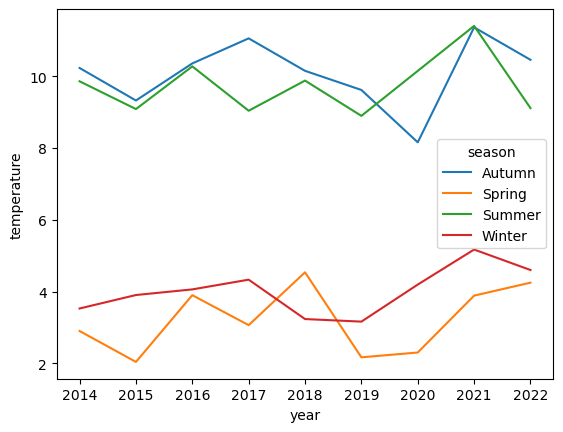

In [146]:
#seaborn season averages plot
sns.lineplot(x=year_season['year'],y=year_season['temperature'], hue=year_season["season"])

In [218]:
target_years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

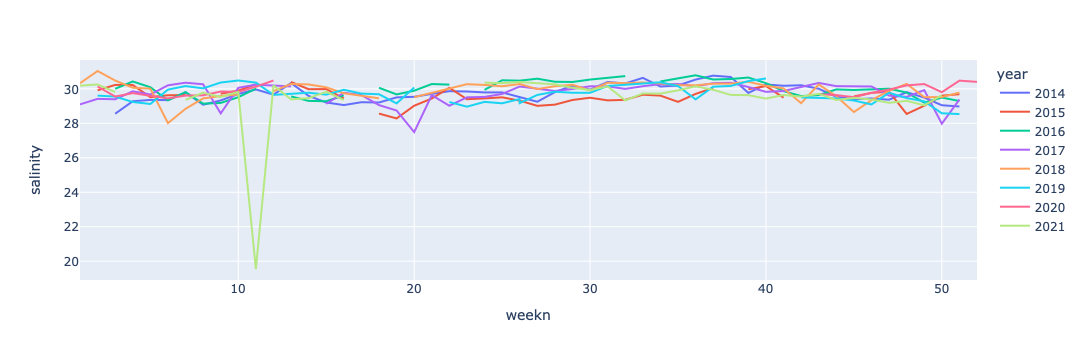

In [219]:
fig = px.line(shallow, x="weekn", y="salinity", color='year')
fig.show()

### Detect and plot anomalies in variables

In [148]:
def detect_anomalies(metadata, depth, yr=all, month=all):
    md_col = depth[['weekn', metadata, "year", "month"]].copy()
    md_col = md_col[md_col[metadata].notna()]
    if yr != all:
        #mdcol_yr = md_col[md_col.Year == yr]
        mdcol_yr = md_col[md_col['year'].isin(yr)]
    else: 
        mdcol_yr = md_col
        
    if month != all:
        #mdcol_yr = mdcol_yr[mdcol_yr.Month == month]
        mdcol_yr = mdcol_yr[mdcol_yr['month'].isin(month)]
    
    mdcol_yr = mdcol_yr.drop(columns=['year', "month"])
    mdcol_yr = mdcol_yr.set_index(['weekn'])
    
    #modelling time
    outliers_fraction = float(.01)
    scaler = StandardScaler()
    np_scaled = scaler.fit_transform(mdcol_yr.values.reshape(-1, 1))
    data = pd.DataFrame(np_scaled)
    # train isolation forest
    model =  IsolationForest(contamination=outliers_fraction)
    model.fit(data)
    
    #predict data
    mdcol_yr['anomaly'] = model.predict(data)
    
    
    # visualization
    fig, ax = plt.subplots(figsize=(10,6))
    a = mdcol_yr.loc[mdcol_yr['anomaly'] == -1, [metadata]] #anomaly
    ax.plot(mdcol_yr.index, mdcol_yr[metadata], color='black', label = 'Normal')
    ax.scatter(a.index,a[metadata], color='red', label = 'Anomaly')
    plt.axvline(36, ls='--')
    plt.legend()
    plt.show();
    #add axes names

In [151]:
all_md

,sampleid,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elution_volume,nifH,MetaG,new_id,notes,size_code,Tube Label BBYear.WeekDepthSize,filtration_volume,Notes,Unnamed: 15,16S V6V8\nIMR #,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,IMR # - V4V5,IMR # - 18S,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,Freezer Box (1.5mL),sample_code,month_name,month,day,time_string_x,season,time_string_y,julian_day,scan,temperature,conductivity,oxygenVoltage,fluorescence,unknown,pH,PSAR,salinity,theta,sigmaTheta,oxygen,scan2,fluorescence2,turbidity,oxygenCurrent,oxygenTemperature,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,bbmpdepth,fluorometer,par,flagArchaic,time_string_time,mission_descriptor,event_id,sample_id,latitude,longitude,time,Chlorophyll A,Nitrate,Nitrite,Phosphate,Silicate,Ammonia,Salinity,Temperature,HPLC_ALLOX,HPLC_BUT19,HPLC_CHLA,HPLC_CHLB,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON,time_string
0,BB14.3A,2014,15-Jan,3,1,A,01.15.1m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.3A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,1,15,2014-01-15,Winter,2014-01-15,15.0,4189.0,3.6047,0.593479,2.4356,2.2421,NaN,NaN,26.65400,27.0224,NaN,21.4785,7.06001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-15 13:08:32,18VA14667,2.0,387964.0,44.6917,-63.6417,1230.0,0.61,9.00,0.37,0.82,15.92,5.46,27.02,3.60,0.0,0.0,0.666,0.057,0.000,0.0,0.0,0.0,0.129,0.0,0.0,0.0,NaN,NaN,2014-01-15
1,BB14.3B,2014,15-Jan,3,5,B,01.15.5m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.3B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,1,15,2014-01-15,Winter,2014-01-15,15.0,4241.0,3.4460,0.627476,2.3669,2.0018,NaN,NaN,4.29590,28.8674,NaN,22.9584,6.80859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-15 13:08:32,18VA14667,2.0,387963.0,44.6917,-63.6417,1230.0,0.49,8.13,0.26,0.91,11.56,4.09,28.87,3.45,0.0,0.0,0.563,0.089,0.023,0.0,0.0,0.0,0.145,0.0,0.0,0.0,206.1,27.2,2014-01-15
2,BB14.3C,2014,15-Jan,3,10,C,01.15.10m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.3C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,1,15,2014-01-15,Winter,2014-01-15,15.0,4316.0,3.3400,0.638581,2.3104,1.9325,NaN,NaN,1.39900,29.5242,NaN,23.4898,6.48674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-15 13:08:32,18VA14667,2.0,387962.0,44.6917,-63.6417,1230.0,0.55,7.82,0.23,0.97,10.17,3.21,29.52,3.34,0.0,0.0,0.535,0.000,0.042,0.0,0.0,0.0,0.000,0.0,0.0,0.0,NaN,NaN,2014-01-15
3,BB14.3D,2014,15-Jan,3,60,D,01.15.60m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.3D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,1,15,2014-01-15,Winter,2014-01-15,15.0,5224.0,5.2532,0.708860,0.9694,1.6421,NaN,NaN,0.00331,31.2343,NaN,24.6642,1.56236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-15 13:08:32,18VA14667,2.0,387961.0,44.6917,-63.6417,1230.0,0.06,16.65,0.07,3.34,34.31,0.55,31.23,5.25,0.0,0.0,0.105,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,514.8,75.3,2014-01-15
4,BB14.4A,2014,23-Jan,4,1,A,01.23.1m,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,BB14.4A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jan,1,23,2014-01-23,Winter,2014-01-23,23.0,1823.0,1.0389,0.569014,2.3303,1.8339,0.613513,NaN,113.61000,27.9680,NaN,22.3930,7.37182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-23 13:43:59,18VA14667,3.0,387968.0,44.6917,-63.6417,1230.0,0.64,8.39,0.25,1.00,11.72,4.01,27.97,1.04,0.0,0.0,0.586,0.043,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,NaN,NaN,2014-01-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [150]:
detect_anomalies('Phosphate', all_md, yr={all}, month={7,8,9,10})

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by StandardScaler.

In [42]:
detect_anomalies('Phosphate', shallow, yr={2017}, month={7,8,9,10})

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by StandardScaler.

## Add prokaryotic community

In [16]:
# Special thanks to Alex Manuele https://github.com/alexmanuele
def consolidate_tables(year=all):
    if year == all:
        table_list = glob.glob('{0}/*/02-PROKs/DADA2/table.qza'.format('/Users/Diana/Documents/escuela/phd/ch2/splitted_data'))
        print("Found all yearly tables")
        
    else:
        table_list = glob.glob('{0}/02-PROKs/DADA2/table.qza'.format('/Users/Diana/Documents/escuela/phd/ch2/splitted_data/'+year))
        print("Found year "+year+" tables")
        
    dataframes = []  
    for table_path in table_list:
        with tempfile.TemporaryDirectory() as tempdir:
            #load table, dump contents to tempdir
            table = Artifact.load(table_path)
            #Make sure the tables are all FeatureFrequency type
            assert str(table.type) == 'FeatureTable[Frequency]', "{0}: Expected FeatureTable[Frequency], got {1}".format(table_path, table.type)
            Artifact.extract(table_path, tempdir)
            #get the provenance form the tempdir and format it for DF
            prov = '{0}/{1}/provenance/'.format(tempdir, table.uuid)
            action = yaml.load(open("{0}action/action.yaml".format(prov), 'r'), Loader=yaml.BaseLoader)
            paramlist = action['action']['parameters']
            paramlist.append({'table_uuid': "{}".format(table.uuid)})
            paramdict = {}
            for record in paramlist:
                paramdict.update(record)

            # Get the data into a dataframe
              #Biom data
            df = table.view(pd.DataFrame).unstack().reset_index()
            df.columns = ['feature_id', 'sample_name', 'feature_frequency']
            df['table_uuid'] = ["{}".format(table.uuid)] * df.shape[0]
              #param data
            pdf = pd.DataFrame.from_records([paramdict])
              #merge params into main df
            df = df.merge(pdf, on='table_uuid')
            

            #I like having these columns as the last three. Makes it more readable
            cols = df.columns.tolist()
            reorder = ['sample_name', 'feature_id', 'feature_frequency']
            for val in reorder:
                cols.append(cols.pop(cols.index(val)))
            df = df[cols]
            df['table_path'] = [table_path] * df.shape[0]
            df['sample_name'] = df['sample_name'].str.replace('-', '.')
            dataframes.append(df)
            
            # Adding table_id, forward and reverse trim columns
            #df['table_id'] = str(table_path.split('/')[-3]) #add a table_id column
            #df['forward_trim'], df['reverse_trim'] = df['table_id'].str.split('R', 1).str
            #df['forward_trim'] = df['forward_trim'].map(lambda x: x.lstrip('F'))
            #df["forward_trim"] = pd.to_numeric(df["forward_trim"])
            #df["reverse_trim"] = pd.to_numeric(df["reverse_trim"])

    #Stick all the dataframes together
    #outputfile="merged_all_tables.tsv"
    df = pd.concat(dataframes)
    #df.to_csv(comm+'/merged_all_tables.tsv', sep='\t', index=False)
    print("Successfully saved all tables.")
    return df

In [17]:
def merge_metadata(df):
    #df = pd.read_csv('02-PROKs/'+'/merged_all_tables.tsv', sep='\t')

    tables = df[['nouveau', 'feature_id', 'feature_frequency']].copy()
    tables.rename(columns={'nouveau':'sampleid'}, inplace=True)

    all_md['sampleid'] = all_md['sampleid'].str.replace('_', '.')
    
    #make sure all size codes are indicated
    all_md["size_code"] = all_md["sampleid"].str.extract(r'[1-9][0-9]?[A-E]([L-S])')
    all_md["size_code"] = all_md["size_code"].fillna('W')

    merged = pd.merge(tables,all_md, on='sampleid', how='left') #all_md is the metadata file
    merged = merged[merged.feature_frequency != 0]
    print('Set up metadata ...')
    
    #merged.to_csv(comm+'/merged_asvs_metadata.tsv', sep = '\t')
    print('Saved merged_asvs_metadata.tsv')
    
    return merged

In [18]:
def pick_metadata(merged, depth='all', size_fraction='both', year='all', R='all', F='all', txsubset = 'all'):
#make df of features/composition+run+comm

    depth = depth
    year = year
    size_fraction = size_fraction
    txsubset = txsubset
        
    files = glob.glob('{0}/20**/taxa*/classification/*/data/taxonomy.tsv'.format('/Users/Diana/Documents/escuela/phd/ch2/bb_data'))
    taxos = []
#    if not os.path.exists(path+composition):
#        os.mkdir(path+composition)
    for filename in files:
        tax = pd.read_csv(filename, sep='\t')
        taxos.append(tax)
        
    print('Appended all taxonomies to taxos')
    taxos = pd.concat(taxos)
    taxos = taxos.rename(columns={"Feature ID": "feature_id"}, errors="raise")
    taxos = taxos.drop_duplicates()

    separated = merged.merge(taxos, how='left', on='feature_id') #merged excludes features of frequency = 0
    separated = separated.drop_duplicates()
    
    if depth != 'all':
        separated = separated[separated["depth"] == depth]
    if size_fraction != 'both':
        separated = separated[separated["size_fraction"] == size_fraction]
        
    #recalculate ratios
    separated['Total'] = separated['feature_frequency'].groupby(separated['sampleid']).transform('sum')
    separated['ratio'] = separated['feature_frequency']/separated['Total']
    separated['nASVs'] = separated['feature_id'].groupby(separated['sampleid']).transform('nunique')
    
    separated = separated.drop_duplicates()
    
    
    #separated['total'] = separated.groupby(['table_id','sample-id'])['feature_frequency'].transform('sum')
    #separated['ratio'] = separated['feature_frequency']/(separated['total'])
    #separated_taxonomies = separated.copy()
    
    #make a dictionary with keys for id-ing the taxon belonging to this sub-community
    #separated_dic = pd.Series(separated.Taxon.values,separated.feature_id.values).to_dict()
    print('Saved separated by metadata dataframe.')
    
    return separated

In [19]:
df = consolidate_tables(year=all)

Found all yearly tables
Successfully saved all tables.


In [20]:
df['sample_name'] = df['sample_name'].replace({'\.0':'.'}, regex=True)
#some sample names included the lane number
df['nouveau']=df['sample_name'].str.split('.').str[:2].str.join('.')

In [21]:
merged = merge_metadata(df)

Set up metadata ...
Saved merged_asvs_metadata.tsv


In [22]:
separated = pick_metadata(merged)

Appended all taxonomies to taxos
Saved separated by metadata dataframe.


In [23]:
tiprob = separated[separated['feature_id'].isnull()]
tiprob['sampleid'].unique()

array([], dtype=object)

problematique = ['BB17.28B', 
                 'BB19.a35BS','BB19.a35CS', 
                 'BB21.16AL', 
                 'BB18.13.BS','BB18.13.CL', 'BB18.13CDS', 'BB18.45ALb', 'BB18.45ASb', 'BB18.45BLb', 'BB18.45BSb', 'BB18.45CLb', 'BB18.45CSb','BB18.45DLb', 'BB18.45DSb', 
                 'BB16.12A', 'BB16.12B', 'BB16.12C','BB16.12D']
#anything after week 32 in year 2021
#weeks 12 to 37 are missing from 2020
#BB17 _ 28B is missing; no notes in the metadata file
#BB19 a35BS and CS were accidently combined
#no idea why BB21-16AL is missing
#all the BB18 45__b were extracted by accident
#BB16 week 12 no samples


In [24]:
#only keep size fractionated samples
sep_SL = all_md[all_md.size_code != "W"]

In [25]:
#sum [DNA] of small and large size fractions
sep_SL['[DNAt]'] = sep_SL.groupby(['weekn', 'depth', 'year'])['[DNA]ng/uL'].transform('sum')

#calculate DNA proportion per size fraction
sep_SL['DNApr'] = sep_SL['[DNA]ng/uL']/sep_SL['[DNAt]']

#merge with separated on common columns to get corresponding rel. abundances
sep_SL = sep_SL[['sampleid', 'DNApr', '[DNAt]']].copy()
sepSLRA = pd.merge(separated, sep_SL, on=['sampleid'], how='left') #all_md is the metadata file

#exclude ASVs from the whole water
sep_SLRA = sepSLRA[separated.size_code != "W"]

#calculate corrected per sample ratio, and corrected feature frequency of de-fractionated samples
sep_SLRA['Newfeature_frequency'] = sep_SLRA['feature_frequency'] * sep_SLRA['DNApr']
sep_SLRA['Newff'] = sep_SLRA.groupby(['feature_id', 'weekn', 'depth', 'year'])['Newfeature_frequency'].transform('sum')

#sep_SLRA = sep_SLRA.drop(['sampleid', 'size_code'], axis=1)
sep_SLRA['sampleid'] = sep_SLRA['sampleid'].str.split('.').str.get(0) + '.' + sep_SLRA['weekn'].astype(str).str.replace(".0","",regex=False) + sep_SLRA['depth_code'] + "SL"

sep_SLRA[sep_SLRA['Newfeature_frequency'] < 0].values.any()

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/198632152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sep_SL['[DNAt]'] = sep_SL.groupby(['weekn', 'depth', 'year'])['[DNA]ng/uL'].transform('sum')
/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/198632152.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sep_SL['DNApr'] = sep_SL['[DNA]ng/uL']/sep_SL['[DNAt]']
/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/198632152.py:15: SettingWithCopyWarning: 
A 

False

In [26]:
#uncomment the line below if keeping small and large original sample
#sep_SLRA['size_code'] = sep_SLRA['size_code'] + '-DFr'

#uncomment the line above if merging smallandlarge
sep_SLRA['size_code'] = 'SL'

#drop unecessary columns which might rise merging conflicts
sep_SLRA = sep_SLRA.drop(['feature_frequency', 'Total', 'ratio', 'nASVs', 'extraction_date', '[DNA]ng/uL', 'A260/280',
                          'Newfeature_frequency'], axis=1)

sep_SLRA[sep_SLRA['Newff'] < 0].values.any()

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/1197955242.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sep_SLRA['size_code'] = 'SL'


False

In [27]:
sep_SLRA.rename(columns={'Newff':'feature_frequency'}, inplace=True)
sep_SLRA = sep_SLRA.drop_duplicates()

sep_SLRA[sep_SLRA['feature_frequency'] < 0].values.any()

False

In [28]:
#recalculate ratios
sep_SLRA['Total'] = sep_SLRA['feature_frequency'].groupby(sep_SLRA['sampleid']).transform('sum')
sep_SLRA['ratio'] = sep_SLRA['feature_frequency']/sep_SLRA['Total']
sep_SLRA['nASVs'] = sep_SLRA['feature_id'].groupby(sep_SLRA['sampleid']).transform('nunique')

sep_SLRA = sep_SLRA.drop_duplicates()

sep_SLRA[sep_SLRA['feature_frequency'] < 0].values.any()

False

In [29]:
#make new df dependingg on plotting needs
sep_WO = separated[separated.size_code == "W"]

newseparated = pd.concat([sep_SLRA, sep_WO], ignore_index=True)

In [30]:
newseparated[newseparated['feature_frequency'] < 0].values.any()

False

In [31]:
tstprjulie = separated[separated['year'] == 2019]

In [32]:
tiprob = tstprjulie[tstprjulie['feature_id'].isnull()]
tiprob['sampleid'].unique()

array([], dtype=object)

In [33]:
tst = separated[separated['year'] == 2019]
copy_of = tstprjulie.copy()
copy_of[['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']] = copy_of['Taxon'].str.split('; ', expand=True)

In [50]:
copy_of = separated.copy()

In [51]:
copy_of[['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']] = copy_of['Taxon'].str.split('; ', expand=True)

In [52]:
res = sns.kdeplot(copy_of['year'],copy_of['temperature'],color='blue',shade=True)
plt.show()
plt.savefig('kdeplot', format="svg")

TypeError: kdeplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

In [27]:
copy_of.groupby('sampleid')['feature_id'].nunique()

sampleid
BB14.10A                 0
BB14.10A.S148.L001.    292
BB14.10B                 0
BB14.10B.S160.L001.    285
BB14.10C                 0
                      ... 
BB21.9CL                 0
BB21.9CS                 0
BB21.9DL                 0
BB21.9DS                 0
BB2140CL                 0
Name: feature_id, Length: 3480, dtype: int64

In [28]:
#check for columns with missing values
copy_of.isnull().any()

sampleid             False
feature_id            True
feature_frequency     True
year                  True
date                  True
                     ...  
Class                 True
Order                 True
Family                True
Genus                 True
Species               True
Length: 111, dtype: bool

In [53]:
y2014=copy_of[copy_of.year==2014]
y2015=copy_of[copy_of.year==2015]
y2016=copy_of[copy_of.year==2016]
y2017=copy_of[copy_of.year==2017]
y2018=copy_of[copy_of.year==2018]
y2019=copy_of[copy_of.year==2019]
y2020=copy_of[copy_of.year==2020]
y2021=copy_of[copy_of.year==2021]

In [38]:
toptaxa = y2014[['feature_id', 'feature_frequency', 'season', 'depth', 'Taxon' ]].copy()

In [39]:
toptaxa = toptaxa.drop_duplicates()

In [40]:
toptaxaeuph=toptaxa[copy_of.year==2014]

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/3346504446.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  toptaxaeuph=toptaxa[copy_of.year==2014]


In [81]:
copy_ofD1_SEP[copy_ofD1_SEP.year== 2019]

,sampleid,feature_id,feature_frequency,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elution_volume,nifH,MetaG,new_id,notes,size_code,Tube Label BBYear.WeekDepthSize,filtration_volume,Notes,Unnamed: 15,16S V6V8\nIMR #,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,IMR # - V4V5,IMR # - 18S,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,Freezer Box (1.5mL),sample_code,month_name,month,day,time_string_x,season,time_string_y,julian_day,scan,temperature,conductivity,oxygenVoltage,fluorescence,unknown,pH,PSAR,salinity,theta,sigmaTheta,oxygen,scan2,fluorescence2,turbidity,oxygenCurrent,oxygenTemperature,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,bbmpdepth,fluorometer,par,flagArchaic,time_string_time,mission_descriptor,event_id,sample_id,latitude,longitude,time,Chlorophyll A,Nitrate,Nitrite,Phosphate,Silicate,Ammonia,Salinity,Temperature,HPLC_ALLOX,HPLC_BUT19,HPLC_CHLA,HPLC_CHLB,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON,time_string,Taxon,Confidence,Total,ratio,nASVs,Domain,Phylum,Class,Order,Family,Genus,Species
159703,BB19.44AL,af4ec853b8f3af897984b19fd4b71d91,162.0,2019.0,30-Oct,44.0,1.0,A,NaN,59.9,1.81,Oct 28/20,BL,NaN,NaN,50.0,+,NaN,BB19.44AL,NaN,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413.0,414.0,44.0,BB19.44AL,NaN,"27 - qPCR, 2.5 - nifH",NaN,NaN,Oct,10.0,30.0,2019-10-30,Autumn,2019-10-30,303.0,1793.0,11.2170,0.769187,3.1107,4.0876,NaN,8.320,157.440,28.8754,11.2169,21.9747,8.1546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-10-30 15:01:49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.961687,40330.0,0.004017,484,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Planktomarina,None
159704,BB19.44AS,af4ec853b8f3af897984b19fd4b71d91,8544.0,2019.0,30-Oct,44.0,1.0,A,NaN,79.7,1.76,Oct 28/20,BL,NaN,NaN,50.0,+,NaN,BB19.44AS,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413.0,414.0,44.0,BB19.44AS,NaN,"27 - qPCR, 2.5 - nifH",NaN,NaN,Oct,10.0,30.0,2019-10-30,Autumn,2019-10-30,303.0,1793.0,11.2170,0.769187,3.1107,4.0876,NaN,8.320,157.440,28.8754,11.2169,21.9747,8.1546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-10-30 15:01:49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.961687,59787.0,0.142907,547,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Planktomarina,None
159711,BB19.45AL,af4ec853b8f3af897984b19fd4b71d91,215.0,2019.0,06-Nov,45.0,1.0,A,NaN,30.4,1.75,Oct 28/20,BL,NaN,NaN,50.0,NaN,NaN,BB19.45AL,NaN,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413.0,414.0,45.0,BB19.45AL,NaN,"27 - qPCR, 2.5 - nifH",NaN,NaN,Nov,11.0,6.0,2019-11-06,Autumn,2019-11-06,310.0,1675.0,11.3916,0.777831,2.7861,13.1233,NaN,8.203,81.558,29.0977,11.3915,22.1174,7.3747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-11-06 13:59:33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.961687,93150.0,0.002308,1162,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Planktomarina,None
159712,BB19.45AS,af4ec853b8f3af897984b19fd4b71d91,6274.0,2019.0,06-Nov,45.0,1.0,A,NaN,61.9,1.82,Oct 28/20,BL,NaN,NaN,50.0,NaN,NaN,BB19.45AS,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413.0,414.0,45.0,BB19.45AS,NaN,"27 - qPCR, 2.5 - nifH",NaN,NaN,Nov,11.0,6.0,2019-11-06,Autumn,2019-11-06,310.0,1675.0,11.3916,0.777831,2.7861,13.1233,NaN,8.203,81.558,29.0977,11.3915,22.1174,7.3747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-11-06 13:59:33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [94]:
copy_ofD1=copy_of[copy_of.depth==60]

In [95]:
copy_ofD1_SEP=copy_ofD1[copy_ofD1.weekn>31]

In [96]:
copy_ofD1_SEP=copy_ofD1_SEP[copy_ofD1_SEP.weekn<50]

/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_40087/1690399222.py:2: UserWarning: The palette list has more values (9) than needed (7), which may not be intended.
  ax=sns.lineplot(x = "weekn", y = "nASVs", data=copy_ofD1_SEP, hue="year", palette=palette,)


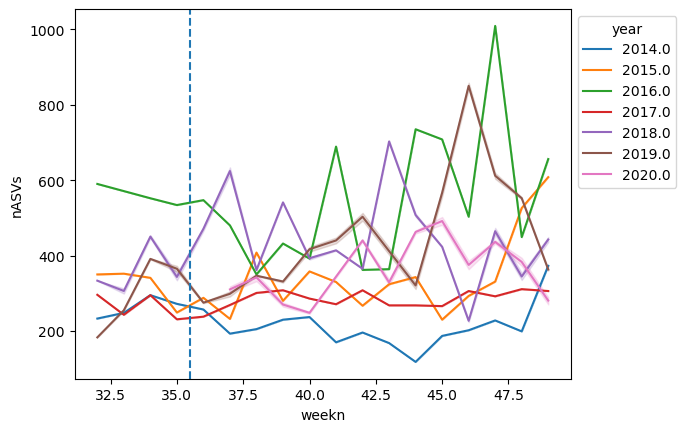

In [97]:
palette = sns.color_palette("tab10", 9)
ax=sns.lineplot(x = "weekn", y = "nASVs", data=copy_ofD1_SEP, hue="year", palette=palette,)
plt.axvline(35.5, ls='--')
sns.move_legend(ax,"upper left", bbox_to_anchor=(1, 1))
plt.show()

In [44]:
copy_of

,sampleid,feature_id,feature_frequency,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elution_volume,nifH,MetaG,new_id,notes,size_code,Tube Label BBYear.WeekDepthSize,filtration_volume,Notes,Unnamed: 15,16S V6V8\nIMR #,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,IMR # - V4V5,IMR # - 18S,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,Freezer Box (1.5mL),sample_code,month_name,month,day,time_string_x,season,time_string_y,julian_day,scan,temperature,conductivity,oxygenVoltage,fluorescence,unknown,pH,PSAR,salinity,theta,sigmaTheta,oxygen,scan2,fluorescence2,turbidity,oxygenCurrent,oxygenTemperature,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,bbmpdepth,fluorometer,par,flagArchaic,time_string_time,mission_descriptor,event_id,sample_id,latitude,longitude,time,Chlorophyll A,Nitrate,Nitrite,Phosphate,Silicate,Ammonia,Salinity,Temperature,HPLC_ALLOX,HPLC_BUT19,HPLC_CHLA,HPLC_CHLB,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON,time_string,Taxon,Confidence,Total,ratio,nASVs,Domain,Phylum,Class,Order,Family,Genus,Species
159497,BB19.18AS,75ceeaa937c64399438614ca3706cf2a,475.0,2019.0,01-May,18.0,1.0,A,NaN,18.2,1.69,OCT 22 2021,Sonja Rose,NaN,NaN,NaN,NaN,NaN,BB19.18AS,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,BB19.18AS,5-62,NaN,NaN,NaN,May,5.0,1.0,2019-05-01,Spring,2019-05-01,121.0,3988.0,3.7543,0.628420,3.6669,3.0671,NaN,8.642,61.03900,28.6434,3.7543,22.7547,8.4448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-01 12:28:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.0,30588.0,0.015529,464,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis
159498,BB19.18BL,75ceeaa937c64399438614ca3706cf2a,117.0,2019.0,01-May,18.0,5.0,B,NaN,21.7,1.69,OCT 22 2021,Sonja Rose,NaN,NaN,NaN,NaN,NaN,BB19.18BL,NaN,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,BB19.18BL,5-63,NaN,NaN,NaN,May,5.0,1.0,2019-05-01,Spring,2019-05-01,121.0,3556.0,2.8705,0.635848,3.5071,9.0103,NaN,8.431,35.17400,29.8186,2.8702,23.7613,7.7758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-01 12:28:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.0,85128.0,0.001374,477,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis
159499,BB19.18BS,75ceeaa937c64399438614ca3706cf2a,10572.0,2019.0,01-May,18.0,5.0,B,NaN,16.1,1.78,OCT 22 2021,Sonja Rose,NaN,NaN,NaN,NaN,NaN,BB19.18BS,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,BB19.18BS,5-64,NaN,NaN,NaN,May,5.0,1.0,2019-05-01,Spring,2019-05-01,121.0,3556.0,2.8705,0.635848,3.5071,9.0103,NaN,8.431,35.17400,29.8186,2.8702,23.7613,7.7758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-01 12:28:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,1.0,21688.0,0.487459,304,d__Bacteria,p__Cyanobacteria,c__Cyanobacteriia,o__Chloroplast,f__Chloroplast,g__Chloroplast,s__Eutreptiella_pomquetensis
159500,BB19.18CL,75ceeaa937c64399438614ca3706cf2a,858.0,2019.0,01-May,18.0,10.0,C,NaN,37.5,1.73,OCT 22 2021,Sonja Rose,NaN,NaN,NaN,NaN,NaN,BB19.18CL,NaN,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,BB19.18CL,5-65,NaN,NaN,NaN,May,5.0,1.0,2019-05-01,Spring,2019-05-01,121.0,3637.0,1.9510,0.633594,3.3097,3.6453,NaN,8.306,14.35900,30.5686,1.9505,24.4263,7.6454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-01 12:28:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bac

In [46]:
y2019=y2019[y2019.depth==1]

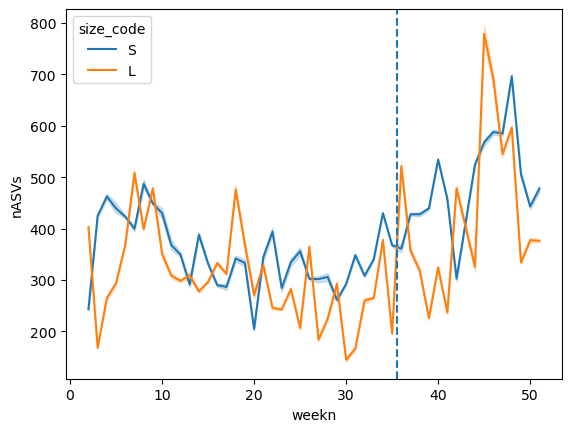

In [98]:
sns.lineplot(x = "weekn", y = "nASVs", data=y2019, hue="size_code")
plt.axvline(35.5, ls='--')
plt.show()

In [103]:
import itertools

In [104]:
taxbarplot_by_year("comm", y2019, 'Family', 5, 15, include_other=False)

{}

In [116]:
y2019wks = y2019[y2019.weekn > 32]
y2019wks = y2019wks[y2019wks.weekn < 43]

In [118]:
y2018wks = y2018[y2018.weekn > 32]
y2018wks = y2018wks[y2018wks.weekn < 43]

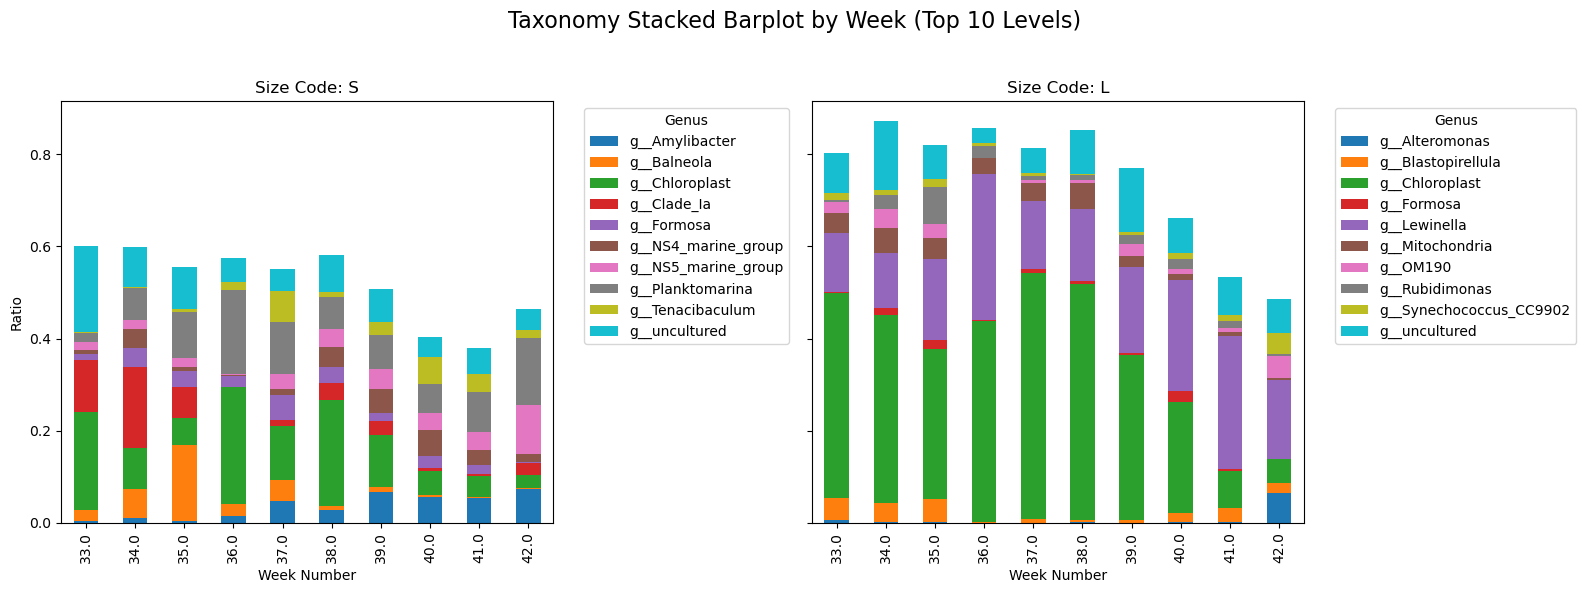

In [120]:
plot_taxonomy_barplot(y2018wks, 'Genus', 1, topn=10, show_other=False)

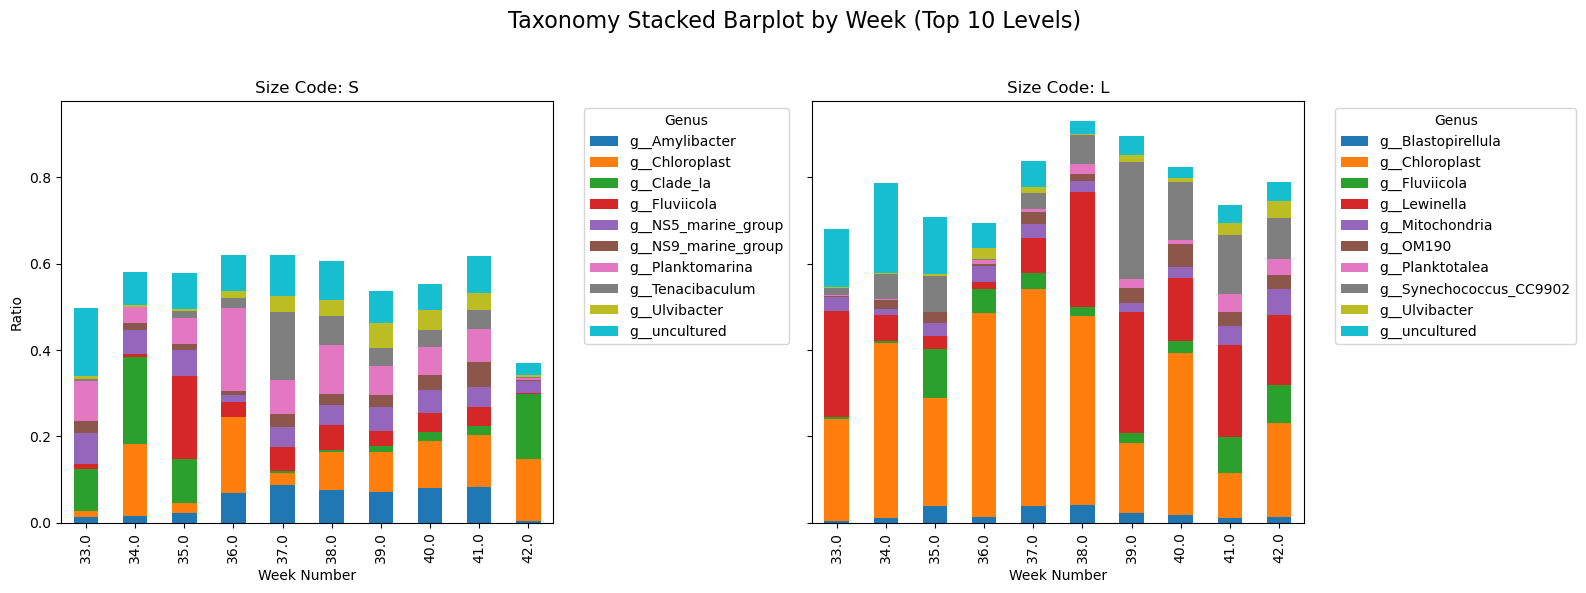

In [121]:
plot_taxonomy_barplot(y2019wks, 'Genus', 1, topn=10, show_other=False)

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_taxonomy_barplot(df, level, depth='all', topn=10, show_other=True):
    """
    Plots a stacked barplot time series for taxonomy data for size_code "S" and "L".

    For each size code, the x-axis is the week number (weekn) and the y-axis is the sum of ratios.
    The bars are stacked by the taxonomy level given by the column name 'level'.
    The function computes the top 'topn' most abundant taxonomy levels (across all weeks for each size code)
    and either aggregates the remaining levels into an "Other" category (if show_other=True) or excludes them.

    Parameters:
      df (pd.DataFrame): DataFrame containing at least the columns:
                         - weekn: week number
                         - ratio: relative abundance value for the feature
                         - size_code: should be either "S" or "L"
                         - depth: for filtering (if depth != 'all')
                         - level: a column with the taxonomy identification for each feature
      level (str): The name of the column in df that holds the taxonomy level.
      depth (str/int, optional): Depth value to filter by. If 'all', no filtering on depth is applied.
      topn (int, optional): The number of top abundant taxonomy levels to display.
      show_other (bool, optional): If True, aggregates levels not in the topn as "Other".
    """
    # Filter by depth if needed
    if depth != 'all':
        df = df[df['depth'] == depth]
    
    # Keep only size codes "S" and "L"
    df = df[df['size_code'].isin(['S', 'L'])]
    
    # Create subplots for the two size codes
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    for ax, size in zip(axes, ['S', 'L']):
        # Filter data for the current size code
        df_size = df[df['size_code'] == size]
        
        # Group by week number and taxonomy level, summing the ratio values
        grouped = df_size.groupby(['weekn', level])['ratio'].sum().reset_index()
        
        # Compute overall abundance per taxonomy level (across all weeks) to decide the top n
        overall = grouped.groupby(level)['ratio'].sum().reset_index()
        overall = overall.sort_values(by='ratio', ascending=False)
        top_levels = overall[level].head(topn).tolist()
        
        # For each row, assign taxonomy level as itself if in top_levels,
        # otherwise as "Other" (if show_other) or drop later (if not show_other)
        if show_other:
            grouped[level] = grouped[level].apply(lambda x: x if x in top_levels else "Other")
        else:
            grouped = grouped[grouped[level].isin(top_levels)]
        
        # Re-group in case multiple rows now belong to "Other"
        grouped = grouped.groupby(['weekn', level])['ratio'].sum().reset_index()
        
        # Pivot so that each weekn becomes a row and each taxonomy level becomes a column
        pivoted = grouped.pivot(index='weekn', columns=level, values='ratio').fillna(0)
        pivoted = pivoted.sort_index()  # sort by week number
        
        # Plot the stacked barplot for this size code
        pivoted.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f"Size Code: {size}")
        ax.set_xlabel("Week Number")
        ax.set_ylabel("Ratio")
        ax.legend(title=level, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.suptitle(f"Taxonomy Stacked Barplot by Week (Top {topn} Levels)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [134]:
copy_of

,sampleid,feature_id,feature_frequency,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elution_volume,nifH,MetaG,new_id,notes,size_code,Tube Label BBYear.WeekDepthSize,filtration_volume,Notes,Unnamed: 15,16S V6V8\nIMR #,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,IMR # - V4V5,IMR # - 18S,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,Freezer Box (1.5mL),sample_code,month_name,month,day,time_string_x,season,time_string_y,julian_day,scan,temperature,conductivity,oxygenVoltage,fluorescence,unknown,pH,PSAR,salinity,theta,sigmaTheta,oxygen,scan2,fluorescence2,turbidity,oxygenCurrent,oxygenTemperature,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,bbmpdepth,fluorometer,par,flagArchaic,time_string_time,mission_descriptor,event_id,sample_id,latitude,longitude,time,Chlorophyll A,Nitrate,Nitrite,Phosphate,Silicate,Ammonia,Salinity,Temperature,HPLC_ALLOX,HPLC_BUT19,HPLC_CHLA,HPLC_CHLB,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON,time_string,Taxon,Confidence,Total,ratio,nASVs,Domain,Phylum,Class,Order,Family,Genus,Species
0,BB14.10A,df29deb0aff9e983f503e7471e71f4ec,3295.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,W,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,Spring,2014-03-05,64.0,1970.0,0.3580,0.581948,2.5917,2.8321,-0.065100,NaN,237.59000,29.3043,NaN,23.4968,7.61853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,18VA14667,9.0,387992.0,44.6917,-63.6417,1230.0,3.82,7.81,0.20,0.76,7.89,1.98,29.30,0.36,0.0,0.0,3.904,0.135,0.717,0.000,0.450,0.000,1.878,0.0,0.0,0.0,NaN,NaN,2014-03-05,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,30101.0,0.109465,292,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,None
1,BB14.10B,df29deb0aff9e983f503e7471e71f4ec,4254.0,2014.0,05-Mar,10.0,5.0,B,03.05.5m,3.8,2.20,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10B,NaN,W,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,Spring,2014-03-05,64.0,1959.0,0.6673,0.589958,2.5980,4.3993,0.000000,NaN,71.67500,29.4484,NaN,23.5994,7.43257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,18VA14667,9.0,387991.0,44.6917,-63.6417,1230.0,3.82,7.81,0.20,0.76,8.30,1.92,29.45,0.67,0.0,0.0,3.535,0.000,0.643,0.174,0.373,0.000,1.704,0.0,0.0,0.0,305.3,47.9,2014-03-05,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,27296.0,0.155847,285,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,None
2,BB14.10C,df29deb0aff9e983f503e7471e71f4ec,3931.0,2014.0,05-Mar,10.0,10.0,C,03.05.10m,2.9,2.66,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10C,NaN,W,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,Spring,2014-03-05,64.0,2026.0,1.5069,0.619813,2.4818,3.2060,0.000643,NaN,22.50400,30.2612,NaN,24.2080,6.85916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,18VA14667,9.0,387990.0,44.6917,-63.6417,1230.0,2.16,8.51,0.18,0.85,9.09,1.67,30.26,1.51,0.0,0.0,2.393,0.000,0.346,0.000,0.119,0.000,1.209,0.0,0.0,0.0,NaN,NaN,2014-03-05,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.945295,22612.0,0.173846,256,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,g__Sulfitobacter,None
3,BB14.10D,df29deb0aff9e983f503e7471e71f4ec,654.0,2014.0,05-Mar,10.0,60.0,D,03.05.60m,3.7,2.26,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10D,NaN,W,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,Spring,2014-03-05,64.0,2886.0,3.4331,0.667837,1.6183,1.6402,1.482612,NaN,0.00345,30.9043,NaN,24.5810,3.59609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,18VA14667,9.0,387989.0,44.691

In [140]:
copy_of2 = copy_of[copy_of.weekn > 31]
copy_of2 = copy_of2[copy_of2.weekn < 43]

In [148]:
copy_of2 = copy_of2[copy_of2.year != 2020]

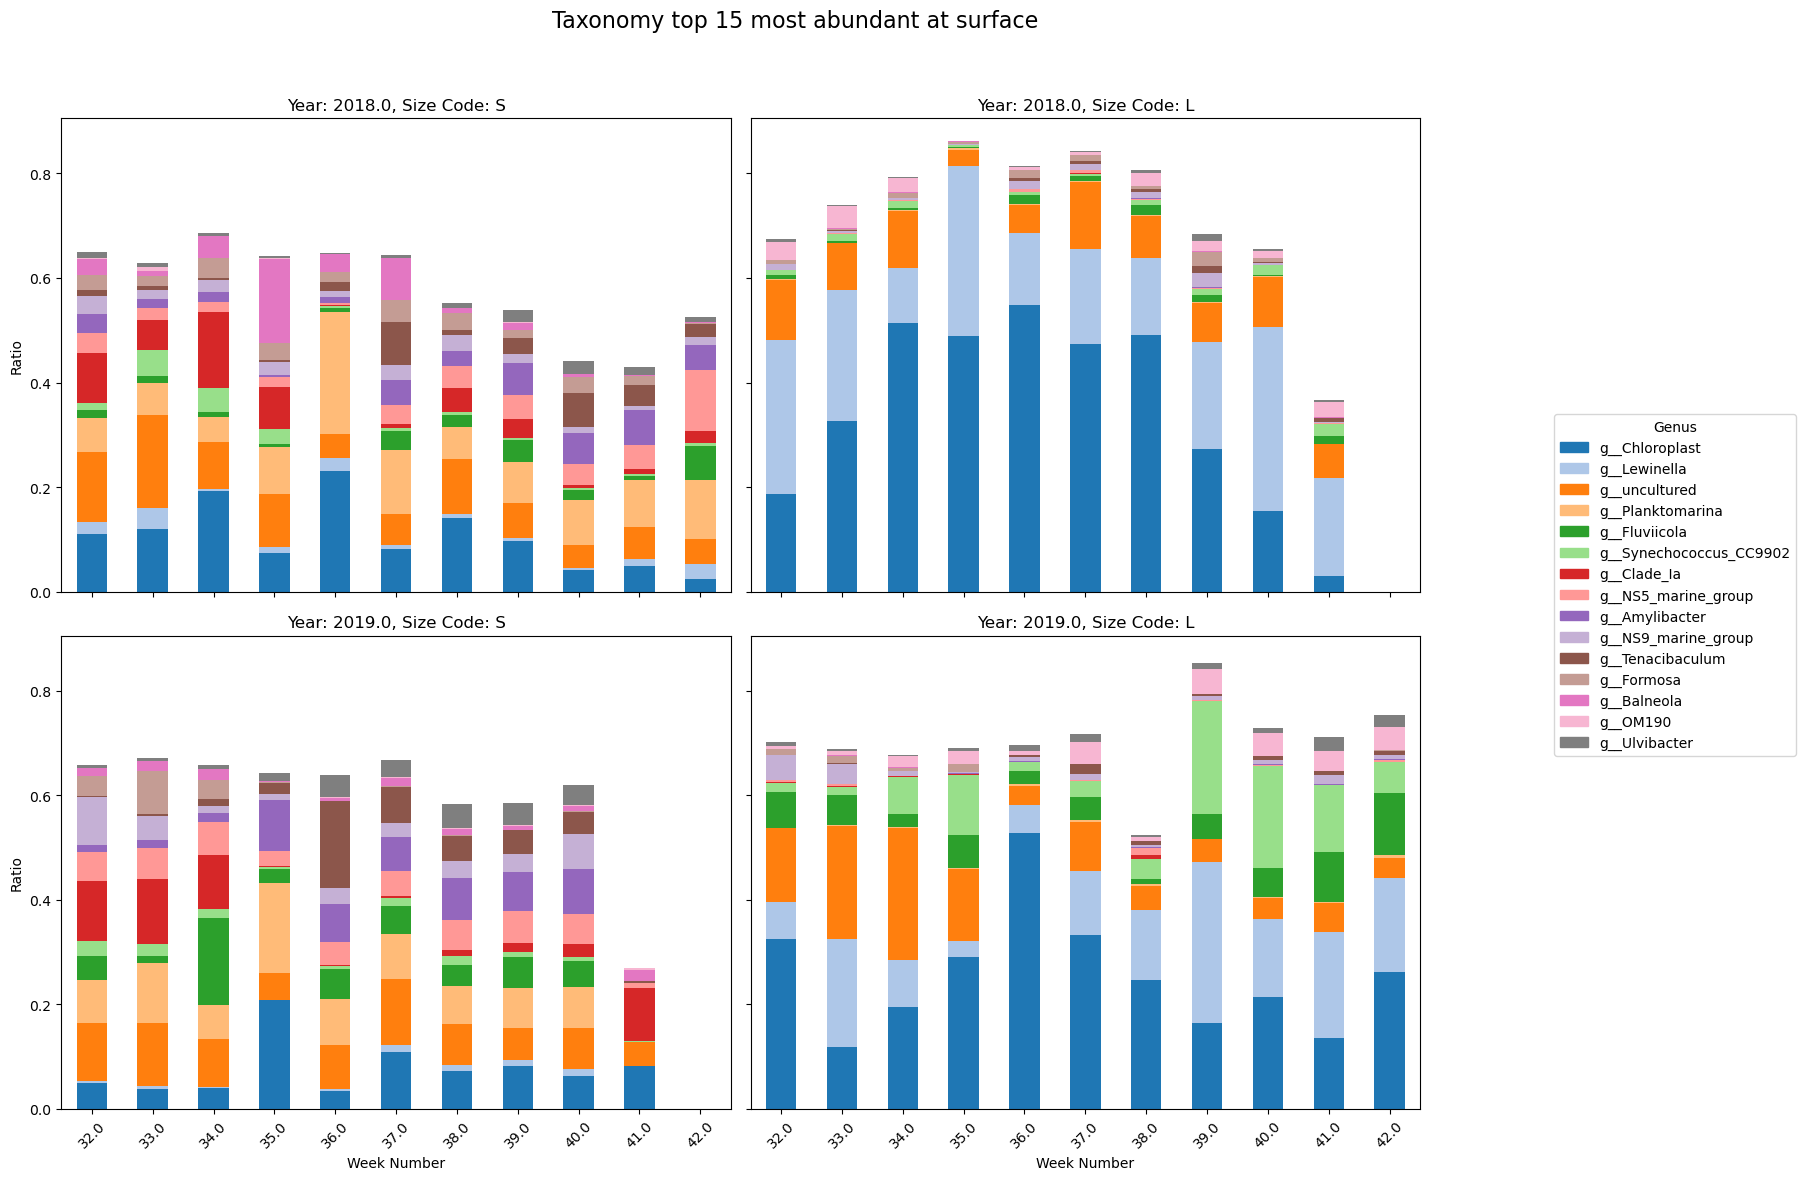

In [157]:
plot_taxonomy_barplot_by_year(copy_of2, 'Genus', 5, topn=15, show_other=False)

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_taxonomy_barplot_by_year(df, level, depth='all', topn=10, show_other=True):
    """
    For a given DataFrame, plots a stacked barplot time series for each year.
    For each year, two subplots are created (one for size_code "S" and one for "L").
    
    The x-axis is the week number (weekn) and the y-axis is the summed ratio.
    The bars are stacked by taxonomy level given by the column `level`.
    
    The top `topn` most abundant taxonomy levels are determined across ALL years,
    ensuring a consistent color mapping across the subplots. Taxonomy levels not in the topn
    are either aggregated into an "Other" category (if show_other=True) or dropped.
    
    Parameters:
      df (pd.DataFrame): Data containing at least the columns:
                         - weekn: week number (x-axis)
                         - ratio: relative abundance value for the feature
                         - size_code: either "S" or "L"
                         - depth: for filtering (if depth != 'all')
                         - year: the year of the sample
                         - level: the taxonomy identification column to use as stacking hue.
      level (str): The name of the column in df that holds the taxonomy level.
      depth (str/int, optional): If not 'all', filters the data to only rows with this depth.
      topn (int, optional): The number of top taxonomy levels (by overall summed ratio) to display.
      show_other (bool, optional): If True, groups taxonomy levels not in the topn as "Other".
    """
    
    df = df[df['feature_frequency'] != 0]
    
    # Filter by depth if necessary.
    if depth != 'all':
        df = df[df['depth'] == depth]
    
    # Keep only size_code "S" and "L"
    df = df[df['size_code'].isin(['S', 'L'])]
    
    # Determine overall top taxonomy levels (across all years and size codes)
    overall = df.groupby(level)['ratio'].sum().reset_index()
    overall = overall.sort_values(by='ratio', ascending=False).reset_index(drop=True)
    top_categories = overall[level].head(topn).tolist()
    
    # If including "Other", add that to our list of categories.
    categories = top_categories.copy()
    if show_other:
        categories.append("Other")
    
    # Set a consistent color palette using seaborn.
    palette = sns.color_palette("tab20", len(categories))
    palette_dict = dict(zip(categories, palette))
    
    # Determine unique years (sorted)
    years = sorted(df['year'].unique())
    
    # Create a figure with rows = number of years and 2 columns (for "S" and "L")
    n_years = len(years)
    fig, axes = plt.subplots(n_years, 2, figsize=(16, 6 * n_years), sharex=True, sharey=True)
    
    # If only one year exists, ensure axes is 2D
    if n_years == 1:
        axes = [axes]
    
    for i, year in enumerate(years):
        for j, size in enumerate(['S', 'L']):
            # Select the proper axis (axes is 2D: row for year, col for size)
            ax = axes[i][j]
            
            # Filter data for the specific year and size_code
            df_subset = df[(df['year'] == year) & (df['size_code'] == size)]
            
            # Group by week number and taxonomy level, summing the ratio values.
            grouped = df_subset.groupby(['weekn', level])['ratio'].sum().reset_index()
            
            # If show_other, reassign taxonomy levels not in top_categories to "Other"
            if show_other:
                grouped[level] = grouped[level].apply(lambda x: x if x in top_categories else "Other")
            else:
                grouped = grouped[grouped[level].isin(top_categories)]
            
            # Re-group in case multiple rows now have the same taxonomy (e.g. "Other")
            grouped = grouped.groupby(['weekn', level])['ratio'].sum().reset_index()
            
            # Pivot the data: rows are weekn, columns are taxonomy levels
            pivoted = grouped.pivot(index='weekn', columns=level, values='ratio').fillna(0)
            # Ensure all desired categories are present, even if some are missing for this subset.
            for cat in categories:
                if cat not in pivoted.columns:
                    pivoted[cat] = 0
            pivoted = pivoted[categories]  # order columns by our defined order
            pivoted = pivoted.sort_index()  # sort rows by week number
            
            # Plot the stacked barplot.
            pivoted.plot(kind='bar', stacked=True, ax=ax, color=[palette_dict[c] for c in pivoted.columns], legend=False)
            ax.set_title(f"Year: {year}, Size Code: {size}")
            ax.set_xlabel("Week Number")
            ax.set_ylabel("Ratio")
            ax.set_xticklabels(pivoted.index.astype(str), rotation=45)
    
    # Create a common legend outside the subplots.
    handles = [plt.Rectangle((0,0),1,1, color=palette_dict[cat]) for cat in categories]
    fig.legend(handles, categories, title=level, bbox_to_anchor=(1.05, 0.5), loc='center')
    
    plt.suptitle(f"Taxonomy top {topn} most abundant at surface", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()


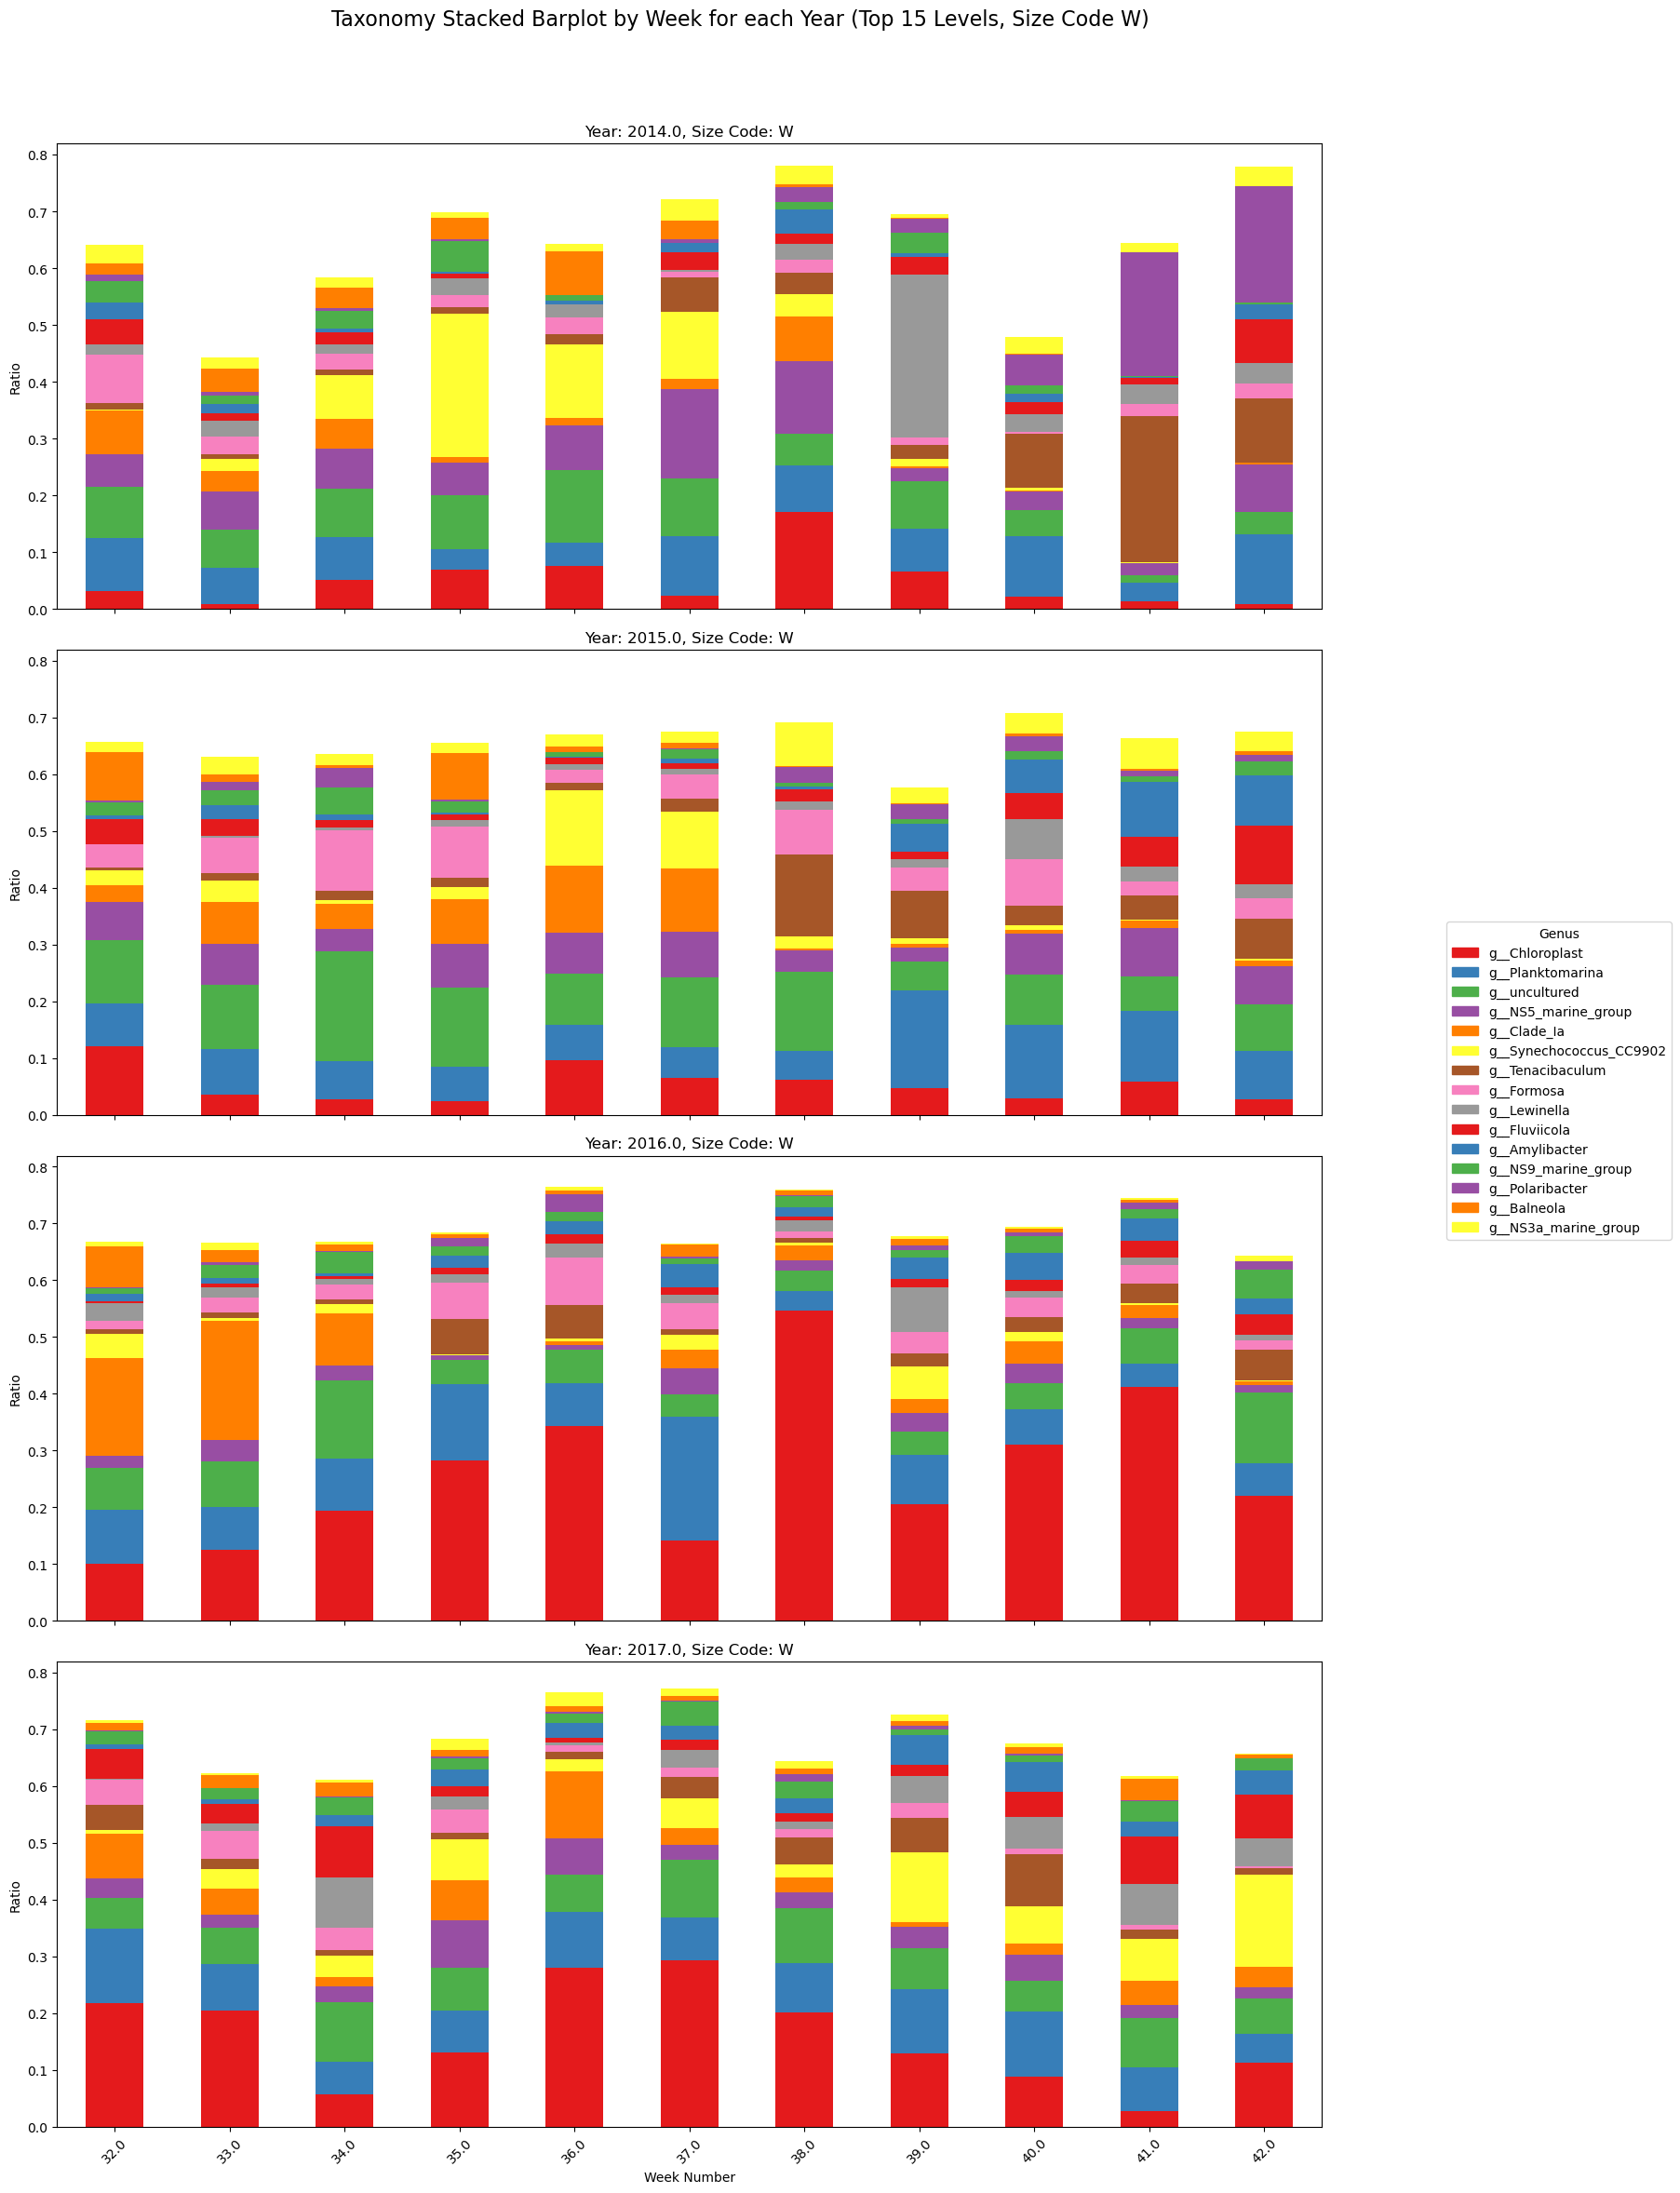

In [161]:
copy_of2 = copy_of[copy_of.weekn > 31]
copy_of2 = copy_of2[copy_of2.weekn < 43]

plot_taxonomy_barplot_by_year_w(copy_of2, 'Genus', 5, topn=15, show_other=False)

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_taxonomy_barplot_by_year_w(df, level, depth='all', topn=10, show_other=True):
    """
    For a given DataFrame, plots a stacked barplot time series for each year,
    for size_code "W" only.
    
    The x-axis is the week number (weekn) and the y-axis is the summed ratio.
    The bars are stacked by taxonomy level given by the column `level`.
    
    The top `topn` most abundant taxonomy levels are determined across ALL years,
    ensuring a consistent color mapping across the subplots. Taxonomy levels not in the topn
    are either aggregated into an "Other" category (if show_other=True) or dropped.
    
    Parameters:
      df (pd.DataFrame): Data containing at least the columns:
                         - weekn: week number (x-axis)
                         - ratio: relative abundance value for the feature
                         - size_code: will be filtered to "W"
                         - depth: for filtering (if depth != 'all')
                         - year: the year of the sample
                         - level: the taxonomy identification column to use as stacking hue.
      level (str): The name of the column in df that holds the taxonomy level.
      depth (str/int, optional): If not 'all', filters the data to only rows with this depth.
      topn (int, optional): The number of top taxonomy levels (by overall summed ratio) to display.
      show_other (bool, optional): If True, groups taxonomy levels not in the topn as "Other".
    """
    # Filter by depth if necessary.
    if depth != 'all':
        df = df[df['depth'] == depth]
    
    # Keep only size_code "W"
    df = df[df['size_code'] == 'W']
    
    # Determine overall top taxonomy levels (across all years)
    overall = df.groupby(level)['ratio'].sum().reset_index()
    overall = overall.sort_values(by='ratio', ascending=False).reset_index(drop=True)
    top_categories = overall[level].head(topn).tolist()
    
    # If including "Other", add that to our list of categories.
    categories = top_categories.copy()
    if show_other:
        categories.append("Other")
    
    # Set a consistent high-contrast color palette.
    palette = sns.color_palette("Set1", len(categories))
    palette_dict = dict(zip(categories, palette))
    
    # Determine unique years (sorted)
    years = sorted(df['year'].unique())
    
    # Create a figure with rows = number of years and 1 column (for size_code "W")
    n_years = len(years)
    fig, axes = plt.subplots(n_years, 1, figsize=(16, 6 * n_years), sharex=True, sharey=True)
    if n_years == 1:
        axes = [axes]
    
    for i, year in enumerate(years):
        ax = axes[i]
        
        # Filter data for the specific year
        df_subset = df[df['year'] == year]
        
        # Group by week number and taxonomy level, summing the ratio values.
        grouped = df_subset.groupby(['weekn', level])['ratio'].sum().reset_index()
        
        # If show_other, reassign taxonomy levels not in top_categories to "Other"
        if show_other:
            grouped[level] = grouped[level].apply(lambda x: x if x in top_categories else "Other")
        else:
            grouped = grouped[grouped[level].isin(top_categories)]
        
        # Re-group in case multiple rows now have the same taxonomy (e.g. "Other")
        grouped = grouped.groupby(['weekn', level])['ratio'].sum().reset_index()
        
        # Pivot the data: rows are weekn, columns are taxonomy levels
        pivoted = grouped.pivot(index='weekn', columns=level, values='ratio').fillna(0)
        # Ensure all desired categories are present
        for cat in categories:
            if cat not in pivoted.columns:
                pivoted[cat] = 0
        pivoted = pivoted[categories]
        pivoted = pivoted.sort_index()  # sort rows by week number
        
        # Plot the stacked barplot.
        pivoted.plot(kind='bar', stacked=True, ax=ax, 
                     color=[palette_dict[c] for c in pivoted.columns], legend=False)
        ax.set_title(f"Year: {year}, Size Code: W")
        ax.set_xlabel("Week Number")
        ax.set_ylabel("Ratio")
        # Let matplotlib use the default x-axis tick positions but rotate the labels.
        ax.set_xticklabels(pivoted.index.astype(str), rotation=45)
    
    # Create a common legend outside the subplots.
    handles = [plt.Rectangle((0,0),1,1, color=palette_dict[cat]) for cat in categories]
    fig.legend(handles, categories, title=level, bbox_to_anchor=(1.05, 0.5), loc='center')
    
    plt.suptitle(f"Taxonomy Stacked Barplot by Week for each Year (Top {topn} Levels, Size Code W)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.savefig('taxonomy_stacked_barplot_by_year.png', bbox_inches='tight')
    plt.show()

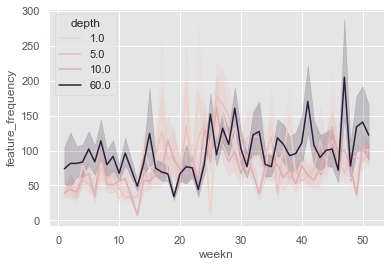

In [76]:
sns.lineplot(x = "weekn", y = "feature_frequency", data=y2016, hue="depth")
plt.show()

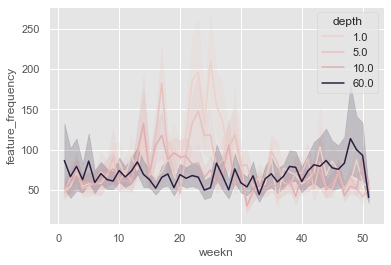

In [77]:
sns.lineplot(x = "weekn", y = "feature_frequency", data=y2017, hue="depth")
plt.show()

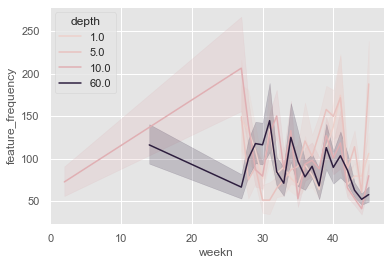

In [78]:
sns.lineplot(x = "weekn", y = "feature_frequency", data=y2018, hue="depth")
plt.show()

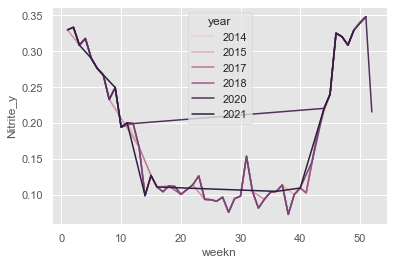

In [628]:
sns.lineplot(x = "weekn", y = "Nitrite_y", data=nitriteonly, hue="year")
plt.show()

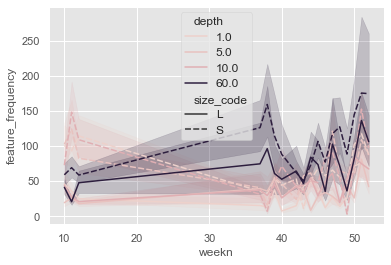

In [80]:
sns.lineplot(x = "weekn", y = "feature_frequency", data=y2020, hue="depth", style="size_code")
plt.show()

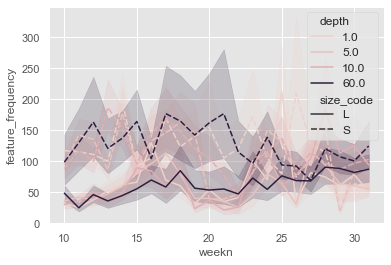

In [81]:
sns.lineplot(x = "weekn", y = "feature_frequency", data=y2021, hue="depth", style="size_code")
plt.show()

In [44]:
copy_of['feature_count'] = (
    copy_of.groupby(["sampleid"])['feature_id'].transform('nunique'))

In [261]:
plotadiv = copy_of[['sampleid', 'feature_count', 'year', 'weekn', 'size_code', 'depth']].copy()

In [84]:
sns.lineplot(x = "weekn", y = "feature_count", data=nonulladiv, style="year")
plt.show()

NameError: name 'nonulladiv' is not defined

In [262]:
null = plotadiv.loc[plotadiv['feature_count'] == 0]

In [263]:
null = null[['year','weekn','size_code','depth']].copy()

In [264]:
null = null.drop_duplicates()

In [265]:
null = null.reset_index(drop=True)

In [266]:
null.to_csv('missingsamples.csv', index=False)

In [267]:
notsizefractionated = plotadiv.loc[plotadiv['year'] < 2018]

In [268]:
sizefractionated = plotadiv.loc[plotadiv['year'] >= 2018]

In [269]:
nullnsf = notsizefractionated.loc[notsizefractionated['feature_count'] == 0]
nullnsf = nullnsf.drop_duplicates()

In [270]:
nullnsf

,sampleid,feature_count,year,weekn,size_code,depth
712495,BB14.47A,0,2014.0,47.0,NaN,1.0
712497,BB14.47B,0,2014.0,47.0,NaN,5.0
712499,BB17.28B,0,2017.0,28.0,NaN,5.0
713775,BB16.12A,0,2016.0,12.0,NaN,1.0
713776,BB16.12B,0,2016.0,12.0,NaN,5.0
713777,BB16.12C,0,2016.0,12.0,NaN,10.0
713778,BB16.12D,0,2016.0,12.0,NaN,60.0


In [271]:
nullsf = sizefractionated.loc[sizefractionated['feature_count'] == 0]
nullsf = nullsf.drop_duplicates()

In [637]:
nullsf

,sampleid,feature_count,year,weekn,size_code,depth
712501,BB19.2AL,0,2019.0,2.0,L,1.0
712503,BB19.2AS,0,2019.0,2.0,S,1.0
712505,BB19.2BL,0,2019.0,2.0,L,5.0
712507,BB19.2BS,0,2019.0,2.0,S,5.0
712509,BB19.2CL,0,2019.0,2.0,L,10.0
...,...,...,...,...,...,...
713765,BB18.51BS,0,2018.0,51.0,S,5.0
713767,BB18.51CL,0,2018.0,51.0,L,10.0
713769,BB18.51CS,0,2018.0,51.0,S,10.0
713771,BB18.51DL,0,2018.0,51.0,L,60.0


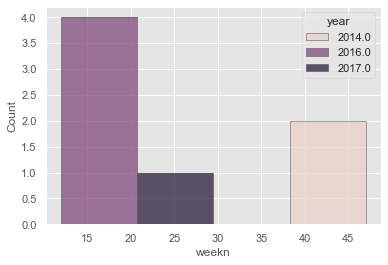

In [272]:
sns.histplot(
    nullnsf,
    x="weekn", hue="year",
    multiple="stack",
    #palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
)
plt.savefig('figures/missingsamplesNSF.png', format="png")

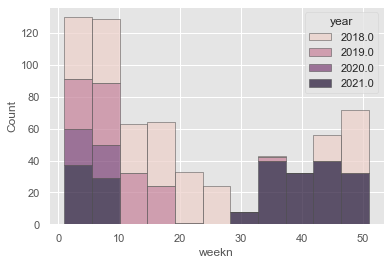

In [273]:
sns.histplot(
    nullsf,
    x="weekn", hue="year",
    multiple="stack",
    #palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
)
plt.savefig('figures/missingsamplesSF.png', format="png")

In [271]:
nonulladiv = plotadiv.loc[plotadiv['feature_count'] != 0]

In [99]:
month_dic = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

year_dic = {
    2014: "Y2014",
    2015: "Y2015",
    2016: "Y2016",
    2017: "Y2017",
    2018: "Y2018",
    2019: "Y2019",
    2020: "Y2020",
    2021: "Y2021",
}

month_season = {
    "Jan": "Winter",
    "Feb": "Winter",
    "Mar": "Spring",
    "Apr": "Spring",
    "May": "Spring",
    "Jun": "Summer",
    "Jul": "Summer",
    "Aug": "Summer",
    "Sep": "Autumn",
    "Oct": "Autumn",
    "Nov": "Autumn",
    "Dec": "Winter"
}

In [88]:
tst = newseparated[newseparated['year'] < 2023]
copy_of = tst.copy()
copy_of[['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']] = copy_of['Taxon'].str.split('; ', expand=True)

NameError: name 'newseparated' is not defined

In [197]:
subyrs = copy_of.loc[copy_of['depth'] != 60 ]

In [198]:
allyears_tax = subyrs[['feature_id', 'Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']].copy()
allyears_tax = allyears_tax.drop_duplicates()
allyears_tax = allyears_tax.rename(columns={'feature_id': "Seq_id"})
allyears_tax.set_index('Seq_id', inplace=True)
allyears_tax["Sequence"] = "ATCGG"

In [199]:
allyears_tax.to_csv('allyears_tax_1417.csv', index_label='Seq_id')

In [200]:
allyears = subyrs[['sampleid','feature_id','feature_frequency']].copy()
allyears = allyears.drop_duplicates()
allyears= allyears.pivot(index='sampleid', columns='feature_id', values='feature_frequency')
allyears=allyears.fillna(0)
allyears = allyears.iloc[: , 1:]
allyears.to_csv('subyears_tables1417.csv', index_label='sampleid')

In [201]:
numerical_columns = [c for c in allyears.columns if allyears[c].dtype.name != 'object']

allyears[allyears[numerical_columns] < 0].values.any()

True

In [202]:
#subyrs.set_index('sampleid', inplace=True)
subyrs_env = subyrs.copy()
subyrs_env = subyrs.drop(columns=['feature_id', 'feature_frequency'])
                                              #,'Taxon', 'Confidence', 'Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species'])
subyrs_env = subyrs_env.drop_duplicates()

In [212]:
#some samples contain duplicates because two scans were done; groupby sample and keep mean
subyrs_env = subyrs_env.groupby(by=["sampleid"]).mean()
#forward fill missing values
subyrs_env = subyrs_env.fillna(method='ffill')

#add month number
subyrs_env['month_name'] = subyrs_env['month'].map(month_dic)

#add year number
subyrs_env['year_name'] = subyrs_env['year'].map(year_dic)

#make a season column
subyrs_env['season'] = subyrs_env['month_name'].map(month_season)


subyrs_env = subyrs_env.dropna(axis=1, how='all')
subyrs_env.to_csv('env_data_deep1417.csv', index_label='sampleid')


/var/folders/kv/yq6jygk116l27q2bwnk25k0w0000gn/T/ipykernel_49699/1300638716.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  subyrs_env = subyrs_env.groupby(by=["sampleid"]).mean()


In [206]:
envindex = allyearshallow.index.tolist()

NameError: name 'allyearshallow' is not defined

In [703]:
speindex = allyears.index.tolist()

In [704]:
temp3 = []
for element in envindex:
    if element not in speindex:
        temp3.append(element)
print(temp3)

[]


In [705]:
temp3 = []
for element in speindex:
    if element not in envindex:
        temp3.append(element)
print(temp3)

[]


In [829]:
allyearshallow["ratio_fid"] = allyearshallow["feature_frequency"] / allyearshallow["feature_count"]

In [830]:
allyearshallown19 = allyearshallow.loc[allyearshallow['year'] != 2019]

In [831]:
allyearshallow = allyearshallow[allyearshallow['ratio_fid'].notna()]

In [832]:
allyearshallow19 = allyearshallow.loc[allyearshallow['year'] == 2019]

In [833]:
allyearshallow19 = allyearshallow19[allyearshallow19['ratio_fid'].notna()]

In [834]:
top14 = allyearshallow.loc[allyearshallow['year'] == 2014]
top14 = top14.nlargest(5, "ratio_fid")

In [835]:
top15 = allyearshallow.loc[allyearshallow['year'] == 2015]
top15 = top15.nlargest(5, "ratio_fid")

In [836]:
top16 = allyearshallow.loc[allyearshallow['year'] == 2016]
top16 = top16.nlargest(5, "ratio_fid")

In [837]:
top17 = allyearshallow.loc[allyearshallow['year'] == 2017]
top17 = top17.nlargest(5, "ratio_fid")

In [838]:
top18 = allyearshallow.loc[allyearshallow['year'] == 2018]
top18 = top18.nlargest(5, "ratio_fid")

In [839]:
top19 = allyearshallow.loc[allyearshallow['year'] == 2019]
top19 = top19.nlargest(5, "ratio_fid")

In [840]:
top20 = allyearshallow.loc[allyearshallow['year'] == 2020]
top20 = top20.nlargest(5, "ratio_fid")

In [841]:
top21 = allyearshallow.loc[allyearshallow['year'] == 2021]
top21 = top21.nlargest(5, "ratio_fid")

In [842]:
result = pd.concat([top14, top15, top16, top17, top18, top19, top20, top21], axis=0)

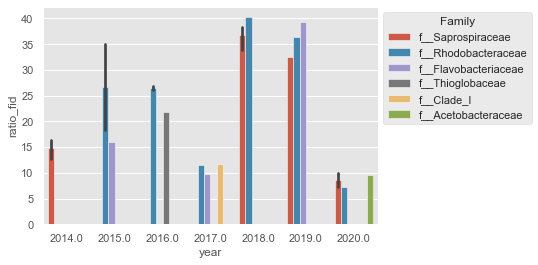

In [845]:
ax=sns.barplot(x = 'year', y = 'ratio_fid', hue = 'Family', data = result,
            edgecolor = 'w')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.show()

In [820]:
result

,feature_id,feature_frequency,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elutin_volume,nifH,MetaG,new_id,notes,elution_volume,Unnamed: 15,16S V6V8\nIMR #,Notes,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,size_code,IMR # - V4V5,IMR # - 18S,Elution volume,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,[DNA]ng/ul,Freezer Box (1.5mL),Filtration Volume (DNA),sample_code,month_name,month,day,time_string_x,time_string_y,julian_day,scan,temperature,conductivity,oxygenVoltage,fluorescence,unknown,pH,PSAR,salinity,theta,sigmaTheta,oxygen,scan2,fluorescence2,turbidity,oxygenCurrent,oxygenTemperature,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,bbmpdepth,fluorometer,par,flagArchaic,time_string_time,season,mission_descriptor,event_id,sample_id,latitude,longitude,time,Chlorophyll A,Nitrate,Nitrite,Phosphate,Silicate,Ammonia,Salinity,Temperature,HPLC_ALLOX,HPLC_BUT19,HPLC_CHLA,HPLC_CHLB,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON,time_string,Taxon,Confidence,feature_count,Domain,Phylum,Class,Order,Family,Genus,Species,avgNitrite,ratio_fid
sampleid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
BB14.39D,f75a7ff2740c7af21f310955d1fe0528,1396.0,2014.0,24-Sep,39.0,60.0,D,09.24.60m,30.2,1.68,Jan 23 2015,NaN,yes,NaN,50.0,NaN,NaN,BB14.39D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sep,9.0,24.0,2014-09-24,2014-09-24,267.0,3135.0,3.9197,0.683671,1.2738,1.7451,0.035409,NaN,0.00357,31.2441,NaN,24.8075,2.91527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-09-24 12:25:45,Autumn,18VA14667,40.0,391108.0,44.6917,-63.6417,1230.0,0.24,10.30,0.21,2.14,22.80,11.92,31.24,3.92,0.0,0.0,0.248,0.0,0.024,0.0,0.0,0.0,0.148,0.0,0.0,0.0,196.1,44.1,2014-09-24,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.999996,192,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Thiomicrospirales,f__Thioglobaceae,None,None,NaN,7.270833
BB14.39D,f75a7ff2740c7af21f310955d1fe0528,1396.0,2014.0,24-Sep,39.0,60.0,D,09.24.60m,30.2,1.68,Jan 23 2015,NaN,yes,NaN,50.0,NaN,NaN,BB14.39D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sep,9.0,24.0,2014-09-24,2014-09-24,267.0,3151.0,3.9166,0.683624,1.2652,1.8573,0.035409,NaN,0.00354,31.2445,NaN,24.8082,2.88786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-09-24 12:25:45,Autumn,18VA14667,40.0,391108.0,44.6917,-63.6417,1230.0,0.24,10.30,0.21,2.14,22.80,11.92,31.24,3.92,0.0,0.0,0.248,0.0,0.024,0.0,0.0,0.0,0.148,0.0,0.0,0.0,196.1,44.1,2014-09-24,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.999996,192,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Thiomicrospirales,f__Thioglobaceae,None,None,NaN,7.270833
BB14.36D,f75a7ff2740c7af21f310955d1fe0528,1505.0,2014.0,03-Sep,36.0,60.0,D,09.03.60m,32.4,1.76,Jan 23 2015,NaN,yes,NaN,50.0,NaN,NaN,BB14.36D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sep,9.0,3.0,2014-09-03,2014-09-03,246.0,3139.0,3.8709,0.682412,1.4657,1.6318,0.195360,NaN,0.00504,31.2272,NaN,24.7986,3.64334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-09-03 12:10:53,Autumn,18VA14667,37.0,391096.0,44.6917,-63.6417,1230.0,0.05,6.11,0.16,1.79,17.48,13.22,31.23,3.87,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,203.9,30.2,2014-09-03,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.999996,222,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Thiomicrospirales,f__Thioglobaceae,None,None,NaN,6.779279
BB14.36D,f75a7ff2740c7af21f310955d1fe0528,1505.0,2014.0,03-Sep,36.0,60.0,D,09.03.60m,32.4,1.76,Jan 23 2015,NaN,yes,NaN,50.0,NaN,NaN,BB14.36D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sep,9.0,3.0,2014-09-03,2014-09-03,246.0,3144.0,3.8699,0.682408,1.4614,1.6348,0.195360,NaN,0.00498,31.2276,NaN,

In [706]:
allyearsclr=allyears.mask(allyears==0).fillna(0.1)

In [707]:
clr_transformed_array = clr(allyearsclr)

In [708]:
clr_transformed_array

array([[-8.05590767e-01, -8.05590767e-01,  2.59560661e+00, ...,
         4.13605166e+00,  5.85370315e+00, -8.05590767e-01],
       [-5.89812746e-01, -5.89812746e-01, -5.89812746e-01, ...,
         3.90999692e+00,  5.90242709e+00, -5.89812746e-01],
       [-6.07335466e-01, -6.07335466e-01, -6.07335466e-01, ...,
         3.48700910e+00,  6.01273774e+00, -6.07335466e-01],
       ...,
       [ 7.37188088e-14,  7.37188088e-14,  7.37188088e-14, ...,
         7.37188088e-14,  7.37188088e-14,  7.37188088e-14],
       [ 7.37188088e-14,  7.37188088e-14,  7.37188088e-14, ...,
         7.37188088e-14,  7.37188088e-14,  7.37188088e-14],
       [ 7.37188088e-14,  7.37188088e-14,  7.37188088e-14, ...,
         7.37188088e-14,  7.37188088e-14,  7.37188088e-14]])

In [709]:
samples = allyears.index
asvs = allyears.columns

In [710]:
#Creating the dataframe with the clr transformed data, and assigning the sample names
clr_transformed = pd.DataFrame(clr_transformed_array, columns=asvs)
#Assigning the asv names
clr_transformed['samples'] = samples
clr_transformed = clr_transformed.set_index('samples')
clr_transformed.head()

feature_id,NaN,0089c2ee62e4e072faf4a080fc7ae6e5,009cdbab8ec4e73afa9896e976ef4e79,009d9d9ead2108df09af45f158e22a07,00aeb9935a435b49b026a1964d2f6b47,00eeb15cbf500c183a320d691e8c86ef,00f2a771e4a04d01f8d178357421ece7,012054e3f62502aff7f455e1592ea87f,0165a2c1fe84bd598d03ee6fe4053302,0184b0e8cdfb040dfd7e1d74c2cdc76e,01893a6e745b291e28f8105c359b0f64,01b6055d816dfa26f1049780d85de084,01cc2516697cf1b59d3bdcdc881c233e,01fa3b737249108b1250d0a9266a509f,023afc3a991fd3d034caa37683e1b7c0,02400e0e16a5e834a5a3f4b3ea27dc25,02541fa082aa960dbf17e925a5bb585d,0257df5ce232ff8a46974cb959347ab4,029ad2e1900c4019bd98d0e96b51a1a2,02dd2eb5fefdc3d770b2d8cb56eb93ec,030056fbfcc7a9cacf6f4807bfc230a4,03950159fe40a71393ac6ccf58fa043b,03d2215b2efa460596cf9cec58880bd7,045c0f99a190b3077144f5a67f78a464,0468e92c5c09d0692db64d5611fa1b28,0474303ad3962c3705e794cc3d3c7191,047bc5d9acd6864d3e7cbaf477d546ff,04a5fbaf45fdd7252cd9e341080587b1,04eb36b8ca8b96a4035d3ec9c00e68ca,04f5c18fd5bd6486b3afa7374a05da41,05657e5b521fae07ef6f79724d757d28,058ba20bd286bb5d7d5dd5b406ec2629,058f90cda0a4f438dbaf12d015479658,05b1a3ab2aede05c0794a9a83eb5a936,063669beab0e471ace7cbc32283416e9,065f718c0519522661f2d3b088f3bdee,0663ade4d06e30955491ebeae3b9fe19,069ca833ef795ebab246ff094294a469,06a02c8a852b27651ddef23c4174e201,06ad8aee2710d4b77d4121a90e32bfb7,06b38c9c1b4191b8a7cb9d3b4e5aa40a,06bdf879d93fb0333bb7b293bcf46f13,06e148ad8b35489ea97e51ef733e9550,071539b5d2f8e1d990035f66c9f1fb0f,072427541158f9d9069b174f85df2bb3,073264e8c93a3016c046da55cb5108da,078a8a33ce85c03b25fb72836154186c,079371fb8cd7f51322f235bee045e597,07aaa77ecf15feb1425c3214f44f3695,07e3e10aaa3b805f430c20c394809d36,081137d110528eb47e413d73a6e3b465,083fcf2bd04f2655663b1cebb52587a4,085108636a561ad2068b45ee0d4a31c6,09304de7bcdde93714df6d4800a79b4d,095f506aff47f43e50e676e191eac1a4,09613b4b43c0225c13341b0c4443be0d,098c1fbc4f031d5301da9de0c1c03334,09c0f213f49fb5614b5e425b7bc6773c,09c3927def334db6037c4bacbd0f2d80,09cc5b082b694c6970886bf880ddd4a8,09da3b40a627352f42a793ffb54eb717,09e32a6a1dc6e73574eb4fe9aa97ab16,09e5d0b4850f164f5082607c4ad9d2c5,0a5ed449b951b0eb720dd65b6f14ab13,0a635599e3a612b93fef9bf232b5f23a,0a76d6cab7c1fdeabbb54395126ece87,0a9279c90eebccdbc34c1a9f4eeb1c90,0a989001152cacd0ca9d30956f4147dd,0abb6666e8f0d09f0ce54c11ed157a2f,0afd07cb82a0cd28986028ae75770f54,0b1a69704b0bd4489b13ca4b25b54625,0b1bfe440f3f65f8fb4fc67df90ae491,0b32c57485134932672e134f70e73146,0b6782c4d3dd0a3ab732b07d5ab2ad77,0b8391d871ea3d2277a2b64898f128e0,0b94d72b8f3d8d19db558b7c1efd7d18,0b95feee5c93b0e3ad04838407a82f2f,0bd2e49490c2c51a5094fef0a3ac86e7,0bd9b74b7d3eaa527689e20ed5fc0c51,0be352e4ad0d1f057122f22fc3a0f881,0bea3033f14213b6d3feafe3f55abe99,0c199136f18941871ff2ee329b91c0f5,0c1dbbcfbd6728c4e7f42bc15cdc708e,0c9b9e6bc2762d9dd5a4a72a29b4af24,0cc11497326c22546a1ba76411aea7d2,0cdd9489f2c9fe5c69287aa29f528299,0d22b7e4a1259d36db15ecf563f64057,0d5b6246eedeb38a2b5ef518d8f7d391,0d754b3546373fe64021cd1d8957fa91,0d780823469dde894b24db3f3df9e691,0dc6a4375723cbc6fd3b2b00109ebe3b,0e1ecf529a93e4ecf3288da68e9ab5dc,0e46659798f4871df8791ea441a88a9c,0e895b87ddf34c80a4bba6946b6e8d19,0eb92aee8dc1aee8c06d69ec40031532,0ec645edd5936fd4c1e08dee1eb8ac60,0ee0f80a6f4976347065a2ffce27e43d,0f1363e179a5c586d8ea68dfb8a8fc55,0f1f38c283f1d2f90e82cbc24e732cc7,0f33673415ff64433fc7ddac5adde101,0f6b6c63ffd11c2f72d06547917dfe21,0f7dbda5f7a8b8bcc239a630a72bb756,0f884dfb9df92cf2aad15aecedfe400a,0f90b77a10e5cae78cfc235d73e3baf4,0f9c516a82ac12504c4d599be2a2b0cc,0fe890bd7ebec6b65c545aee811511d2,105a47b838dd3b8be822ed19c7797de0,1087fa1066bc092b4ee546edb82b1f97,10899a605efd82161879a1fca53a2525,10937812a8cd1af330124b28d002884c,10aa8d6cc26407576105b7d1c55f98e2,10c1505057978d9eeda3a3e105d2ca49,10d68ea1eb2ad4555de8850c8fae11a2,10e020b52b629407523b12cdadc78d07,11138f1b96ef5d366120d45513b51d09,1114a40b39115a11a8579dca770120b4,1152ad9aa494373443828664c73d193e,1169e4a9b8791b0ba26c062c610fed24,117fa6de7cc050a7c74bc86871a774c8,119ebfc49e2c98ea4cc8c4a0490d082d,1211cca5188f5f2d0361d6b625d32594,127474fea69921beca663aa9c

In [711]:
dist = cdist(clr_transformed, clr_transformed, 'euclid')

In [712]:
distance_matrix = pd.DataFrame(dist, columns=samples)

In [713]:
distance_matrix['samples'] = samples
distance_matrix = distance_matrix.set_index('samples')
distance_matrix

sampleid,BB14.36D,BB14.37D,BB14.38D,BB14.39D,BB15.36D,BB15.37D,BB15.38D,BB15.39D,BB15.40D,BB16.36D,BB16.37D,BB16.38D,BB16.39D,BB17.36D,BB17.37D,BB17.38D,BB17.39D,BB18.36DL,BB18.36DS,BB18.37DL,BB18.37DS,BB18.38DL,BB18.38DS,BB18.39DL,BB18.39DS,BB19.a36DL,BB19.a36DS,BB19.a37DL,BB19.a37DS,BB19.a38DL,BB19.a38DS,BB19.a39DL,BB19.a39DS,BB20.37DL,BB20.37DS,BB20.38DL,BB20.38DS,BB20.39DL,BB20.39DS,BB21.35DL,BB21.35DS,BB21.36DL,BB21.36DS,BB21.37DL,BB21.37DS,BB21.38DL,BB21.38DS,BB21.39DL,BB21.39DS
samples,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
BB14.36D,0.000000,48.201620,53.924475,50.347195,70.933604,67.360594,73.381418,67.365657,69.485314,85.141720,82.561766,110.377715,80.835585,63.819468,67.207707,67.690898,68.272853,94.879044,78.962417,106.119442,83.327101,86.918160,80.005405,99.764284,90.472187,85.088213,91.300018,86.809416,75.781569,81.364781,82.243695,93.548526,80.063083,79.561991,87.460674,80.714954,87.727184,80.694463,77.638617,78.021219,78.021219,78.021219,78.021219,78.021219,78.021219,78.021219,78.021219,78.021219,78.021219
BB14.37D,48.201620,0.000000,44.056860,49.822928,69.928545,65.393425,74.699149,66.878384,70.550716,86.407873,81.354582,104.497644,78.627069,60.174931,63.554652,65.951782,65.263194,88.202360,75.323281,98.992709,78.941038,78.361486,75.693036,92.954214,88.136394,77.506707,89.354276,79.458861,72.709690,72.524165,79.126082,87.561555,76.989405,69.572146,85.245070,70.584382,87.335845,70.492844,72.408729,67.181131,67.181131,67.181131,67.181131,67.181131,67.181131,67.181131,67.181131,67.181131,67.181131
BB14.38D,53.924475,44.056860,0.000000,49.671468,73.145295,67.590687,77.361338,67.070264,71.443380,88.495106,80.829955,105.229627,76.378198,60.035808,62.894825,67.028482,64.789727,89.941919,75.368807,101.075766,79.648405,80.188614,74.730658,93.998338,86.269500,79.626360,91.691934,80.106851,74.377312,74.222077,77.717515,87.775682,75.811900,71.221481,85.427817,72.175894,87.249885,71.704792,72.247540,67.185526,67.185526,67.185526,67.185526,67.185526,67.185526,67.185526,67.185526,67.185526,67.185526
BB14.39D,50.347195,49.822928,49.671468,0.000000,73.001870,67.588454,75.578201,67.335381,71.178213,87.683319,82.330784,107.433525,78.861593,62.704139,64.953594,66.253734,65.618604,88.586949,74.253893,100.869532,78.057704,81.971794,72.605825,94.989938,84.505689,83.760116,91.032011,84.048675,73.636240,78.122973,77.409034,90.633928,75.420441,75.465228,83.942000,75.598280,84.352434,75.435049,71.517493,71.112142,71.112142,71.112142,71.112142,71.112142,71.112142,71.112142,71.112142,71.112142,71.112142
BB15.36D,70.933604,69.928545,73.145295,73.001870,0.000000,47.136519,54.138029,55.155588,56.131323,88.830136,85.097385,115.801638,85.981687,68.596276,68.652225,71.923707,72.045940,100.724991,88.052043,107.821090,91.188823,92.812936,89.453570,104.634108,98.110746,83.575413,85.892908,83.369663,73.069583,81.509831,79.204732,91.469484,79.900823,84.421528,91.213335,84.833884,92.715843,84.874428,83.354403,83.330680,83.330680,83.330680,83.330680,83.330680,83.330680,83.330680,83.330680,83.330680,83.330680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BB21.37DS,78.021219,67.181131,67.185526,71.112142,83.330680,74.712453,92.921778,79.548075,85.203690,104.599098,98.357179,82.895510,89.041090,71.364064,77.443062,80.740723,80.238110,94.035413,84.839694,106.196304,89.554162,80.272462,83.560922,96.389870,96.230665,70.660934,102.542292,72.723375,81.294430,62.927850,87.837405,83.026769,85.037673,62.752231,98.469101,62.241325,101.221600,63.733336,84.392766,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BB21.38DL,78.021219,67.181131,67.185526,71.112142,83.330680,74.712453,92.921778,79.548075,85.203690,104.599098,98.357179,82.895510,89.041090,71.364064,77.443062,80.740723,80.238110,94.035413,84.839694,106.196304,89.554162,80.272462,83.560922,96.389870,96.230

In [714]:
dm = DistanceMatrix(distance_matrix)

In [715]:
permanova(dm, grouping=allyearshallow['year'])

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      49
number of groups                  8
test statistic              6.65812
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

In [378]:
permanova(dm, grouping=allyearshallow['Nitrite'])

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     147
number of groups                 39
test statistic              2.99059
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

In [668]:
from skbio.stats.composition import ancom

In [748]:
results = ancom(table=allyearsclr, grouping=allyearshallow[''])

KeyError: ''

In [447]:
prcentile = results[1].copy()

In [458]:
prcentile.loc[prcentile.index == '63217d9e37eb5bb8f5fa7d4db44be83b']

Percentile,0.0,25.0,50.0,75.0,100.0,0.0,25.0,50.0,75.0,100.0,0.0,25.0,50.0,75.0,100.0,0.0,25.0,50.0,75.0,100.0,0.0,25.0,50.0,75.0,100.0,0.0,25.0,50.0,75.0,100.0,0.0,25.0,50.0,75.0,100.0,0.0,25.0,50.0,75.0,100.0
Group,2014.0,2014.0,2014.0,2014.0,2014.0,2015.0,2015.0,2015.0,2015.0,2015.0,2016.0,2016.0,2016.0,2016.0,2016.0,2017.0,2017.0,2017.0,2017.0,2017.0,2018.0,2018.0,2018.0,2018.0,2018.0,2019.0,2019.0,2019.0,2019.0,2019.0,2020.0,2020.0,2020.0,2020.0,2020.0,2021.0,2021.0,2021.0,2021.0,2021.0
feature_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
63217d9e37eb5bb8f5fa7d4db44be83b,0.1,5.0,8.5,12.5,17.0,0.1,0.1,6.0,39.5,75.0,0.1,0.1,0.1,0.1,6.0,0.1,0.1,7.0,15.0,46.0,0.1,0.1,0.1,0.1,5.0,0.1,0.1,0.1,4.0,148.0,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


In [421]:
DAresults = results[0].copy()

In [427]:
DARejected_year = DAresults.loc[DAresults['Reject null hypothesis'] == True]

In [429]:
DARejected_year.sort_values(by=['W'])

,W,Reject null hypothesis
feature_id,,
5fa40eb87d55617c98c558c643cb82c0,1907,True
69576d8f19b866f77dbadceee0b832ea,1907,True
477eee2050e9247b814ff1e5dec2606e,1910,True
cbd760b8de17653b0ed58b7cff210747,1915,True
f46cb1174a6b592c7ec867038be75e72,1915,True
...,...,...
b9dfa48a9153a4f020c093740c3e80bf,2241,True
63217d9e37eb5bb8f5fa7d4db44be83b,2241,True
195fa447e7f4d01d4c1a0d0d7fbf085d,2241,True


In [442]:
taxonomy = copy_of[['feature_id', 'Confidence', 'Taxon', 'Phylum', 'Class', 'Family', 'Genus', 'Species']].copy()

In [443]:
taxonomy = taxonomy.drop_duplicates()

In [444]:
DARejected_year_taxonomy = pd.merge(DARejected_year, taxonomy, on="feature_id", how="left")

In [445]:
DARejected_year_taxonomy.sort_values(by='W')

,feature_id,W,Reject null hypothesis,Confidence,Taxon,Phylum,Class,Family,Genus,Species
162,5fa40eb87d55617c98c558c643cb82c0,1907,True,0.940012,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,p__Proteobacteria,c__Gammaproteobacteria,f__Spongiibacteraceae,g__BD1-7_clade,s__uncultured_gamma
174,69576d8f19b866f77dbadceee0b832ea,1907,True,0.947180,d__Bacteria,None,None,None,None,None
116,477eee2050e9247b814ff1e5dec2606e,1910,True,0.794033,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,p__Proteobacteria,c__Alphaproteobacteria,f__Rhodobacteraceae,g__Planktotalea,None
339,cbd760b8de17653b0ed58b7cff210747,1915,True,0.949636,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,p__Proteobacteria,c__Gammaproteobacteria,f__Halieaceae,g__Congregibacter,None
398,f46cb1174a6b592c7ec867038be75e72,1915,True,0.995234,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,p__Bacteroidota,c__Bacteroidia,f__Cyclobacteriaceae,g__Marinoscillum,s__Marinoscillum_luteum
...,...,...,...,...,...,...,...,...,...,...
307,b9dfa48a9153a4f020c093740c3e80bf,2241,True,0.998950,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,p__Bacteroidota,c__Bacteroidia,f__Flavobacteriaceae,g__NS5_marine_group,None
165,63217d9e37eb5bb8f5fa7d4db44be83b,2241,True,0.999913,d__Bacteria; p__Actinobacteriota; c__Actinobac...,p__Actinobacteriota,c__Actinobacteria,f__Microbacteriaceae,g__Candidatus_Aquiluna,None
43,195fa447e7f4d01d4c1a0d0d7fbf085d,2241,True,1.000000,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,p__Bacteroidota,c__Bacteroidia,f__Saprospiraceae,g__Saprospira,s__uncultured_bacterium
226,871bca12eb637e0efe230a554913d755,2241,True,0.887595,d__Bacteria; p__Cyanobacteria; c__Cyanobacteri...,p__Cyanobacteria,c__Cyanobacteriia,f__Cyanobiaceae,g__Synechococcus_CC9902,None


In [496]:
copy_of['avgNitrite'] = (
    copy_of.groupby(["weekn"])['Nitrite'].mean())

In [487]:
allyearshallow = allyearshallow.sort_values('sampleid')

In [488]:
allyearshallow['weektotaln'] = np.arange(allyearshallow.shape[0])

In [489]:
allyearshallow[ '4WksRollAv' ] = allyearshallow.Nitrite.rolling(4).mean()

In [ ]:
df[“Error”] = df[“Forecast”] — df[“Demand”]
m = df[“Error”].mean()
s = df[“Error”].std()
from scipy.stats import norm
limit_high = norm.ppf(0.99,m,s)+df[“Forecast”]
limit_low = norm.ppf(0.01,m,s)+df[“Forecast”]
df[“Updated”] = df[“Demand”].clip(lower=limit_low,upper=limit_high)
print(df)

In [718]:
preall_md_photic = preall_md.loc[preall_md['depth'] == 60]

In [734]:
nitriteonly = preall_md_photic[['weekn', 'year', 'Phosphate']].copy().drop_duplicates().dropna()

In [735]:
avgs = nitriteonly.groupby('weekn').mean()

In [736]:
avgs = avgs.drop(columns=['year'])

In [737]:
nitriteonly = nitriteonly.groupby(['weekn','year']).mean()

In [738]:
nitriteonly = nitriteonly.reset_index()

In [739]:
nitriteonly = pd.merge(nitriteonly, avgs, on="weekn")

In [740]:
nitriteonly

,weekn,year,Phosphate_x,Phosphate_y
0,1.0,2016,2.69500,2.970250
1,1.0,2017,3.22000,2.970250
2,1.0,2018,1.18000,2.970250
3,1.0,2021,4.78600,2.970250
4,2.0,2015,2.55750,2.324667
...,...,...,...,...
293,51.0,2015,2.76250,2.402362
294,51.0,2016,3.12167,2.402362
295,51.0,2017,1.39900,2.402362
296,51.0,2018,2.24750,2.402362


In [741]:
nitriteonly["Error"] = nitriteonly["Phosphate_y"]-nitriteonly["Phosphate_x"]

In [742]:
m = nitriteonly["Error"].mean()

In [743]:
s = nitriteonly["Error"].mean()

In [729]:
from scipy.stats import norm

In [744]:
limit_high = norm.ppf(0.99,m,s)+nitriteonly["Phosphate_y"]
limit_low = norm.ppf(0.01,m,s)+nitriteonly["Phosphate_y"]
nitriteonly["Updated"] = nitriteonly["Phosphate_x"].clip(lower=limit_low,upper=limit_high)
print(nitriteonly)

     weekn  year  Phosphate_x  Phosphate_y     Error  Updated
0      1.0  2016      2.69500     2.970250  0.275250      NaN
1      1.0  2017      3.22000     2.970250 -0.249750      NaN
2      1.0  2018      1.18000     2.970250  1.790250      NaN
3      1.0  2021      4.78600     2.970250 -1.815750      NaN
4      2.0  2015      2.55750     2.324667 -0.232833      NaN
..     ...   ...          ...          ...       ...      ...
293   51.0  2015      2.76250     2.402362 -0.360138      NaN
294   51.0  2016      3.12167     2.402362 -0.719308      NaN
295   51.0  2017      1.39900     2.402362  1.003362      NaN
296   51.0  2018      2.24750     2.402362  0.154862      NaN
297   51.0  2019      2.30350     2.402362  0.098862      NaN

[298 rows x 6 columns]


In [745]:
nitriteonly = nitriteonly.sort_values(["year", "weekn"]).reset_index()

In [746]:
nitriteonly = nitriteonly.reset_index()

In [686]:
nitriteonly.loc[nitriteonly['year'] == 2020]

,level_0,index,weekn,year,Nitrite_x,Nitrite_y,Error,Updated
282,282,8,2.0,2020,0.270000,0.333233,0.063233,0.331756
283,283,16,3.0,2020,0.295667,0.308435,0.012768,0.306958
284,284,24,4.0,2020,0.309500,0.317684,0.008184,0.316207
285,285,31,5.0,2020,0.269500,0.289983,0.020483,0.288506
286,286,39,6.0,2020,0.199000,0.275938,0.076938,0.274461
...,...,...,...,...,...,...,...,...
296,296,288,47.0,2020,0.219500,0.320167,0.100667,0.318690
297,297,296,48.0,2020,0.249750,0.308518,0.058768,0.307041
298,298,304,49.0,2020,0.251500,0.329386,0.077886,0.327909
299,299,318,51.0,2020,0.236000,0.347889,0.111889,0.346412


Text(0, 0.5, '[Phosphate]')

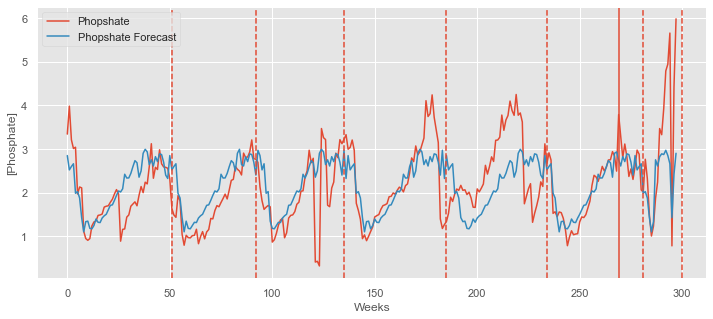

In [747]:
# set figure size
plt.figure( figsize = ( 12, 5))
  
# plot a simple time series plot
# using seaborn.lineplot()
sns.lineplot( x = 'level_0',
             y = 'Phosphate_x',
             data = nitriteonly,
             label = 'Phopshate')

sns.lineplot( x = 'level_0',
             y = 'Phosphate_y',
             data = nitriteonly,
             label = 'Phopshate Forecast')

plt.axvline(51, ls='--')
plt.axvline(92, ls='--')
plt.axvline(135, ls='--')
plt.axvline(185, ls='--')
plt.axvline(234, ls='--')
plt.axvline(269, ls='-')
plt.axvline(281, ls='--')
plt.axvline(300, ls='--')
  
plt.xlabel('Weeks')
plt.ylabel('[Phosphate]')

In [626]:
autoplot(tsclean(nitriteonly), series="clean", color='red', lwd=0.9)+
autolayer(nitriteonly, series="original", color='gray', lwd=1)+
geom_point(data = tsoutliers(nitriteonly) %>% as.data.frame(), aes(x='level_0', y='Nitrite_x'), col='blue')+labs(x = "Day", y = "Gold price ($US)")

SyntaxError: invalid syntax (<ipython-input-626-1009e8bf4a64>, line 1)

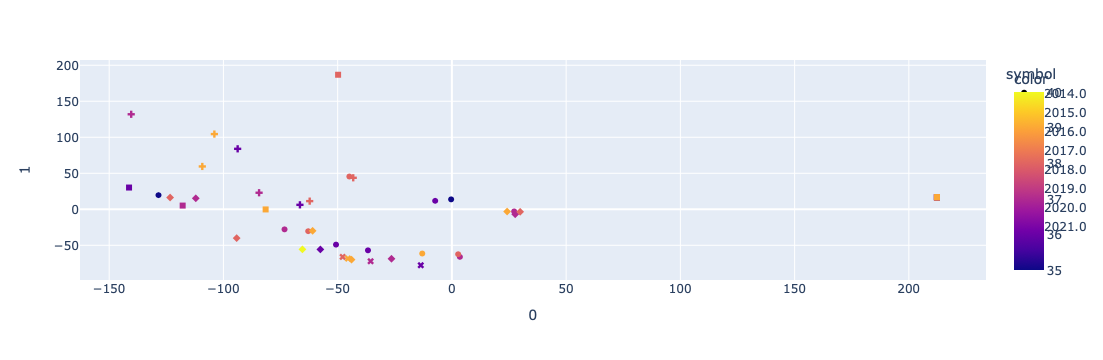

In [716]:
pca = PCA(n_components=2)
components = pca.fit_transform(distance_matrix)

fig = px.scatter(components, x=0, y=1, color=allyearshallow['weekn'], symbol=allyearshallow['year'])
fig.show()

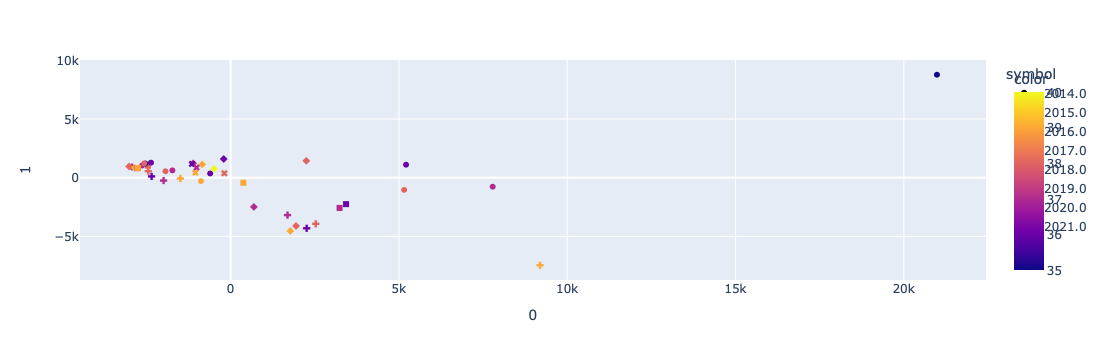

In [717]:
pca = PCA(n_components=2)
components = pca.fit_transform(allyears)

fig = px.scatter(components, x=0, y=1,color=allyearshallow['weekn'],symbol=allyearshallow['year'])
fig.show()

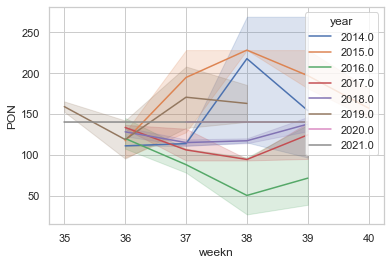

In [370]:
sns.lineplot(x = "weekn", y = "PON", data=allyearshallow, hue="year")
plt.show()

In [ ]:
grouped_data = sales_data.groupby('ProductID')
sales_data['AvgRevenuePerUnit'] = grouped_data['Revenue'].transform('mean') / grouped_data['Quantity'].transform('mean')

In [367]:
allyearshallow['year'] = pd.Categorical(allyearshallow['year'])

In [384]:
allyearshallow = allyearshallow.reset_index()

In [379]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(np.array(allyears))
plot_df = pd.DataFrame(data = principalComponents, columns = ['dim1', 'dim2'], index = allyears.index)

In [380]:
plot_df['dim1'] = plot_df['dim1']/1000
plot_df['dim2'] = plot_df['dim2']/1000

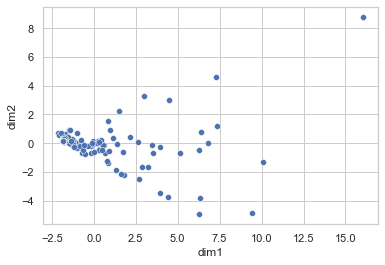

In [381]:
sns.scatterplot(x = 'dim1', y = 'dim2', data = plot_df)

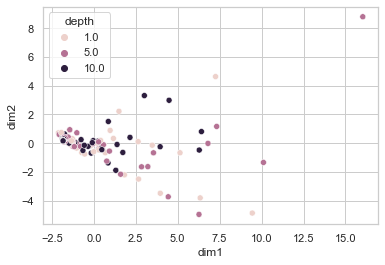

In [385]:
plot_df2 = pd.merge(plot_df,allyearshallow[['sampleid','depth']],on='sampleid', how='left')
sns.scatterplot(x = 'dim1', y = 'dim2', hue = 'depth', data = plot_df2)

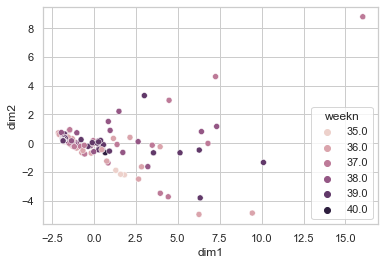

In [386]:
plot_df3 = pd.merge(plot_df,allyearshallow[['sampleid','weekn']],on='sampleid', how='left')
sns.scatterplot(x = 'dim1', y = 'dim2', hue = 'weekn', data = plot_df3)

In [387]:
from sklearn.manifold import TSNE
tsne = TSNE(metric = 'jaccard')
embeddings = tsne.fit_transform(allyears)
plot_df = pd.DataFrame(data = embeddings, columns = ['dim1', 'dim2'], index = allyears.index)

/Users/Diana/miniconda3/envs/qiime2-2020.111/lib/python3.6/site-packages/sklearn/metrics/pairwise.py:1761: DataConversionWarning:

Data was converted to boolean for metric jaccard



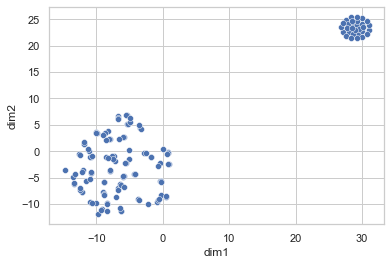

In [388]:
sns.scatterplot(x = 'dim1', y = 'dim2', data = plot_df)

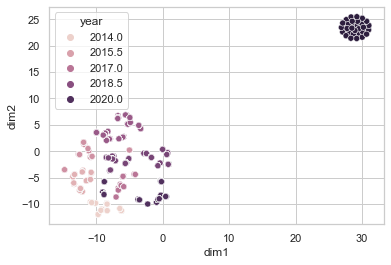

In [389]:
plot_df2 = pd.merge(plot_df,copy_of[['sampleid','year']],on='sampleid', how='left')
sns.scatterplot(x = 'dim1', y = 'dim2', hue = 'year', data = plot_df2)

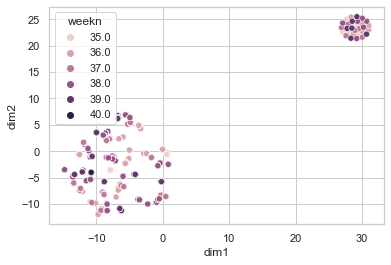

In [391]:
plot_df3 = pd.merge(plot_df,copy_of[['sampleid','weekn']],on='sampleid', how='left')
sns.scatterplot(x = 'dim1', y = 'dim2', hue = 'weekn', data = plot_df3)

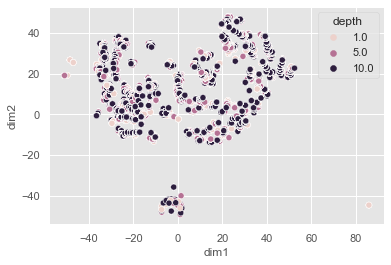

In [128]:
plot_df4 = pd.merge(plot_df,copy_of[['sampleid','depth']],on='sampleid', how='left')
sns.scatterplot(x = 'dim1', y = 'dim2', hue = 'depth', data = plot_df4)

In [132]:
conda install -c conda-forge umap-learn

Solving environment: failed with initial frozen solve. Retrying with flexible solve.
Solving environment: failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.1.0
  latest version: 23.7.4

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=23.7.4



## Package Plan ##

  environment location: /Users/Diana/miniconda3/envs/qiime2-2020.111

  added / updated specs:
    - umap-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2021.5.30          |   py36h79c6626_0         141 KB  conda-forge
    llvmlite-0.36.0            |   py36he4411ff_4         296 KB
    numba-0.53.1               |   py36hb2f4e1b_0         3.3 MB
    ope

In [137]:
import umap
reducer = umap.UMAP(n_components = 2, n_neighbors = 15, metric = 'jaccard', random_state = 0)
embeddings = reducer.fit_transform(allyears)
plot_df = pd.DataFrame(data = embeddings, columns = ['dim1', 'dim2'], index = allyears.index)

ContextualVersionConflict: (importlib-metadata 3.1.1 (/Users/Diana/miniconda3/envs/qiime2-2020.111/lib/python3.6/site-packages), Requirement.parse('importlib-metadata>=4.8.1; python_version < "3.8"'), {'pynndescent'})

In [294]:
copy_of

,sampleid,feature_id,feature_frequency,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elutin_volume,nifH,MetaG,new_id,notes,elution_volume,Unnamed: 15,16S V6V8\nIMR #,Notes,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,size_code,IMR # - V4V5,IMR # - 18S,Elution volume,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,[DNA]ng/ul,Freezer Box (1.5mL),Filtration Volume (DNA),sample_code,month_name,month,day,time_string_x,time_string_y,julian_day,scan,temperature,conductivity,oxygenVoltage,fluorescence,unknown,pH,PSAR,salinity,theta,sigmaTheta,oxygen,scan2,fluorescence2,turbidity,oxygenCurrent,oxygenTemperature,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,bbmpdepth,fluorometer,par,flagArchaic,time_string_time,season,mission_descriptor,event_id,sample_id,latitude,longitude,time,Chlorophyll A,Nitrate,Nitrite,Phosphate,Silicate,Ammonia,Salinity,Temperature,HPLC_ALLOX,HPLC_BUT19,HPLC_CHLA,HPLC_CHLB,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON,time_string,Taxon,Confidence,Domain,Phylum,Class,Order,Family,Genus,Species,feature_count
0,BB14.10A,6388564e4b25815b40d34be01eb2c574,102.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,2014-03-05,64.0,1970.0,0.3580,0.581948,2.5917,2.8321,-0.065100,NaN,237.59000,29.3043,NaN,23.4968,7.61853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,Spring,18VA14667,9.0,387992.0,44.6917,-63.6417,1230.0,3.82000,7.810,0.2,0.7600,7.89,1.9800,29.3000,0.3600,0.0,0.0,3.904,0.135,0.717,0.0,0.45,0.0,1.878,0.0,0.0,0.0,NaN,NaN,2014-03-05,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.999999,d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Flavobacteriales,f__NS9_marine_group,g__NS9_marine_group,None,202
1,BB14.10A,6388564e4b25815b40d34be01eb2c574,102.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,2014-03-05,64.0,1906.0,0.3693,0.582096,2.5922,2.8311,0.045077,NaN,184.84000,29.3014,NaN,23.4940,7.61141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,Spring,18VA14667,9.0,387992.0,44.6917,-63.6417,1230.0,3.82000,7.810,0.2,0.7600,7.89,1.9800,29.3000,0.3600,0.0,0.0,3.904,0.135,0.717,0.0,0.45,0.0,1.878,0.0,0.0,0.0,NaN,NaN,2014-03-05,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.999999,d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Flavobacteriales,f__NS9_marine_group,g__NS9_marine_group,None,202
2,BB14.10A,fd5eeee9dda082827512f461eae9139e,17.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,2014-03-05,64.0,1970.0,0.3580,0.581948,2.5917,2.8321,-0.065100,NaN,237.59000,29.3043,NaN,23.4968,7.61853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,Spring,18VA14667,9.0,387992.0,44.6917,-63.6417,1230.0,3.82000,7.810,0.2,0.7600,7.89,1.9800,29.3000,0.3600,0.0,0.0,3.904,0.135,0.717,0.0,0.45,0.0,1.878,0.0,0.0,0.0,NaN,NaN,2014-03-05,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,1.000000,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,None,None,202
3,BB14.10A,fd5eeee9dda082827512f461eae9139e,17.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,2014-03-05,64.0,1906.0,0.3693,0.582096,2.5922,2.8311,0.045077,NaN,184.84000,29.3014,NaN,23.4940,7.61141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,Spring,18VA14667,9.0,387992.0,44.6917,-63.6417,123

In [312]:
y2014

,sampleid,feature_id,feature_frequency,year,date,weekn,depth,depth_code,date_depth,[DNA]ng/uL,A260/280,extraction_date,extracted_by,Sequenced,IMR_n,elutin_volume,nifH,MetaG,new_id,notes,elution_volume,Unnamed: 15,16S V6V8\nIMR #,Notes,BR Working Code (Top of Tube),Label on side of Tube,H2O Vol Filtered,size_code,IMR # - V4V5,IMR # - 18S,Elution volume,Correct Week #,Sequencing Code\nBBYear.WeekDepthSize,Freezer Box,Aliquots,[DNA]ng/ul,Freezer Box (1.5mL),Filtration Volume (DNA),sample_code,month_name,month,day,time_string_x,time_string_y,julian_day,scan,temperature,conductivity,oxygenVoltage,fluorescence,unknown,pH,PSAR,salinity,theta,sigmaTheta,oxygen,scan2,fluorescence2,turbidity,oxygenCurrent,oxygenTemperature,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,bbmpdepth,fluorometer,par,flagArchaic,time_string_time,season,mission_descriptor,event_id,sample_id,latitude,longitude,time,Chlorophyll A,Nitrate,Nitrite,Phosphate,Silicate,Ammonia,Salinity,Temperature,HPLC_ALLOX,HPLC_BUT19,HPLC_CHLA,HPLC_CHLB,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON,time_string,Taxon,Confidence,Domain,Phylum,Class,Order,Family,Genus,Species
0,BB14.10A,6388564e4b25815b40d34be01eb2c574,102.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,2014-03-05,64.0,1970.0,0.3580,0.581948,2.5917,2.8321,-0.065100,NaN,237.59000,29.3043,NaN,23.4968,7.61853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,Spring,18VA14667,9.0,387992.0,44.6917,-63.6417,1230.0,3.82,7.81,0.20,0.76,7.89,1.98,29.30,0.36,0.000,0.0,3.904,0.135,0.717,0.0,0.45,0.0,1.878,0.0,0.0,0.0,NaN,NaN,2014-03-05,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.999999,d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Flavobacteriales,f__NS9_marine_group,g__NS9_marine_group,None
1,BB14.10A,6388564e4b25815b40d34be01eb2c574,102.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,2014-03-05,64.0,1906.0,0.3693,0.582096,2.5922,2.8311,0.045077,NaN,184.84000,29.3014,NaN,23.4940,7.61141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,Spring,18VA14667,9.0,387992.0,44.6917,-63.6417,1230.0,3.82,7.81,0.20,0.76,7.89,1.98,29.30,0.36,0.000,0.0,3.904,0.135,0.717,0.0,0.45,0.0,1.878,0.0,0.0,0.0,NaN,NaN,2014-03-05,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.999999,d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Flavobacteriales,f__NS9_marine_group,g__NS9_marine_group,None
2,BB14.10A,fd5eeee9dda082827512f461eae9139e,17.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,2014-03-05,64.0,1970.0,0.3580,0.581948,2.5917,2.8321,-0.065100,NaN,237.59000,29.3043,NaN,23.4968,7.61853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,Spring,18VA14667,9.0,387992.0,44.6917,-63.6417,1230.0,3.82,7.81,0.20,0.76,7.89,1.98,29.30,0.36,0.000,0.0,3.904,0.135,0.717,0.0,0.45,0.0,1.878,0.0,0.0,0.0,NaN,NaN,2014-03-05,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,1.000000,d__Bacteria,p__Proteobacteria,c__Alphaproteobacteria,o__Rhodobacterales,f__Rhodobacteraceae,None,None
3,BB14.10A,fd5eeee9dda082827512f461eae9139e,17.0,2014.0,05-Mar,10.0,1.0,A,03.05.1m,4.5,1.97,May 6 2014,NaN,yes,NaN,100.0,NaN,NaN,BB14.10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar,3.0,5.0,2014-03-05,2014-03-05,64.0,1906.0,0.3693,0.582096,2.5922,2.8311,0.045077,NaN,184.84000,29.3014,NaN,23.4940,7.61141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-05 13:29:16,Spring,18VA14667,9.0,387992.0,44.6917,-63.6417,1230.0,3.82,7.81,0.20,0.76,7.89,1.98,29.30,0.36,0.000,0.

In [375]:
onlyphyl = copy_of.filter(['year','Phylum','season'], axis=1)

In [376]:
onlyphyl=onlyphyl.drop_duplicates()

In [377]:
onlyphyl.pivot(index='Phylum', columns='season'

SyntaxError: unexpected EOF while parsing (<ipython-input-377-7f2b9cfc1949>, line 1)

In [378]:
forupset=onlyphyl.groupby(['season', 'Phylum']).count().unstack().fillna(0)

In [379]:
forupset.where(forupset <= 1, 1, inplace=True)

In [380]:
forupset.to_csv('upsetplots.csv', index_label='weekn')

In [381]:
forupset

year                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
Phylum p__Acidobacteriota p__Actinobacteriota p__Armatimonadota p__Bacteroidota p__Bdellovibrionota p__Calditrichota p__Campilobacterota p__Cercozoa p__Chloroflexi p__Chlorophyta p__Ciliophora p__Cloacimonadota p__Crenarchaeota p__Cryptomycota p__Cryptophyceae p__Cyanobacteria p__Dadabacteria p__Deinococcota p__Dependentiae p__Desulfobacterota p__Diatomea p__Fermentibacterota p__Fibrobacterota p__Firmicutes p__Fusobacteriota p__Gemmatimonadota p__Halobacterota p__Hydrogenedentes p__Incertae_Sedis p__Kathablepharidae p__LCP-89 p__Latescibacterota p__Margulisbacteria p__Marinimicrobia_(SAR406_clade) p__Modulibacteria p__Myxococcota p__NB1-j p__Nanoarchaeota p__Nitrospinota p__Nitrospirota p__PAUC34f p__Patescibacteria p__Planctomycetota p__Protalveolata p__Proteobacteria p__SAR324_clade(Marine_group_B) p__Spirochaetota p__Sva0485 p__Synergistota p__Thermoplasmatota p__Verrucomicrobiota p__WPS-2
season                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
Autumn                1.0                 1.0               1.0             1.0                 1.0              1.0                 1.0         0.0            1.0            1.0           1.0               1.0              1.0             0.0              1.0              1.0             1.0             0.0             1.0                 1.0         0.0                  1.0               1.0           1.0               1.0                1.0              0.0                1.0               0.0                 1.0       1.0                 1.0                 1.0                              1.0               1.0            1.0      1.0              1.0             1.0             1.0        1.0                1.0                1.0              0.0               1.0                             1.0              1.0        1.0             1.0                 1.0                  1.0      1.0
Spring                1.0                 1.0               1.0             1.0                 1.0              0.0                 1.0         0.0            1.0            1.0           1.0               1.0              1.0             0.0              1.0              1.0             1.0             1.0             1.0                 1.0         1.0                  1.0               1.0 

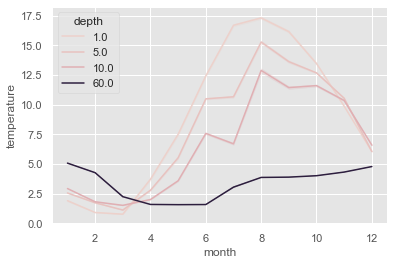

In [310]:
sns.lineplot(data=y2014, x="month", y="temperature", hue="depth")

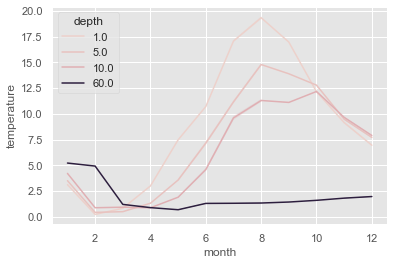

In [306]:
sns.lineplot(data=y2015, x="month", y="temperature", hue="depth")

In [311]:
salinity = shallow[['Weekn', 'temperature', "Year"]].copy()

In [313]:
salinity = salinity[salinity['temperature'].notna()]

In [314]:
salinity2014 = salinity[salinity.Year == 2019]
salinity2014 = salinity2014.drop(columns=['Year'])
salinity2014 = salinity2014.set_index(['Weekn'])

In [315]:
outliers_fraction = float(.01)
scaler = StandardScaler()
np_scaled = scaler.fit_transform(salinity2014.values.reshape(-1, 1))
data = pd.DataFrame(np_scaled)
# train isolation forest
model =  IsolationForest(contamination=outliers_fraction)
model.fit(data)

IsolationForest(contamination=0.01)

In [316]:
salinity2014

,temperature
Weekn,
2.0,2.151417
3.0,2.205233
4.0,1.592067
5.0,1.875233
6.0,1.943050
...,...
47.0,8.668567
48.0,7.817367
49.0,6.801833


In [317]:
salinity2014['anomaly'] = model.predict(data)

KeyError: "None of [Index(['salinity'], dtype='object')] are in the [columns]"

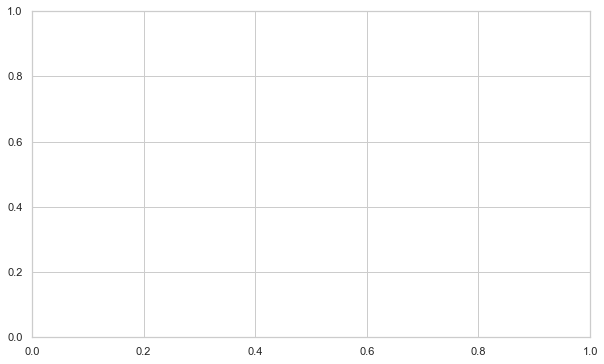

In [318]:
# visualization
fig, ax = plt.subplots(figsize=(10,6))
a = salinity2014.loc[salinity2014['anomaly'] == -1, ['salinity']] #anomaly
ax.plot(salinity2014.index, salinity2014['salinity'], color='black', label = 'Normal')
ax.scatter(a.index,a['salinity'], color='red', label = 'Anomaly')
plt.legend()
plt.show();

In [253]:
fig = px.line(deep, x="Weekn", y="salinity", color='Year')
fig.show()

In [254]:
fig = px.line(deep, x="Weekn", y="Nitrate", color='Year')
fig.show()

In [38]:
all_md

,sampleid,Year,Date,Weekn,Depth,Depth_Code,Sample date,[DNA] (ng/uL),260/280,Extraction Date,...,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON
0,BB14.3A,2014,15-Jan,3,1,A,01.15.1m,NaN,NaN,NaN,...,0.000,0.0,0.0,0.0,0.129,0.0,0.0,0.0,NaN,NaN
1,BB14.3B,2014,15-Jan,3,5,B,01.15.5m,NaN,NaN,NaN,...,0.023,0.0,0.0,0.0,0.145,0.0,0.0,0.0,206.1,27.2
2,BB14.3C,2014,15-Jan,3,10,C,01.15.10m,NaN,NaN,NaN,...,0.042,0.0,0.0,0.0,0.000,0.0,0.0,0.0,NaN,NaN
3,BB14.3D,2014,15-Jan,3,60,D,01.15.60m,NaN,NaN,NaN,...,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,514.8,75.3
4,BB14.4A,2014,23-Jan,4,1,A,01.23.1m,NaN,NaN,NaN,...,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2223,BB16.50D,2016,14-Dec,50,60,D,NaN,11.6,NaN,2017-01-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2224,BB16.51A,2016,21-Dec,51,1,A,NaN,14.3,NaN,2017-01-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2225,BB16.51B,2016,21-Dec,51,5,B,NaN,11.2,NaN,2017-01-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2226,BB16.51C,2016,21-Dec,51,10,C,NaN,28.8,NaN,2017-03-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
print(all_md['month'].to_string(index=False))

  01
  01
  01
  01
  01
  01
  01
  01
  01
  01
  01
  01
  02
  02
  02
  02
  02
  02
  02
  02
  02
  02
  02
  02
  02
  02
  02
  02
  03
  03
  03
  03
  03
  03
  03
  03
  03
  03
  03
  03
  03
  03
  03
  03
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  04
  05
  05
  05
  05
  05
  05
  05
  05
  05
  05
  05
  05
  05
  05
  05
  05
  06
  06
  06
  06
  06
  06
  06
  06
  06
  06
  06
  06
  06
  06
  06
  06
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  07
  08
  08
  08
  08
  08
  08
  08
  08
  08
  08
  08
  08
  08
  08
  08
  08
  09
  09
  09
  09
  09
  09
  09
  09
  09
  09
  09
  09
  09
  09
  09
  09
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  10
  11
  11
  11
  11
  11
  11
  11
  11
  11
  11
  11
  11
  11
  11
  11
  11
  12
  12
  12
  12
  12
  12
  12
  12
  12
  12
  12
  12
 NaN
 NaN
 NaN
 NaN


In [31]:
all_md

,sampleid,Year,Date,Weekn,Depth,Depth_Code,Sample date,[DNA] (ng/uL),260/280,Extraction Date,...,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON
0,BB14.3A,2014,15-Jan,3,1,A,01.15.1m,NaN,NaN,NaN,...,0.000,0.0,0.0,0.0,0.129,0.0,0.0,0.0,NaN,NaN
1,BB14.3B,2014,15-Jan,3,5,B,01.15.5m,NaN,NaN,NaN,...,0.023,0.0,0.0,0.0,0.145,0.0,0.0,0.0,206.1,27.2
2,BB14.3C,2014,15-Jan,3,10,C,01.15.10m,NaN,NaN,NaN,...,0.042,0.0,0.0,0.0,0.000,0.0,0.0,0.0,NaN,NaN
3,BB14.3D,2014,15-Jan,3,60,D,01.15.60m,NaN,NaN,NaN,...,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,514.8,75.3
4,BB14.4A,2014,23-Jan,4,1,A,01.23.1m,NaN,NaN,NaN,...,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2223,BB16.50D,2016,14-Dec,50,60,D,NaN,11.6,NaN,2017-01-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2224,BB16.51A,2016,21-Dec,51,1,A,NaN,14.3,NaN,2017-01-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2225,BB16.51B,2016,21-Dec,51,5,B,NaN,11.2,NaN,2017-01-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2226,BB16.51C,2016,21-Dec,51,10,C,NaN,28.8,NaN,2017-03-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
all_md.Year.unique()

array(['2014', '2015', '2017', '2019', '2021', '2020', '2018', '2016'],
      dtype=object)

In [ ]:
fig = px.line(depth1, x="Weekn", y="temperature", color='Year', )
fig.update_layout(legend=dict(
    orientation="h",
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))
fig.show()

In [103]:
for index, row in dfo_md.iterrows():
    dfo_md['week_n'] = datetime.date(dfo_md['year_time'], dfo_md['month_time'], dfo_md['day_time']).isocalendar()[1]

,time_string,year_time,month_time,day_time,julian_day,scan,pressure,temperature,conductivity,oxygenVoltage,...,oxygenSaturation,unknown2,altimeter,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,week_n
0,1999-05-05 12:48:21,1999,5,5,125,2623.0,1.0,7.7017,NaN,NaN,...,NaN,0.17271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
1,1999-05-05 12:48:21,1999,5,5,125,2629.0,1.5,7.3615,NaN,NaN,...,NaN,0.00506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
2,1999-05-05 12:48:21,1999,5,5,125,2635.0,2.0,7.2588,NaN,NaN,...,NaN,0.03027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
3,1999-05-05 12:48:21,1999,5,5,125,2640.0,2.5,6.5228,NaN,NaN,...,NaN,0.11686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
4,1999-05-05 12:48:21,1999,5,5,125,2644.0,3.0,5.3546,NaN,NaN,...,NaN,0.15878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170924,2023-05-24 11:57:12,2023,5,24,144,14241.0,69.0,3.2369,2.851717,1.8235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
170925,2023-05-24 11:57:12,2023,5,24,144,14266.0,69.5,3.2371,2.851766,1.8173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
170926,2023-05-24 11:57:12,2023,5,24,144,14291.0,70.0,3.2371,2.851796,1.8138,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
170927,2023-05-24 11:57:12,2023,5,24,144,14316.0,70.5,3.2373,2.851825,1.8109,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24


In [58]:
df

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


In [60]:
all_md.columns.values 

array(['sampleid', 'Year', 'Date', 'Weekn', 'Depth', 'Depth_Code',
       'Sample date', '[DNA] (ng/uL)', '260/280', 'Extraction Date',
       'Sequenced', 'Elution volume', 'nifH', 'MetaG', 'Extracted By',
       'A260/280', 'IMR #', 'Notes', 'BR Working Code (Top of Tube)',
       'Label on side of Tube', '16S V6V8\nIMR #', 'H2O Vol Filtered',
       'Correct Week #', 'Size_Code',
       'Sequencing Code\nBBYear.WeekDepthSize', 'Extracted by',
       'IMR # - V4V5', 'IMR # - 18S', 'Aliquots', 'Freezer Box',
       'Tube Label BBYear.WeekDepthSize', 'Filtration Volume (DNA) ',
       'Elution Volume', 'Freezer Box (1.5mL)', 'Month', 'month_time_x',
       'day_time_x', 'time_string', 'year_time', 'month_time_y',
       'day_time_y', 'julian_day', 'scan', 'temperature', 'conductivity',
       'oxygenVoltage', 'fluorescence', 'unknown', 'pH', 'PSAR',
       'salinity', 'theta', 'sigmaTheta', 'oxygen', 'scan2',
       'fluorescence2', 'turbidity', 'oxygenCurrent', 'oxygenTemperature',
  

In [80]:
df2 = all_md[['temperature', 'Chlorophyll A', 'Nitrate', 'Phosphate', 'Silicate', 'Salinity', 'Year']]

In [81]:
df2

,temperature,Chlorophyll A,Nitrate,Phosphate,Silicate,Salinity,Year
0,3.6047,0.61,9.00,0.82,15.92,27.02,2014
1,3.4460,0.49,8.13,0.91,11.56,28.87,2014
2,3.3400,0.55,7.82,0.97,10.17,29.52,2014
3,5.2532,0.06,16.65,3.34,34.31,31.23,2014
4,1.0389,0.64,8.39,1.00,11.72,27.97,2014
...,...,...,...,...,...,...,...
2223,5.4582,NaN,NaN,NaN,NaN,NaN,2016
2224,3.6150,NaN,NaN,NaN,NaN,NaN,2016
2225,5.0736,NaN,NaN,NaN,NaN,NaN,2016
2226,5.2547,NaN,NaN,NaN,NaN,NaN,2016


In [84]:
bio_niskin[bio_niskin.isna().any(axis=1)]

,mission_descriptor,event_id,sample_id,latitude,longitude,year,month,day,time,depth,...,HPLC_CHLC12,HPLC_CHLC3,HPLC_DIADINOX,HPLC_DIATOX,HPLC_FUCOX,HPLC_HEX19,HPLC_PERID,HPLC_ZEA,POC,PON
0,18VA92667,1,19920100101,44.6917,-63.6417,1992,1,8,1230,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18VA92667,1,19920100102,44.6917,-63.6417,1992,1,8,1230,5.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18VA92667,1,19920100103,44.6917,-63.6417,1992,1,8,1230,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18VA92667,2,19920100201,44.6917,-63.6417,1992,1,15,1230,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18VA92667,2,19920100202,44.6917,-63.6417,1992,1,15,1230,5.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5894,18VA22667,46,490134,44.6937,-63.6403,2022,12,7,1305,10.39,...,0.062,0.023,0.021,0.0,0.231,0.0,0.000,0.0,NaN,NaN
5896,18VA22667,47,490140,44.6937,-63.6403,2022,12,14,1259,1.99,...,0.066,0.000,0.027,0.0,0.157,0.0,0.047,0.0,NaN,NaN
5898,18VA22667,47,490138,44.6937,-63.6403,2022,12,14,1259,10.23,...,0.056,0.000,0.021,0.0,0.141,0.0,0.041,0.0,NaN,NaN
5900,18VA22667,48,490144,44.6937,-63.6403,2022,12,21,1300,1.63,...,0.073,0.000,0.024,0.0,0.147,0.0,0.048,0.0,NaN,NaN


In [64]:
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

df = df2
features = ['pH','Temperature', 'temperature', 'Chlorophyll A', 'Nitrate', 'Phosphate', 'Silicate', 'Salinity']
X = df[features]

pca = PCA(n_components=2)
components = pca.fit_transform(X)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

fig = px.scatter(components, x=0, y=1, color=df['Year'])

for i, feature in enumerate(features):
    fig.add_annotation(
        ax=0, ay=0,
        axref="x", ayref="y",
        x=loadings[i, 0],
        y=loadings[i, 1],
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top"
    )
    fig.add_annotation(
        x=loadings[i, 0],
        y=loadings[i, 1],
        ax=0, ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5,
    )
fig.show()

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [3]:
#restrict to only years of interest 2019
dfo_md_14 = dfo_md[dfo_md.year_time == 2014]
dfo_md_14.loc[:,'year'] = "BB14" #add this column to match with metadata for QIIME2

/Users/Diana/miniconda3/envs/qiime2-2020.111/lib/python3.6/site-packages/pandas/core/indexing.py:1596: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/Diana/miniconda3/envs/qiime2-2020.111/lib/python3.6/site-packages/pandas/core/indexing.py:1763: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [4]:
dfo_14 = dfo_md_14.copy()

In [5]:
#restrict to only pressures 1,5,10,60
dfo_pressure_1 = dfo_14[dfo_14.pressure == 1.0]
dfo_pressure_1.loc[:,'depth_code'] = "A"

dfo_pressure_5 = dfo_14[dfo_14.pressure == 5.0]
dfo_pressure_5.loc[:,'depth_code'] = "B"

dfo_pressure_10 = dfo_14[dfo_14.pressure == 10.0]
dfo_pressure_10.loc[:,'depth_code'] = "C"

dfo_pressure_60 = dfo_14[dfo_14.pressure == 60.0]
dfo_pressure_60.loc[:,'depth_code'] = "D"

/Users/Diana/miniconda3/envs/qiime2-2020.111/lib/python3.6/site-packages/pandas/core/indexing.py:1596: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/Diana/miniconda3/envs/qiime2-2020.111/lib/python3.6/site-packages/pandas/core/indexing.py:1763: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/Diana/miniconda3/envs/qiime2-2020.111/lib/python3.6/site-packages/pandas/core/indexing.py:1596: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

In [6]:
dfo_14 = pd.concat([dfo_pressure_1,dfo_pressure_5,dfo_pressure_10,dfo_pressure_60])

In [7]:
dfo_14 = dfo_14.sort_values(by="time_string")
dfo_14

,time_string,year_time,month_time,day_time,julian_day,scan,pressure,temperature,conductivity,oxygenVoltage,...,unknown2,altimeter,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code
111155,2014-01-08 13:37:15,2014,1,8,8,1578.0,1.0,1.7707,0.600621,2.3087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A
111163,2014-01-08 13:37:15,2014,1,8,8,1992.0,5.0,2.2427,0.613212,2.3184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,B
111273,2014-01-08 13:37:15,2014,1,8,8,3052.0,60.0,5.1876,0.708615,0.8887,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,D
111173,2014-01-08 13:37:15,2014,1,8,8,2097.0,10.0,2.5279,0.620612,2.2989,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,C
111397,2014-01-15 13:08:32,2014,1,15,15,5224.0,60.0,5.2532,0.708860,0.9694,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117987,2014-12-10 13:09:03,2014,12,10,344,1976.0,1.0,5.5452,0.662988,1.9814,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A
118127,2014-12-17 13:08:48,2014,12,17,351,2581.0,5.0,6.0816,0.676788,2.1796,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,B
118119,2014-12-17 13:08:48,2014,12,17,351,2879.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A
118137,2014-12-17 13:08:48,2014,12,17,351,2657.0,10.0,6.0927,0.694786,2.1654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,C


In [9]:
dfo_14.shape

(206, 34)

In [ ]:
dfo_19 = dfo_19.reset_index()

In [10]:
dfo_19.loc[dfo_19['month_time'] == 2]

,index,time_string,year_time,month_time,day_time,julian_day,scan,pressure,temperature,conductivity,...,unknown2,altimeter,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code
16,146368,2019-02-06 13:19:04,2019,2,6,37,2621.0,5.0,1.9352,0.620368,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B
17,146478,2019-02-06 13:19:04,2019,2,6,37,3515.0,60.0,4.9195,0.705999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D
18,146360,2019-02-06 13:19:04,2019,2,6,37,2525.0,1.0,1.9152,0.619204,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A
19,146378,2019-02-06 13:19:04,2019,2,6,37,2700.0,10.0,1.9629,0.625336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,C
20,146514,2019-02-14 13:20:48,2019,2,14,45,3052.0,10.0,1.3398,0.618472,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,C
21,146614,2019-02-14 13:20:48,2019,2,14,45,3853.0,60.0,2.8491,0.663177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D
22,146504,2019-02-14 13:20:48,2019,2,14,45,2965.0,5.0,1.3045,0.617243,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B
23,146496,2019-02-14 13:20:48,2019,2,14,45,2908.0,1.0,0.8288,0.599134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A
24,146642,2019-02-20 13:22:19,2019,2,20,51,2532.0,5.0,1.1553,0.615689,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B
25,146652,2019-02-20 13:22:19,2019,2,20,51,2616.0,10.0,1.4078,0.622687,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,C


In [26]:
dfo_14.columns

Index(['time_string', 'year_time', 'month_time', 'day_time', 'julian_day',
       'scan', 'pressure', 'temperature', 'conductivity', 'oxygenVoltage',
       'fluorescence', 'unknown', 'pH', 'PSAR', 'salinity', 'theta',
       'sigmaTheta', 'oxygen', 'scan2', 'fluorescence2', 'turbidity',
       'oxygenCurrent', 'oxygenTemperature', 'oxygenSaturation', 'unknown2',
       'altimeter', 'sigmaTheta2', 'VOLT', 'depth', 'fluorometer', 'par',
       'flagArchaic', 'year', 'depth_code'],
      dtype='object')

In [12]:
dfo_19.loc[26.5] = 'Nan', 'Nan', 2019, 2, 20, 51, 'Nan', 60.0, 'Nan', 'Nan', 'Nan', 'Nan', 'Nan', 'Nan', 'Nan', 'Nan', 'Nan', 'Nan','Nan', 'Nan', 'Nan', 'Nan', 'Nan','Nan', 'Nan', 'Nan', 'Nan', 'Nan','Nan', 'Nan', 'Nan', 'Nan', 'Nan','BB19', 'D' #insert a column for the missing sample

In [12]:
dfo_14 = dfo_14.sort_index().reset_index(drop=True)

In [13]:
#add week number
week = np.arange(2,52)
week = np.repeat(week, 4)

In [15]:
dfo_14['week'] = week

ValueError: Length of values (200) does not match length of index (206)

In [24]:
dfo_14

,time_string,year_time,month_time,day_time,julian_day,scan,pressure,temperature,conductivity,oxygenVoltage,...,unknown2,altimeter,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code
0,2014-01-08 13:37:15,2014,1,8,8,1578.0,1.0,1.7707,0.600621,2.3087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A
1,2014-01-08 13:37:15,2014,1,8,8,1992.0,5.0,2.2427,0.613212,2.3184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,B
2,2014-01-08 13:37:15,2014,1,8,8,2097.0,10.0,2.5279,0.620612,2.2989,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,C
3,2014-01-08 13:37:15,2014,1,8,8,3052.0,60.0,5.1876,0.708615,0.8887,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,D
4,2014-01-15 13:08:32,2014,1,15,15,4189.0,1.0,3.6047,0.593479,2.4356,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,2014-12-10 13:09:03,2014,12,10,344,3000.0,60.0,4.9001,0.702908,0.8680,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,D
202,2014-12-17 13:08:48,2014,12,17,351,2879.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A
203,2014-12-17 13:08:48,2014,12,17,351,2581.0,5.0,6.0816,0.676788,2.1796,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,B
204,2014-12-17 13:08:48,2014,12,17,351,2657.0,10.0,6.0927,0.694786,2.1654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,C


In [33]:
#how to join them:

#We'll make a new list to be our new column.
new_labels = []

#we can iterate through rows with this.
for _, row in dfo_14.iterrows():
    #we can get the column value of each row by indexing on the column name
    year = row['year']
    depth_code = row['depth_code']
    week = row['week']
    #we use string formatting here to make a new label
    new_label = "{0}-{1}{2}".format(year, week, depth_code)
    #add the new label to the list
    new_labels.append(new_label)
#this will make a new column in the df called 'NewLabel' with the values
dfo_14['name'] = new_labels
dfo_14

,time_string,week,year_time,month_time,day_time,julian_day,scan,pressure,temperature,conductivity,...,altimeter,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code,name
0,2014-01-08 13:37:15,1,2014,1,8,8,1578.0,1.0,1.7707,0.600621,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A,BB14-1A
1,2014-01-08 13:37:15,1,2014,1,8,8,1992.0,5.0,2.2427,0.613212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,B,BB14-1B
2,2014-01-08 13:37:15,1,2014,1,8,8,2097.0,10.0,2.5279,0.620612,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,C,BB14-1C
3,2014-01-08 13:37:15,1,2014,1,8,8,3052.0,60.0,5.1876,0.708615,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,D,BB14-1D
4,2014-01-15 13:08:32,2,2014,1,15,15,4189.0,1.0,3.6047,0.593479,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A,BB14-2A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,2014-12-10 13:09:03,51,2014,12,10,344,3000.0,60.0,4.9001,0.702908,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,D,BB14-51D
202,2014-12-17 13:08:48,52,2014,12,17,351,2879.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A,BB14-52A
203,2014-12-17 13:08:48,52,2014,12,17,351,2581.0,5.0,6.0816,0.676788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,B,BB14-52B
204,2014-12-17 13:08:48,52,2014,12,17,351,2657.0,10.0,6.0927,0.694786,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,C,BB14-52C


In [37]:
#how to join them:

#We'll make a new list to be our new column.
new_labels = []

#we can iterate through rows with this.
for _, row in bb_md.iterrows():
    #we can get the column value of each row by indexing on the column name
    depth_code = row['Depth_Code']
    week = row['Week#']
    #we use string formatting here to make a new label
    new_label = "BB19-{1}{2}".format(year, week, depth_code)
    #add the new label to the list
    new_labels.append(new_label)
#this will make a new column in the df called 'NewLabel' with the values
bb_md['name'] = new_labels
bb_md

,sampleid,Year,Date,Week#,Depth,Depth_Code,Sample,Concentration (ng/uL),260/280,260/230,Date Extracted,Sequenced,Elution volume,NewID,nifH,MetaG,Month,name
0,BB14-3A,2014,15-Jan,3,1,A,01.15.1m,NaN,NaN,NaN,NaN,yes,NaN,BB14-3A,NaN,NaN,Jan,BB19-3A
1,BB14-3B,2014,15-Jan,3,5,B,01.15.5m,NaN,NaN,NaN,NaN,yes,NaN,BB14-3B,NaN,NaN,Jan,BB19-3B
2,BB14-3C,2014,15-Jan,3,10,C,01.15.10m,NaN,NaN,NaN,NaN,yes,NaN,BB14-3C,NaN,NaN,Jan,BB19-3C
3,BB14-3D,2014,15-Jan,3,60,D,01.15.60m,NaN,NaN,NaN,NaN,yes,NaN,BB14-3D,NaN,NaN,Jan,BB19-3D
4,BB14-4A,2014,23-Jan,4,1,A,01.23.1m,NaN,NaN,NaN,NaN,yes,NaN,BB14-4A,NaN,NaN,Jan,BB19-4A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,BB14-50D,2014,10-Dec,50,60,D,12.10.60m,NaN,NaN,NaN,NaN,yes,NaN,BB14-50D,NaN,NaN,Dec,BB19-50D
192,BB14-51A,2014,17-Dec,51,1,A,12.17.1m,NaN,NaN,NaN,NaN,yes,NaN,BB14-51A,NaN,NaN,Dec,BB19-51A
193,BB14-51B,2014,17-Dec,51,5,B,12.17.5m,NaN,NaN,NaN,NaN,yes,NaN,BB14-51B,NaN,NaN,Dec,BB19-51B
194,BB14-51C,2014,17-Dec,51,10,C,12.17.10m,NaN,NaN,NaN,NaN,yes,NaN,BB14-51C,NaN,NaN,Dec,BB19-51C


In [31]:
dfo_14 = dfo_metadata_y14.copy()

In [28]:
dfo_14.to_csv('dfo_metadata_y14.csv', index=False)

In [38]:
#merge 2 metadata files
metadata_bb = pd.merge(bb_md, dfo_14, on = 'name',how='outer')
metadata_bb

,sampleid,Year,Date,Week#,Depth,Depth_Code,Sample,Concentration (ng/uL),260/280,260/230,...,unknown2,altimeter,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code
0,BB14-3A,2014.0,15-Jan,3.0,1.0,A,01.15.1m,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BB14-3B,2014.0,15-Jan,3.0,5.0,B,01.15.5m,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BB14-3C,2014.0,15-Jan,3.0,10.0,C,01.15.10m,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BB14-3D,2014.0,15-Jan,3.0,60.0,D,01.15.60m,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BB14-4A,2014.0,23-Jan,4.0,1.0,A,01.23.1m,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,D
398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,A
399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,B
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB14,C


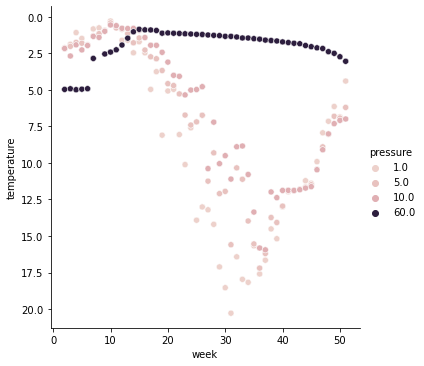

In [19]:
sns.relplot(data=metadata_bb, x="week", y="temperature", hue='pressure')

In [39]:
metadata_bb2 = metadata_bb.fillna(0)

In [40]:
metadata_bb2["week"] = pd.to_numeric(metadata_bb2["week"])

In [42]:
metadata_bb2["temperature"] = pd.to_numeric(metadata_bb2["temperature"])

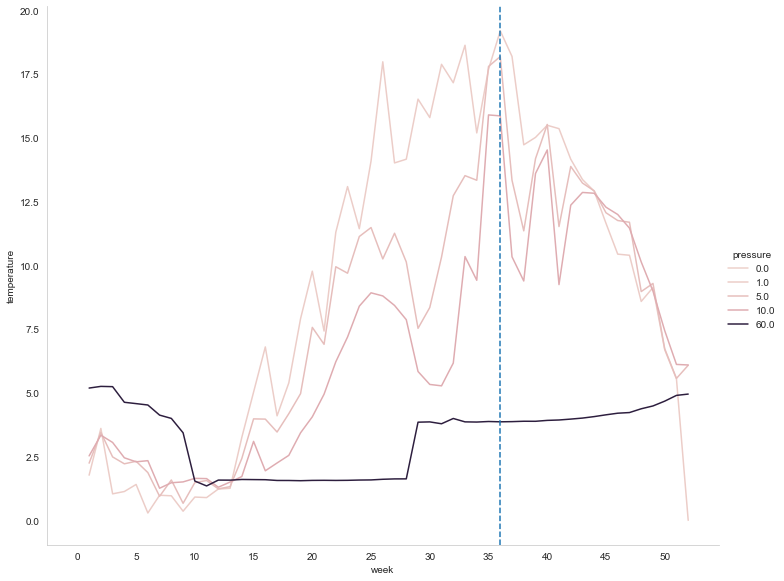

In [43]:
sns.set_style("whitegrid", {'axes.grid' : False})
g = sns.relplot(
    data=metadata_bb2, kind="line",
    x="week", y="temperature", hue="pressure", height = 8, aspect = 1.25
)
g.set(xticks=np.arange(0,52,5))
plt.axvline(36, ls='--')

In [22]:
metadata_bb

,sampleid,Year,Date,Week #,Correct Week #,Depth(m),Depth code,Size Code\n0.2um - S\n3um - L,Tube Label\nBBYear.WeekDepthSize,Extraction Date,...,altimeter,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code,week
0,BB19-2AL,2019.0,09-Jan,2.0,2.0,1.0,A,L,BB19-2AL,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,2.0
1,BB19-2AS,2019.0,09-Jan,2.0,2.0,1.0,A,S,BB19-2AS,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,2.0
2,BB19-2BL,2019.0,09-Jan,2.0,2.0,5.0,B,L,BB19-2BL,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,2.0
3,BB19-2BS,2019.0,09-Jan,2.0,2.0,5.0,B,S,BB19-2BS,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,2.0
4,BB19-2CL,2019.0,09-Jan,2.0,2.0,10.0,C,L,BB19-2CL,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,C,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,BB19-51DS,2019.0,18-Dec,51.0,51.0,60.0,D,S,BB19-DEC18 DS,Dec 14 2021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,51.0
402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,43.0
403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,43.0
404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,43.0


In [23]:
biomtable19 = pd.read_csv("/Users/Diana/Documents/escuela/phd/bb_data/2019/dada2_output_270210_exported/table_from_biom.txt", sep='\t')
classification = pd.read_csv("/Users/Diana/Documents/escuela/phd/bb_data/2019/taxa_270210/taxonomy.tsv", sep='\t')

In [63]:
biomtable14 = pd.read_csv("/Users/Diana/Documents/escuela/phd/bb_data/2014/dada2_output_exported/feature-table.tsv", sep='\t')
classification14 = pd.read_csv("/Users/Diana/Documents/escuela/phd/bb_data/2014/taxa/taxonomy.tsv", sep='\t')

In [64]:
biomtable14.rename({'#OTU ID': 'Feature ID'}, axis=1, inplace=True)

In [65]:
biomtable14

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,# Constructed from biom file
#OTU ID,BB14-10A,BB14-10B,BB14-10C,BB14-10D,BB14-11A,BB14-11B,BB14-11C,BB14-11D,BB14-12A,BB14-12B,BB14-12C,BB14-12D,BB14-13A,BB14-13B,BB14-13C,BB14-13D,BB14-14A,BB14-14B,BB14-14C,BB14-14D,BB14-15A,BB14-15B,BB14-15C,BB14-15D,BB14-16A,BB14-16B,BB14-16C,BB14-16D,BB14-17A,BB14-17B,BB14-17C,BB14-17D,BB14-18A,BB14-18B,BB14-18C,BB14-18D,BB14-19A,BB14-19B,BB14-19C,BB14-19D,BB14-20A,BB14-20B,BB14-20C,BB14-20D,BB14-21A,BB14-21B,BB14-21C,BB14-21D,BB14-22A,BB14-22B,BB14-22C,BB14-22D,BB14-23A,BB14-23B,BB14-23C,BB14-23D,BB14-24A,BB14-24B,BB14-24C,BB14-24D,BB14-25A,BB14-25B,BB14-25C,BB14-25D,BB14-26A,BB14-26B,BB14-26C,BB14-26D,BB14-27A,BB14-27B,BB14-27C,BB14-27D,BB14-28A,BB14-28B,BB14-28C,BB14-28D,BB14-29A,BB14-29B,BB14-29C,BB14-29D,BB14-30A,BB14-30B,BB14-30C,BB14-30D,BB14-31A,BB14-31B,BB14-31C,BB14-31D,BB14-32A,BB14-32B,BB14-32C,BB14-32D,BB14-33A,BB14-33B,BB14-33C,BB14-33D,BB14-34A,BB14-34B,BB14-34C,BB14-34D,BB14-35A,BB14-35B,BB14-35C,BB14-35D,BB14-36A,BB14-36B,BB14-36C,BB14-36D,BB14-37A,BB14-37B,BB14-37C,BB14-37D,BB14-38A,BB14-38B,BB14-38C,BB14-38D,BB14-39A,BB14-39B,BB14-39C,BB14-39D,BB14-3A,BB14-3B,BB14-3C,BB14-3D,BB14-40A,BB14-40B,BB14-40C,BB14-40D,BB14-41A,BB14-41B,BB14-41C,BB14-41D,BB14-42A,BB14-42B,BB14-42C,BB14-42D,BB14-43A,BB14-43B,BB14-43C,BB14-43D,BB14-44A,BB14-44B,BB14-44C,BB14-44D,BB14-45A,BB14-45B,BB14-45C,BB14-45D,BB14-46A,BB14-46B,BB14-46C,BB14-46D,BB14-47C,BB14-47D,BB14-48A,BB14-48B,BB14-48C,BB14-48D,BB14-49A,BB14-49B,BB14-49C,BB14-49D,BB14-4A,BB14-4B,BB14-4C,BB14-4D,BB14-50A,BB14-50B,BB14-50C,BB14-50D,BB14-51A,BB14-51B,BB14-51C,BB14-51D,BB14-5A,BB14-5B,BB14-5C,BB14-5D,BB14-6A,BB14-6B,BB14-6C,BB14-6D,BB14-7A,BB14-7B,BB14-7C,BB14-7D,BB14-8A,BB14-8B,BB14-8C,BB14-8D,BB14-9A,BB14-9B,BB14-9C,BB14-9D
79f3f51b584fe5e37cebc3b9f117c5ae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7012a87569ffdbc4422e4b6fe72ec59d,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cbcffc3da0cc6ea7a5d6a9fee1713b2f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0

In [62]:
meltedbiom = pd.melt(frame=biomtable14, id_vars = 'Feature ID', var_name = 'sampleid', value_name = 'Rel Abun')

AttributeError: 'NoneType' object has no attribute 'columns'

In [27]:
mergedmelty = pd.merge(meltedbiom, classification, on = 'Feature ID',how='inner')

In [28]:
merged = mergedmelty.set_index('Taxon')

In [29]:
merged = merged.drop(columns=['Confidence', 'Feature ID'])

In [30]:
merged

,sampleid,Rel Abun
Taxon,,
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18AL,0.0
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18AS,0.0
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18BL,0.0
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18BS,0.0
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18CL,0.0
...,...,...
d__Bacteria; p__Desulfobacterota; c__Desulfuromonadia; o__Bradymonadales; f__Bradymonadales; g__Bradymonadales; s__uncultured_marine,BB19-a43BS,0.0
d__Bacteria; p__Desulfobacterota; c__Desulfuromonadia; o__Bradymonadales; f__Bradymonadales; g__Bradymonadales; s__uncultured_marine,BB19-a43CL,0.0
d__Bacteria; p__Desulfobacterota; c__Desulfuromonadia; o__Bradymonadales; f__Bradymonadales; g__Bradymonadales; s__uncultured_marine,BB19-a43CS,0.0


In [31]:
merged.loc[:,'Total'] = merged.sum(axis=1)
merged

,sampleid,Rel Abun,Total
Taxon,,,
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18AL,0.0,0.0
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18AS,0.0,0.0
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18BL,0.0,0.0
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18BS,0.0,0.0
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Legionellales; f__Legionellaceae; g__Legionella; s__uncultured_Legionellaceae,BB19-18CL,0.0,0.0
...,...,...,...
d__Bacteria; p__Desulfobacterota; c__Desulfuromonadia; o__Bradymonadales; f__Bradymonadales; g__Bradymonadales; s__uncultured_marine,BB19-a43BS,0.0,0.0
d__Bacteria; p__Desulfobacterota; c__Desulfuromonadia; o__Bradymonadales; f__Bradymonadales; g__Bradymonadales; s__uncultured_marine,BB19-a43CL,0.0,0.0
d__Bacteria; p__Desulfobacterota; c__Desulfuromonadia; o__Bradymonadales; f__Bradymonadales; g__Bradymonadales; s__uncultured_marine,BB19-a43CS,0.0,0.0


In [32]:
groupedbytaxon = merged.groupby(['Taxon']).sum()

In [33]:
groupformelty = groupedbytaxon.reset_index()

In [34]:
totals = groupformelty[['Taxon', 'Total']]

In [35]:
top20 = groupedbytaxon.nlargest(20,'Total')

In [36]:
top5 = groupedbytaxon.nlargest(5, 'Total')

In [37]:
rare5 =  groupedbytaxon.nsmallest(5, 'Total')

In [38]:
rare5.index

Index(['d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Chitinophagales; f__uncultured; g__uncultured; s__uncultured_delta',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Cytophagales; f__Cyclobacteriaceae; g__Fulvivirga; s__uncultured_Flexibacter',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Cytophagales; f__Spirosomaceae; g__Arcicella',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Crocinitomicaceae; g__uncultured; s__uncultured_Bacteroidetes',
       'd__Bacteria; p__Desulfobacterota; c__Desulfuromonadia; o__Desulfuromonadia; f__Geopsychrobacteraceae; g__Desulfuromusa; s__uncultured_bacterium'],
      dtype='object', name='Taxon')

In [39]:
top20 = top20.drop(columns=['Total'])

In [40]:
top20T = top20.T
top20T['sampleid'] = top20T.index

In [41]:
top20T.columns

Index(['d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Chitinophagales; f__Saprospiraceae; g__Lewinella; s__uncultured_marine',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae; g__Planktomarina',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Oceanospirillales; f__Nitrincolaceae; g__uncultured; s__uncultured_marine',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__SAR11_clade; f__Clade_I; g__Clade_Ia',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Thiomicrospirales; f__Thioglobaceae',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae; g__Amylibacter',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Crocinitomicaceae; g__Fluviicola',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidi

In [42]:
df_long.pivot_table(index=["sampleid"], 
                    columns='class', 
                    values='grade')

NameError: name 'df_long' is not defined

In [43]:
df_long.pivot_table(index=["student", "school"], 
                    columns='class', 
                    values='grade')

NameError: name 'df_long' is not defined

In [44]:
withmeta = pd.merge(top20T, metadata_bb, on = 'sampleid',how='inner')

In [45]:
withmetamelty = pd.merge(mergedmelty, metadata_bb, on='sampleid', how='inner')

In [46]:
withmetamelty = pd.merge (withmetamelty, totals, on = 'Taxon', how='inner')

In [47]:
withmetamelty

,Feature ID,sampleid,Rel Abun,Taxon,Confidence,Year,Date,Week #,Correct Week #,Depth(m),...,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code,week,Total
0,88504ccccf908bd07cad252b49564924,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.939373,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,159.0
1,88504ccccf908bd07cad252b49564924,BB19-18AS,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.939373,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,159.0
2,88504ccccf908bd07cad252b49564924,BB19-18BL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.939373,2019.0,01-May,18.0,18.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,18.0,159.0
3,88504ccccf908bd07cad252b49564924,BB19-18BS,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.939373,2019.0,01-May,18.0,18.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,18.0,159.0
4,88504ccccf908bd07cad252b49564924,BB19-18CL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.939373,2019.0,01-May,18.0,18.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,C,18.0,159.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701605,250a576e3788b3f444938c7b08afb2e3,BB19-a43BS,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.723322,2019.0,23-Oct,42.0,43.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,42.0,194.0
701606,250a576e3788b3f444938c7b08afb2e3,BB19-a43CL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.723322,2019.0,23-Oct,42.0,43.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,C,42.0,194.0
701607,250a576e3788b3f444938c7b08afb2e3,BB19-a43CS,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.723322,2019.0,23-Oct,42.0,43.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,C,42.0,194.0
701608,250a576e3788b3f444938c7b08afb2e3,BB19-a43DL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.723322,2019.0,23-Oct,42.0,43.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,42.0,194.0


In [48]:
top20 = ['d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Chitinophagales; f__Saprospiraceae; g__Lewinella; s__uncultured_marine',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae; g__Planktomarina',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Oceanospirillales; f__Nitrincolaceae; g__uncultured; s__uncultured_marine',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__SAR11_clade; f__Clade_I; g__Clade_Ia',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Thiomicrospirales; f__Thioglobaceae',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae; g__Amylibacter',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Crocinitomicaceae; g__Fluviicola',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__uncultured; s__uncultured_marine',
       'd__Bacteria; p__Planctomycetota; c__OM190; o__OM190; f__OM190; g__OM190; s__marine_metagenome',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Thiomicrospirales; f__Thioglobaceae; g__SUP05_cluster',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Cryomorphaceae; g__uncultured',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__Tenacibaculum',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__Ulvibacter; s__uncultured_marine',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__NS5_marine_group',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__Polaribacter',
       'd__Bacteria; p__Nitrospinota; c__Nitrospinia; o__Nitrospinales; f__Nitrospinaceae; g__LS-NOB',
       'd__Bacteria; p__Planctomycetota; c__Planctomycetes; o__Planctomycetales; f__Rubinisphaeraceae; g__Fuerstia; s__uncultured_bacterium',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__NS3a_marine_group']


In [49]:
top5 = ['d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Chitinophagales; f__Saprospiraceae; g__Lewinella; s__uncultured_marine',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae; g__Planktomarina',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Oceanospirillales; f__Nitrincolaceae; g__uncultured; s__uncultured_marine',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__SAR11_clade; f__Clade_I; g__Clade_Ia',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Thiomicrospirales; f__Thioglobaceae']

In [50]:
mdtop20 = withmetamelty[withmetamelty['Taxon'].isin(top20)]

In [51]:
mdtop5 = withmetamelty[withmetamelty['Taxon'].isin(top5)]

In [44]:
sns.set_style("whitegrid", {'axes.grid' : False})
g = sns.relplot(
    data=mdtop5, kind="line",
    x="week", y="Rel Abun", hue="Taxon", height = 8, aspect = 1.25
)
g.set(xticks=np.arange(0,52,5))
plt.axvline(36, ls='--')

NameError: name 'mdtop5' is not defined

In [53]:
mdtop5

,Feature ID,sampleid,Rel Abun,Taxon,Confidence,Year,Date,Week #,Correct Week #,Depth(m),...,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code,week,Total
169260,8de78294559168d41a2f0ec6196bff4f,BB19-18AL,73.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.704028,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
169261,2462a5acc546029c7e21fd170d2a482e,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.771751,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
169262,51d6f4fcbee32cc1382a4e8a147f384e,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.729820,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
169263,f752e67ebf6c52d40f99164cef71911e,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.787688,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
169264,6339c9fdaf957a8ba7073ab06e76f910,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.757582,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493306,fa31e148a4fa1a4dfce3b59a2d542b85,BB19-a43DL,8.0,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.735284,2019.0,23-Oct,42.0,43.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,42.0,400813.0
493307,71a33c961f2ca92f6ce97184fcb81f01,BB19-a43DL,914.0,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.999488,2019.0,23-Oct,42.0,43.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,42.0,400813.0
493308,a897667502a072da9c30e63c34547778,BB19-a43DS,0.0,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.980163,2019.0,23-Oct,42.0,43.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,42.0,400813.0
493309,fa31e148a4fa1a4dfce3b59a2d542b85,BB19-a43DS,0.0,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.735284,2019.0,23-Oct,42.0,43.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,42.0,400813.0


In [54]:
metadata_bb

,sampleid,Year,Date,Week #,Correct Week #,Depth(m),Depth code,Size Code\n0.2um - S\n3um - L,Tube Label\nBBYear.WeekDepthSize,Extraction Date,...,altimeter,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code,week
0,BB19-2AL,2019.0,09-Jan,2.0,2.0,1.0,A,L,BB19-2AL,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,2.0
1,BB19-2AS,2019.0,09-Jan,2.0,2.0,1.0,A,S,BB19-2AS,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,2.0
2,BB19-2BL,2019.0,09-Jan,2.0,2.0,5.0,B,L,BB19-2BL,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,2.0
3,BB19-2BS,2019.0,09-Jan,2.0,2.0,5.0,B,S,BB19-2BS,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,2.0
4,BB19-2CL,2019.0,09-Jan,2.0,2.0,10.0,C,L,BB19-2CL,JAN 18 2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,C,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,BB19-51DS,2019.0,18-Dec,51.0,51.0,60.0,D,S,BB19-DEC18 DS,Dec 14 2021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,51.0
402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,43.0
403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,D,43.0
404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB19,B,43.0


In [187]:
mdtop5.pressure.unique()

array([ 1.,  5., 10., 60., nan])

In [186]:
mdtop5['pressure'] = mdtop5['pressure'].replace('nan', 0.0)

/Users/Diana/miniconda3/envs/qiime2-2020.111/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [194]:
mdtop5_dA = mdtop5[mdtop5.depth_code == 'A']

In [195]:
fig = px.line(mdtop5_dA, x="week", y="Rel Abun", color='Taxon')
fig.update_layout(legend=dict(
    orientation="h",
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))
fig.show()

In [203]:
fig = px.scatter(mdtop5_dA, x="week", y="temperature", color='Season')
fig.update_layout(legend=dict(
    orientation="h",
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))
fig.show()

In [204]:
fig = px.scatter(mdtop5_dA, x="week", y="oxygen", color='Season')
fig.update_layout(legend=dict(
    orientation="h",
    yanchor="bottom",
    y=1.02,
    xanchor="right",
    x=1
))
fig.show()

In [198]:
mdtop5_dA

,Feature ID,sampleid,Rel Abun,Taxon,Confidence,Year,Date,Week #,Correct Week #,Depth(m),...,sigmaTheta2,VOLT,depth,fluorometer,par,flagArchaic,year,depth_code,week,Total
169260,8de78294559168d41a2f0ec6196bff4f,BB19-18AL,73.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.704028,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
169261,2462a5acc546029c7e21fd170d2a482e,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.771751,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
169262,51d6f4fcbee32cc1382a4e8a147f384e,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.729820,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
169263,f752e67ebf6c52d40f99164cef71911e,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.787688,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
169264,6339c9fdaf957a8ba7073ab06e76f910,BB19-18AL,0.0,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,0.757582,2019.0,01-May,18.0,18.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,18.0,312112.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493288,fa31e148a4fa1a4dfce3b59a2d542b85,BB19-a43AL,0.0,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.735284,2019.0,23-Oct,42.0,43.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,42.0,400813.0
493289,71a33c961f2ca92f6ce97184fcb81f01,BB19-a43AL,4507.0,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.999488,2019.0,23-Oct,42.0,43.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,42.0,400813.0
493290,a897667502a072da9c30e63c34547778,BB19-a43AS,0.0,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.980163,2019.0,23-Oct,42.0,43.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,42.0,400813.0
493291,fa31e148a4fa1a4dfce3b59a2d542b85,BB19-a43AS,0.0,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,0.735284,2019.0,23-Oct,42.0,43.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,BB19,A,42.0,400813.0


In [201]:
withmetamelty.to_csv('w_md_melted.csv', index=False)

In [68]:
withmeta.columns

Index(['d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Chitinophagales; f__Saprospiraceae; g__Lewinella; s__uncultured_marine',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae; g__Planktomarina',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Oceanospirillales; f__Nitrincolaceae; g__uncultured; s__uncultured_marine',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__SAR11_clade; f__Clade_I; g__Clade_Ia',
       'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Thiomicrospirales; f__Thioglobaceae',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae; g__Amylibacter',
       'd__Bacteria; p__Proteobacteria; c__Alphaproteobacteria; o__Rhodobacterales; f__Rhodobacteraceae',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Crocinitomicaceae; g__Fluviicola',
       'd__Bacteria; p__Bacteroidota; c__Bacteroidi